In [15]:
gold_source = "/home/baptvit/Documents/github/graphrag-on-fhir/evaluations/data/silver/peformance"

In [16]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

all_dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df["consumer_id"] = file.split("/")[-1]
    all_dfs.append(df)


df_silver = pd.concat(all_dfs, ignore_index=True)

In [17]:
df_silver.head()

,Unnamed: 0,experiment_id,timestamp_output_step,full_response,system_promt,input,output,timestamp_search_step,latency_s,query,...,records,caracteres_count,caracteres_count_after_reduce,pass_map_reduce,resource_type,main_keys,user_query,llm_token_limit,strategy_name,consumer_id
0,0,Q5:llama-3-70b-instruct-awq:similarity_search_...,2025-02-10 17:56:28,{'input': 'Can you summarize my care plan hist...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my care plan history ?,"\n\nBased on the retrieved information, I can ...",2025-02-10 17:56:18,0.049025,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: CarePla...,3795,3795.0,False,NaN,care plan treatment plan,NaN,128000,SimilaritySearch0HopStrategy,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...
1,0,Q4:llama-3-70b-instruct-awq:similarity_search_...,2025-02-10 17:56:10,{'input': 'What are my recent laboratory value...,\nAs an expert in interpreting Electronic Heal...,"What are my recent laboratory values, what do ...","\n\nBased on your laboratory results, I'll pro...",2025-02-10 17:55:54,0.048336,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: Observa...,5161,5161.0,False,NaN,lab results blood tests laboratory values,NaN,128000,SimilaritySearch0HopStrategy,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...
2,0,Q8:llama-3-70b-instruct-awq:similarity_search_...,2025-02-10 17:57:35,{'input': 'Can you summarize my immunization h...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my immunization history ?,"\n\nBased on your immunization records, I'll p...",2025-02-10 17:57:20,0.063374,Similarity Search 0-Hop,...,{'Main health record': 'Immunization Status: c...,10639,10639.0,False,NaN,immunizations vaccinations shots,NaN,128000,SimilaritySearch0HopStrategy,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...
3,0,Q6:llama-3-70b-instruct-awq:similarity_search_...,2025-02-10 17:56:56,{'input': 'Can you provide a breakdown of my m...,\nAs an expert in interpreting Electronic Heal...,Can you provide a breakdown of my medical bills ?,\n\nBased on the medical billing records retri...,2025-02-10 17:56:36,0.065949,Similarity Search 0-Hop,...,{'Main health record': 'Explanation Of Benefit...,64948,64948.0,False,NaN,billing charges payment insurance claims,NaN,128000,SimilaritySearch0HopStrategy,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...
4,0,Q1:llama-3-70b-instruct-awq:similarity_search_...,2025-02-10 18:02:04,"{'input': ""What's my current medications and h...",\nAs an expert in interpreting Electronic Heal...,What's my current medications and how should I...,"\n\nBased on your medical records, I can provi...",2025-02-10 18:01:53,0.041610,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: Medicat...,5195,5195.0,False,NaN,medications,NaN,128000,SimilaritySearch0HopStrategy,Beatris270_Bogan287_5b3645de-a2d0-d016-0839-ba...


In [18]:
df_silver.columns

Index(['Unnamed: 0', 'experiment_id', 'timestamp_output_step', 'full_response',
       'system_promt', 'input', 'output', 'timestamp_search_step', 'latency_s',
       'query', 'similarity_threshold', 'k', 'embedding_model',
       'timestamp_token_step', 'total_cost', 'total_tokens',
       'successful_requests', 'completion_tokens', 'prompt_tokens',
       'total_time', 'timestamp_tool_step', 'records', 'caracteres_count',
       'caracteres_count_after_reduce', 'pass_map_reduce', 'resource_type',
       'main_keys', 'user_query', 'llm_token_limit', 'strategy_name',
       'consumer_id'],
      dtype='object')

## Filter only the L0 and L1 results for BRACIS

In [19]:
df_silver = df_silver.loc[df_silver["experiment_id"].str.contains("lexical_search_1_hop") | df_silver["experiment_id"].str.contains("lexical_search_0_hop")]

In [20]:
df = df_silver[
    ["consumer_id", "experiment_id", "strategy_name", "total_time", "total_tokens"]
]

In [21]:
df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)

/tmp/ipykernel_26812/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)
/tmp/ipykernel_26812/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)
/tmp/ipykernel_26812/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [22]:
df["true_consumer_id"] = df["consumer_id"].str.split("-").str[0]

/tmp/ipykernel_26812/3490252840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["true_consumer_id"] = df["consumer_id"].str.split("-").str[0]


In [23]:
df = df[["true_consumer_id", "model", "search_type", "question", "total_time", "total_tokens"]]

In [24]:
df = df.replace("anthropic.claude-v3-5-sonnet-v2", "anthropic.claude-v3-opus")
df = df.replace("gpt-4o-2024-11-20", "gpt-4o-2024-08-06")

In [25]:
dict_map = {
    "lexical_search_0_hop": "L0",
    "lexical_search_1_hop": "L1",
    "lexical_search_2_hop": "L2",
    "similarity_search_0_hop": "S0",
    "similarity_search_1_hop": "S1",
}
df = df.replace({"search_type": dict_map})

In [26]:
df = df[df["search_type"] != "L2"]

In [27]:
df.head().to_dict()

{'true_consumer_id': {8: 'Beatris270_Bogan287_5b3645de',
  9: 'Beatris270_Bogan287_5b3645de',
  10: 'Beatris270_Bogan287_5b3645de',
  11: 'Beatris270_Bogan287_5b3645de',
  12: 'Beatris270_Bogan287_5b3645de'},
 'model': {8: 'llama-3-70b-instruct-awq',
  9: 'llama-3-70b-instruct-awq',
  10: 'llama-3-70b-instruct-awq',
  11: 'llama-3-70b-instruct-awq',
  12: 'llama-3-70b-instruct-awq'},
 'search_type': {8: 'L1', 9: 'L1', 10: 'L1', 11: 'L1', 12: 'L1'},
 'question': {8: 'Q5', 9: 'Q1', 10: 'Q4', 11: 'Q7', 12: 'Q3'},
 'total_time': {8: 13.710460901260376,
  9: 24.915752410888672,
  10: 31.880046606063843,
  11: 20.52438426017761,
  12: 23.7672655582428},
 'total_tokens': {8: 3630, 9: 6789, 10: 67701, 11: 16300, 12: 30492}}

In [28]:
# Basic statistical analysis
statistics = df[["total_time", "total_tokens"]].describe()

# Adding custom percentiles
percentiles = df[["total_time", "total_tokens"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
percentiles.columns = ["5%", "25%", "50%", "75%", "95%"]

# Calculating variance
variance = df[["total_time", "total_tokens"]].var()

# Calculating additional statistics (if needed)
skewness = df[["total_time", "total_tokens"]].skew()
kurtosis = df[["total_time", "total_tokens"]].kurt()

# Combine results into a single DataFrame for better overview
detailed_stats = pd.concat(
    [
        statistics.T,
        percentiles,
        variance.rename("variance"),
        skewness.rename("skewness"),
        kurtosis.rename("kurtosis"),
    ],
    axis=1,
)

# Display the results
print(detailed_stats)

              count          mean           std         min          25%  \
total_time    400.0     28.471463     23.113329    4.058216    15.589574   
total_tokens  400.0  39473.200000  57203.556415  999.000000  4397.250000   

                       50%           75%            max          5%  \
total_time       21.237287     32.346146     171.892427     8.36476   
total_tokens  12989.500000  60668.750000  395997.000000  2230.90000   

                      25%           50%           75%           95%  \
total_time      15.589574     21.237287     32.346146      79.07512   
total_tokens  4397.250000  12989.500000  60668.750000  144477.90000   

                  variance  skewness   kurtosis  
total_time    5.342260e+02  2.679601   9.099097  
total_tokens  3.272247e+09  2.703016  10.168117  


In [29]:
df[["search_type", "total_time", "total_tokens"]].describe()

,total_time,total_tokens
count,400.000000,400.000000
mean,28.471463,39473.200000
std,23.113329,57203.556415
min,4.058216,999.000000
25%,15.589574,4397.250000
50%,21.237287,12989.500000
75%,32.346146,60668.750000
max,171.892427,395997.000000


# Per search type

In [30]:
analysis = (
    df.groupby("search_type")
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .reset_index()
)

analysis

,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,L0,23.567442,17.518632,4.058216,14.222959,18.195652,27.268118,123.374901,16216.1,22640.866409,999,3754.0,6630.5,20582.0,128507
1,L1,33.375483,26.756187,4.094568,17.663607,25.880483,38.183189,171.892427,62730.3,70435.125077,1005,8399.0,35251.5,94262.0,395997


In [31]:
analysis.to_dict()

{'search_type': {0: 'L0', 1: 'L1'},
 'total_time_mean': {0: 23.56744173526764, 1: 33.37548349022865},
 'total_time_std': {0: 17.518632450896014, 1: 26.756186670420334},
 'total_time_min': {0: 4.058215618133545, 1: 4.094568252563477},
 'total_time_25th': {0: 14.222958624362944, 1: 17.66360718011856},
 'total_time_median': {0: 18.195651531219482, 1: 25.88048255443573},
 'total_time_75th': {0: 27.268117904663082, 1: 38.18318855762482},
 'total_time_max': {0: 123.37490105628969, 1: 171.892427444458},
 'total_tokens_mean': {0: 16216.1, 1: 62730.3},
 'total_tokens_std': {0: 22640.866408524285, 1: 70435.12507707444},
 'total_tokens_min': {0: 999, 1: 1005},
 'total_tokens_25th': {0: 3754.0, 1: 8399.0},
 'total_tokens_median': {0: 6630.5, 1: 35251.5},
 'total_tokens_75th': {0: 20582.0, 1: 94262.0},
 'total_tokens_max': {0: 128507, 1: 395997}}

# Per model

In [32]:
analysis_model = (
    df.groupby(by=["model", "search_type"])
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .sort_values(by='model',ascending=True)
    .reset_index()
)

analysis_model

,model,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,DeepSeek-R1-Distill-Llama-70B-FP8,L0,22.394264,7.987238,11.775872,16.514441,18.450421,27.840341,50.604118,17849.325,25044.715756,2251,4225.75,7073.5,21112.75,114715
1,DeepSeek-R1-Distill-Llama-70B-FP8,L1,26.975438,13.458687,11.888421,20.108330,24.221576,31.409867,96.436037,50682.600,43674.353081,2253,9355.50,35342.5,91743.75,130718
2,anthropic.claude-v3-opus,L0,32.813853,19.208158,12.382297,18.380286,29.905499,39.263726,88.765707,16851.250,20206.535221,2447,4422.00,7135.5,22389.00,82372
3,anthropic.claude-v3-opus,L1,38.893086,23.082274,11.165281,20.629119,34.648912,47.431521,133.773197,68657.500,68775.437616,2443,9629.50,40098.5,116706.00,203931
4,gemini-1.5-pro,L0,22.535266,29.310617,4.058216,8.757763,12.710777,20.123198,123.374901,13479.025,18994.142428,999,2490.25,5414.0,14449.75,81662
5,gemini-1.5-pro,L1,49.035484,46.239278,4.094568,10.297751,25.453432,83.343365,171.892427,84921.750,113034.301044,1005,9088.75,28991.0,115731.75,395997
6,gpt-4o-2024-08-06,L0,16.585239,6.487299,6.107110,12.317318,16.686578,19.892133,34.973845,15247.125,24103.922736,1068,2659.75,5127.5,19343.00,128507
7,gpt-4o-2024-08-06,L1,25.073388,13.893332,5.477391,13.619924,19.204493,34.507341,61.930074,57694.650,56315.116856,1067,7445.50,34678.0,112917.00,152940
8,llama-3-70b-instruct-awq,L0,23.508586,9.583611,11.714147,16.326789,20.679639,27.411702,55.283432,17653.775,24987.694734,2243,4306.25,7063.0,20266.00,114695
9,llama-3-70b-instruct-awq,L1,26.900021,13.015816,11.121004,19.723345,25.020837,31.497330,88.729606,51695.000,43448.968707,2253,9362.00,39248.0,91661.00,130766


In [33]:
analysis_model = (
    df.groupby(by=["search_type"])
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .sort_values(by='search_type',ascending=True)
    .reset_index()
)

analysis_model

,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,L0,23.567442,17.518632,4.058216,14.222959,18.195652,27.268118,123.374901,16216.1,22640.866409,999,3754.0,6630.5,20582.0,128507
1,L1,33.375483,26.756187,4.094568,17.663607,25.880483,38.183189,171.892427,62730.3,70435.125077,1005,8399.0,35251.5,94262.0,395997


In [34]:
analysis_model.to_dict()

{'search_type': {0: 'L0', 1: 'L1'},
 'total_time_mean': {0: 23.56744173526764, 1: 33.37548349022865},
 'total_time_std': {0: 17.518632450896014, 1: 26.756186670420334},
 'total_time_min': {0: 4.058215618133545, 1: 4.094568252563477},
 'total_time_25th': {0: 14.222958624362944, 1: 17.66360718011856},
 'total_time_median': {0: 18.195651531219482, 1: 25.88048255443573},
 'total_time_75th': {0: 27.268117904663082, 1: 38.18318855762482},
 'total_time_max': {0: 123.37490105628969, 1: 171.892427444458},
 'total_tokens_mean': {0: 16216.1, 1: 62730.3},
 'total_tokens_std': {0: 22640.866408524285, 1: 70435.12507707444},
 'total_tokens_min': {0: 999, 1: 1005},
 'total_tokens_25th': {0: 3754.0, 1: 8399.0},
 'total_tokens_median': {0: 6630.5, 1: 35251.5},
 'total_tokens_75th': {0: 20582.0, 1: 94262.0},
 'total_tokens_max': {0: 128507, 1: 395997}}

In [35]:
df = df.sort_values(by=["search_type"], ascending=True)

/tmp/ipykernel_26812/2676205913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2676205913.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)


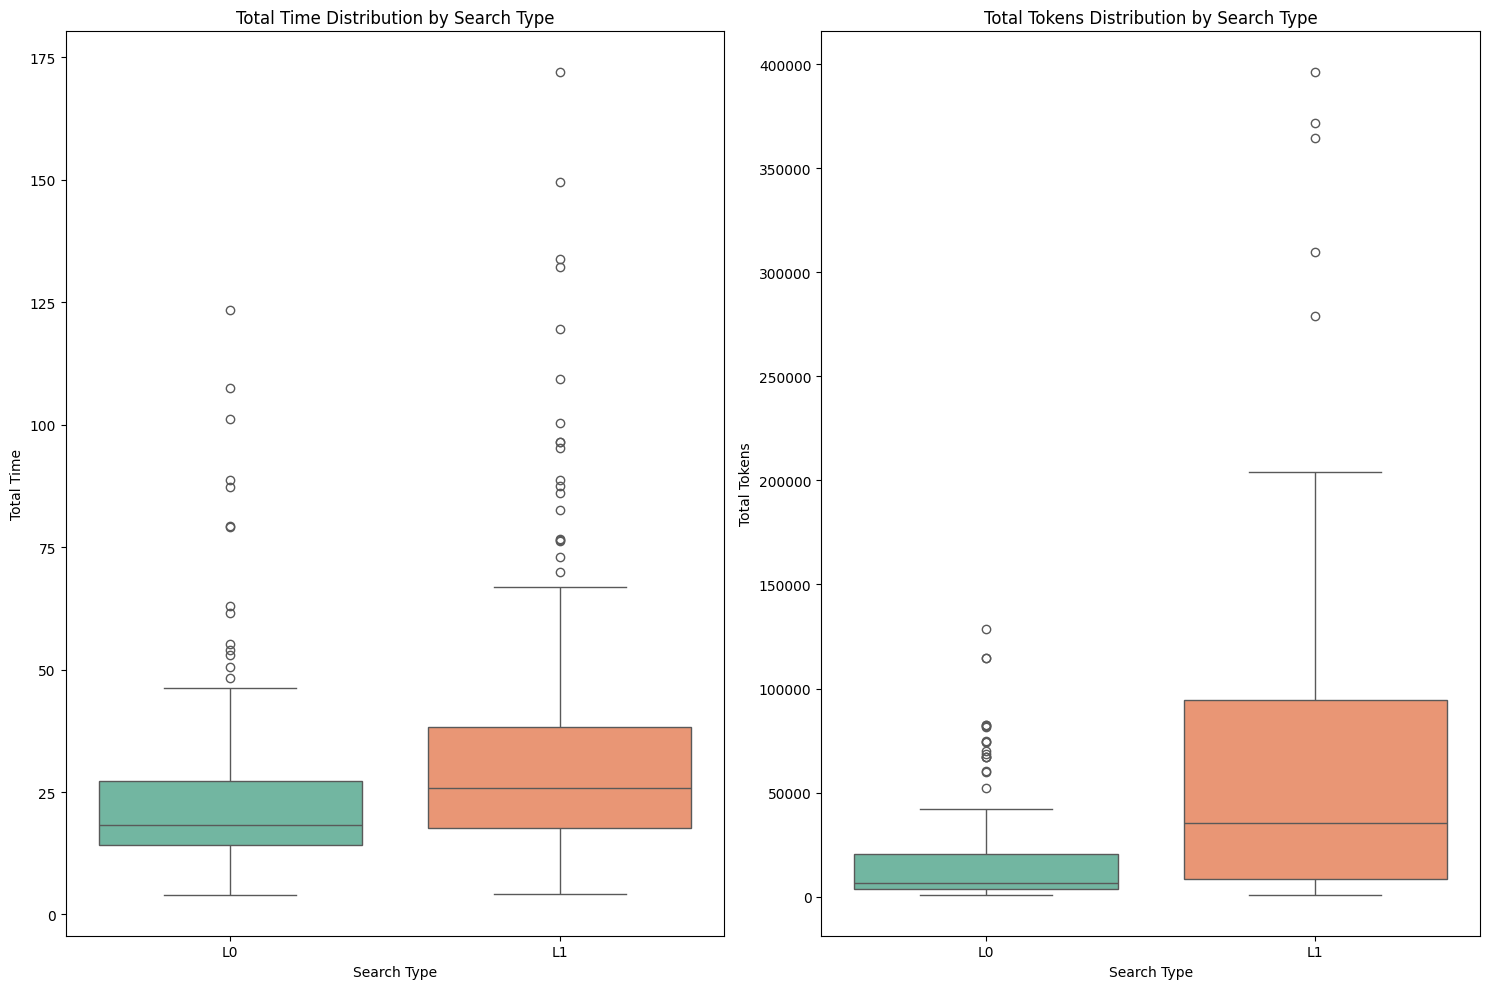

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
plt.title("Total Time Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Time")
plt.tight_layout()
# plt.xticks([])

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)
plt.title("Total Tokens Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Tokens")
# plt.legend(['Lexical Search', 'Similarity Search'], loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=True, ncol=5)

plt.tight_layout()

plt.show()

/tmp/ipykernel_26812/1347690214.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1347690214.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)


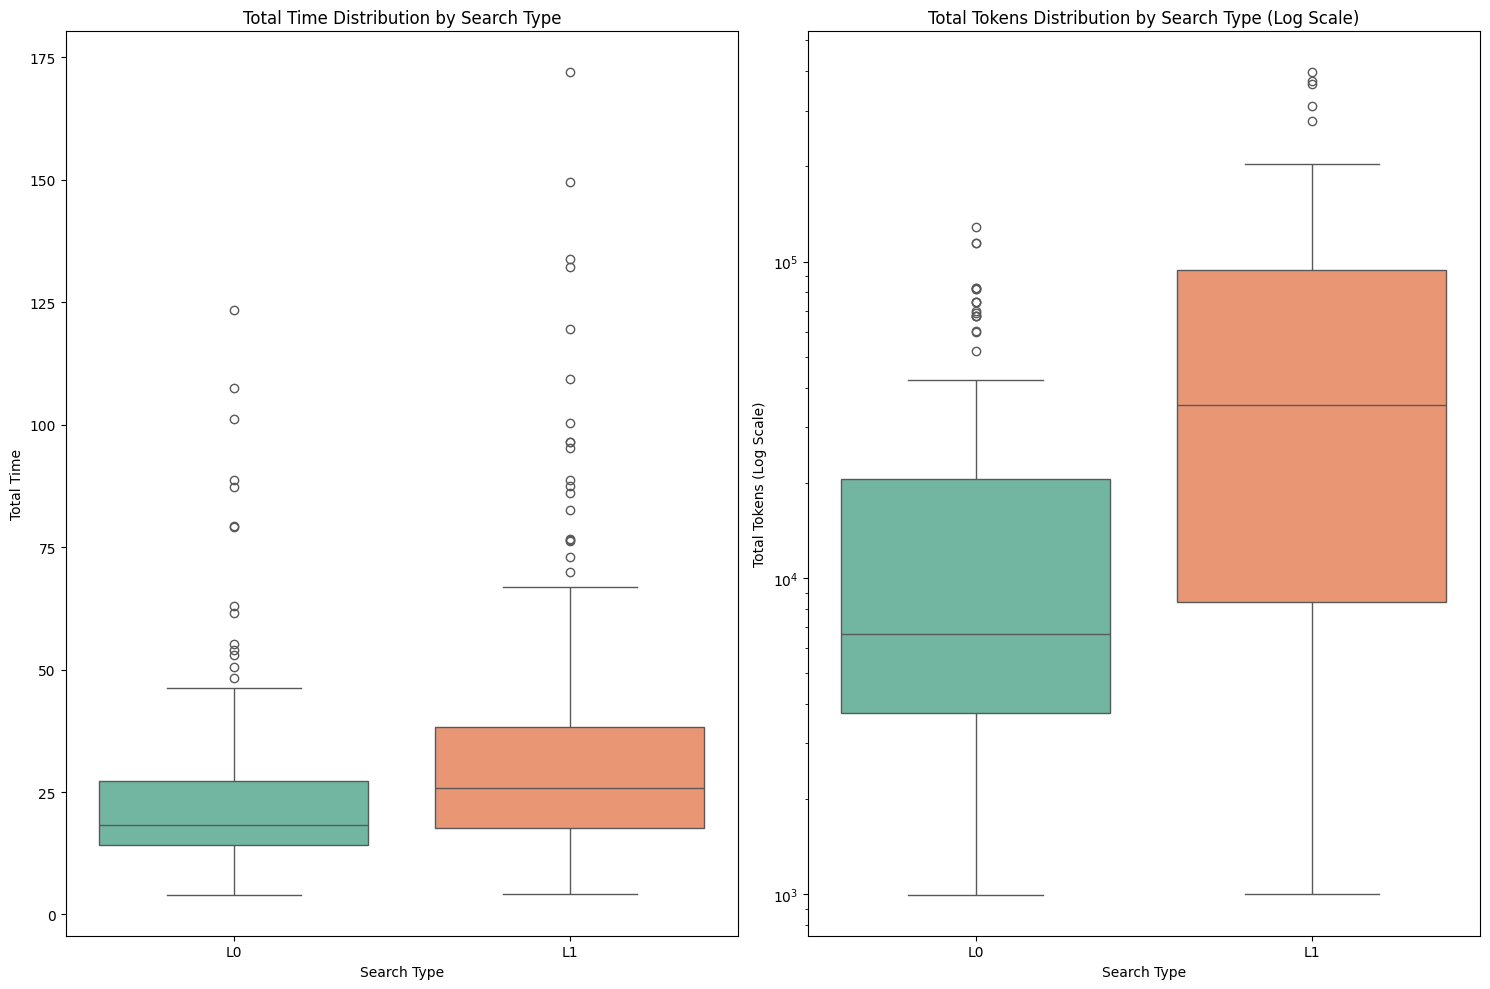

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
plt.title("Total Time Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Time")
plt.tight_layout()

# Box plot for total_tokens with log scale on y-axis
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title("Total Tokens Distribution by Search Type (Log Scale)")
plt.xlabel("Search Type")
plt.ylabel("Total Tokens (Log Scale)")
plt.tight_layout()

plt.show()

## By model

Boxplots for model:  gemini-1.5-pro


/tmp/ipykernel_26812/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


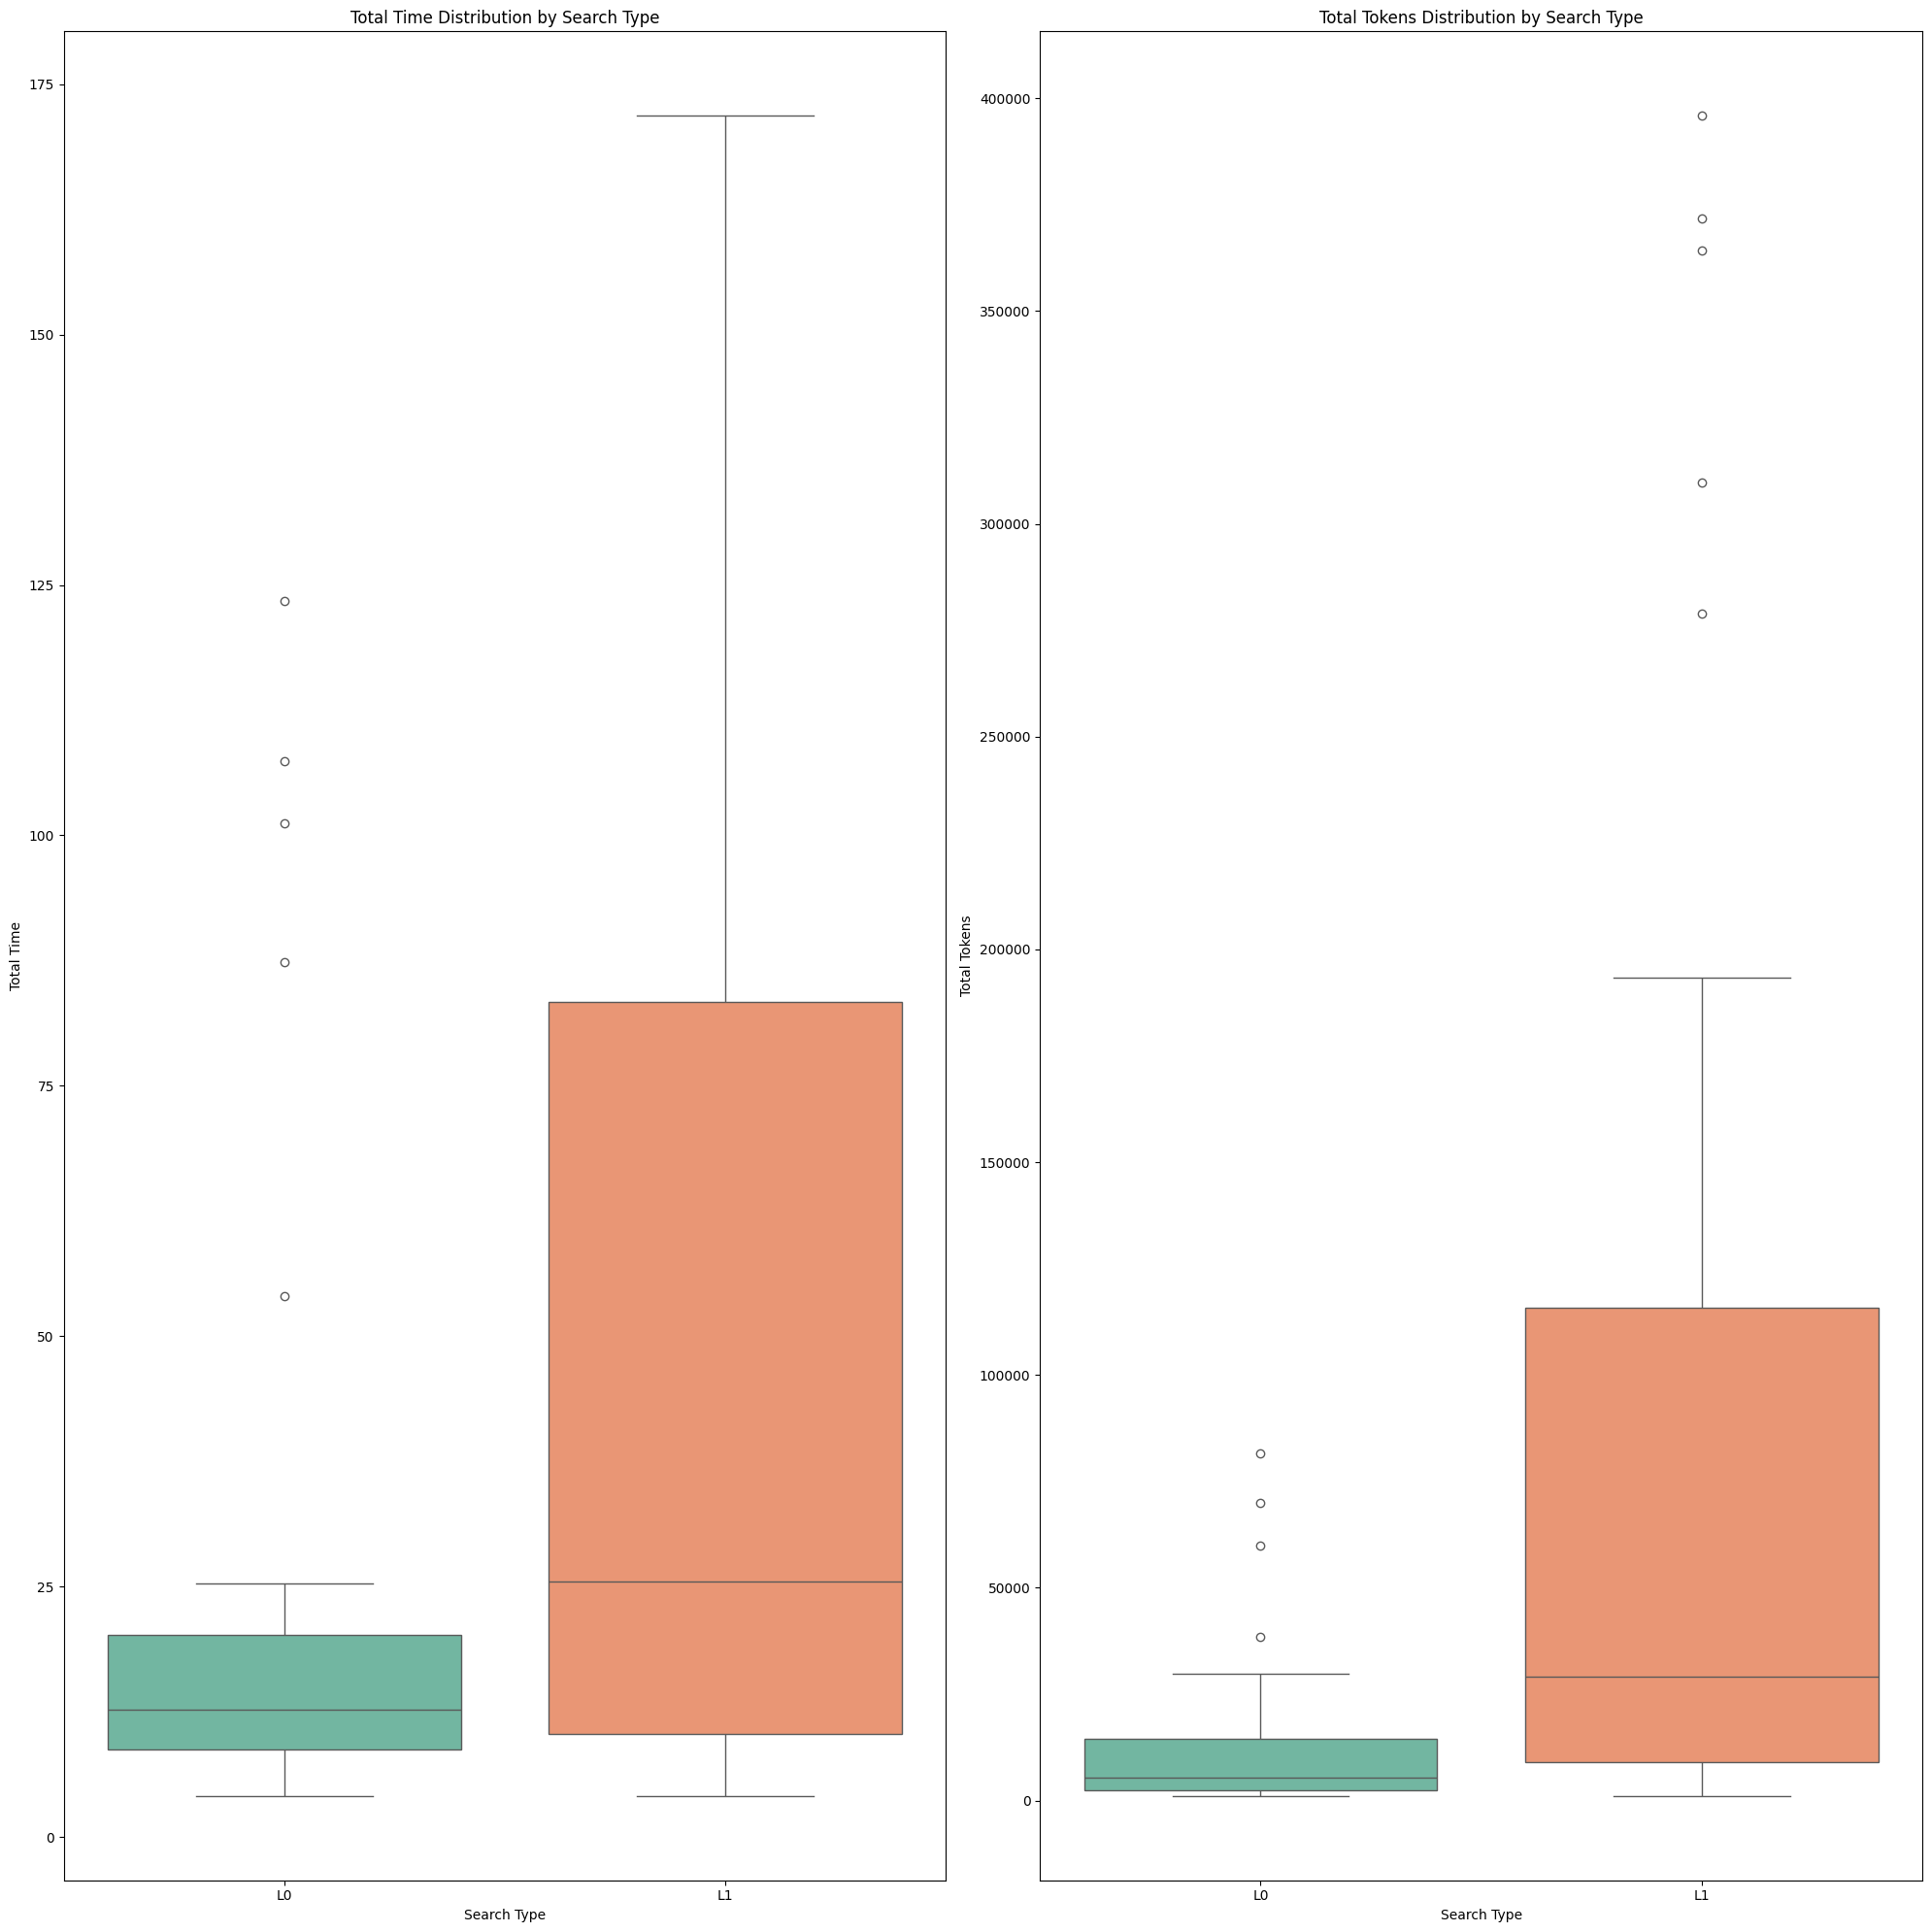

Boxplots for model:  anthropic.claude-v3-opus


/tmp/ipykernel_26812/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


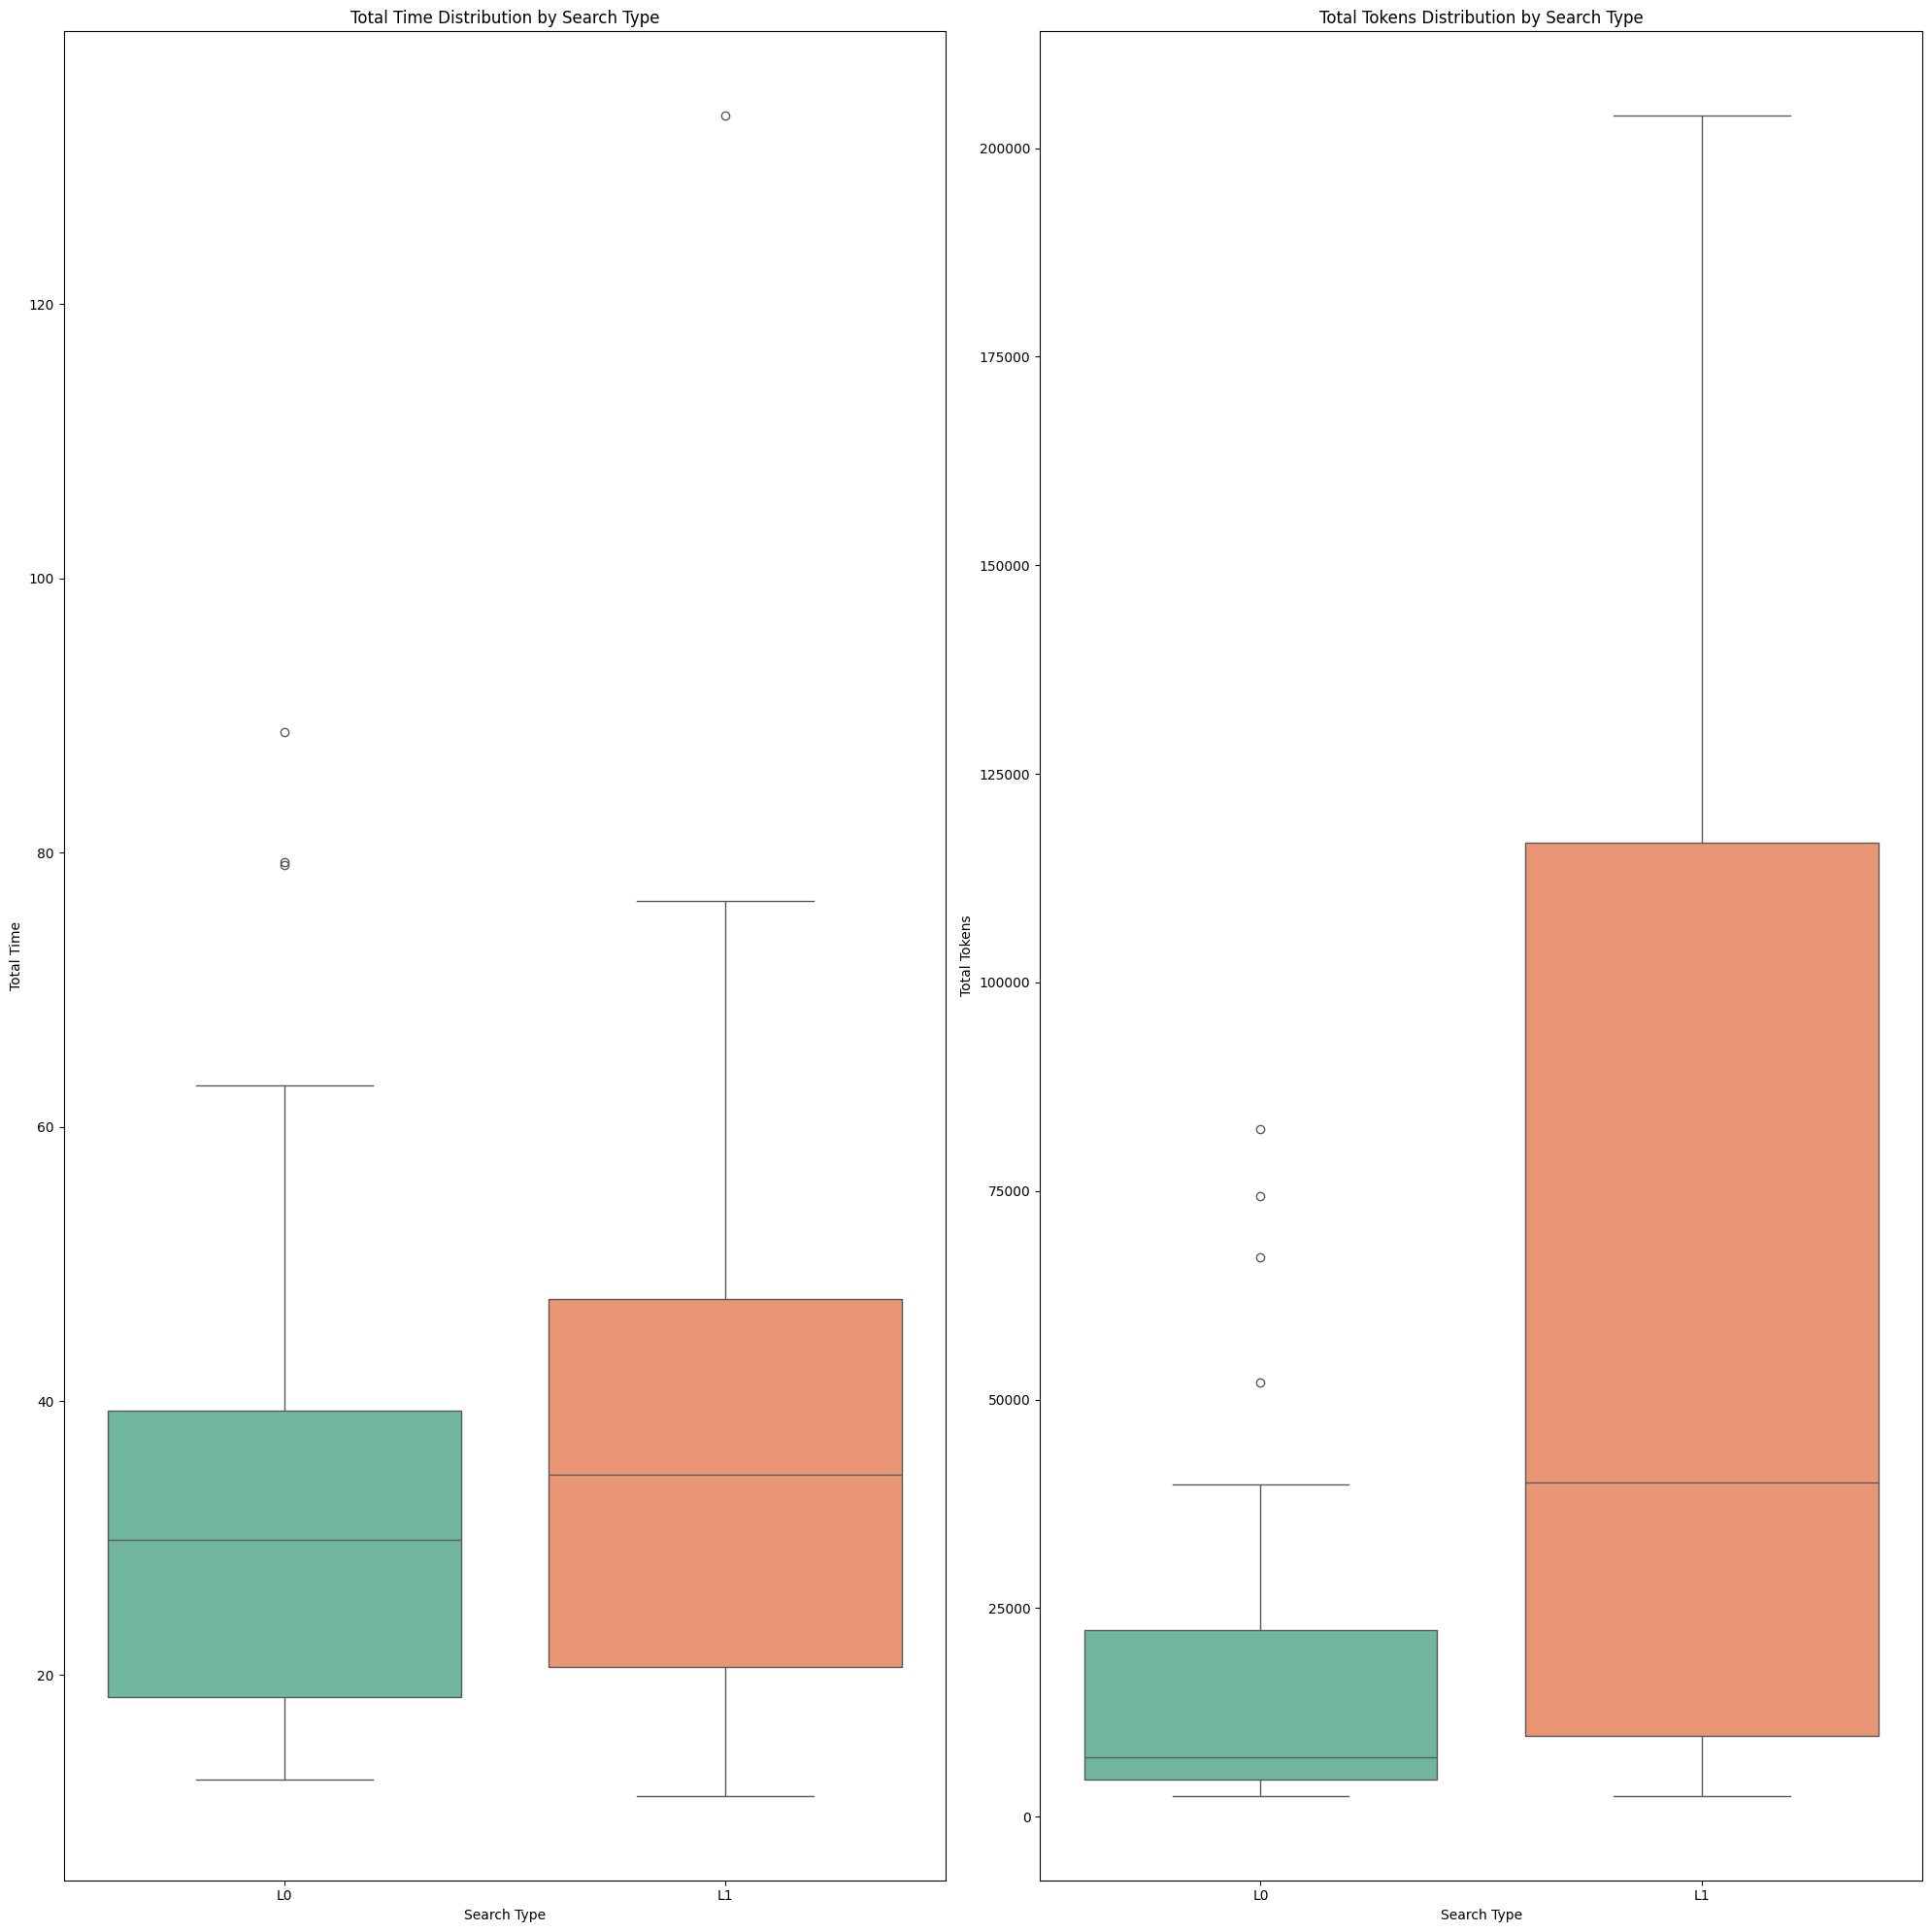

Boxplots for model:  DeepSeek-R1-Distill-Llama-70B-FP8


/tmp/ipykernel_26812/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


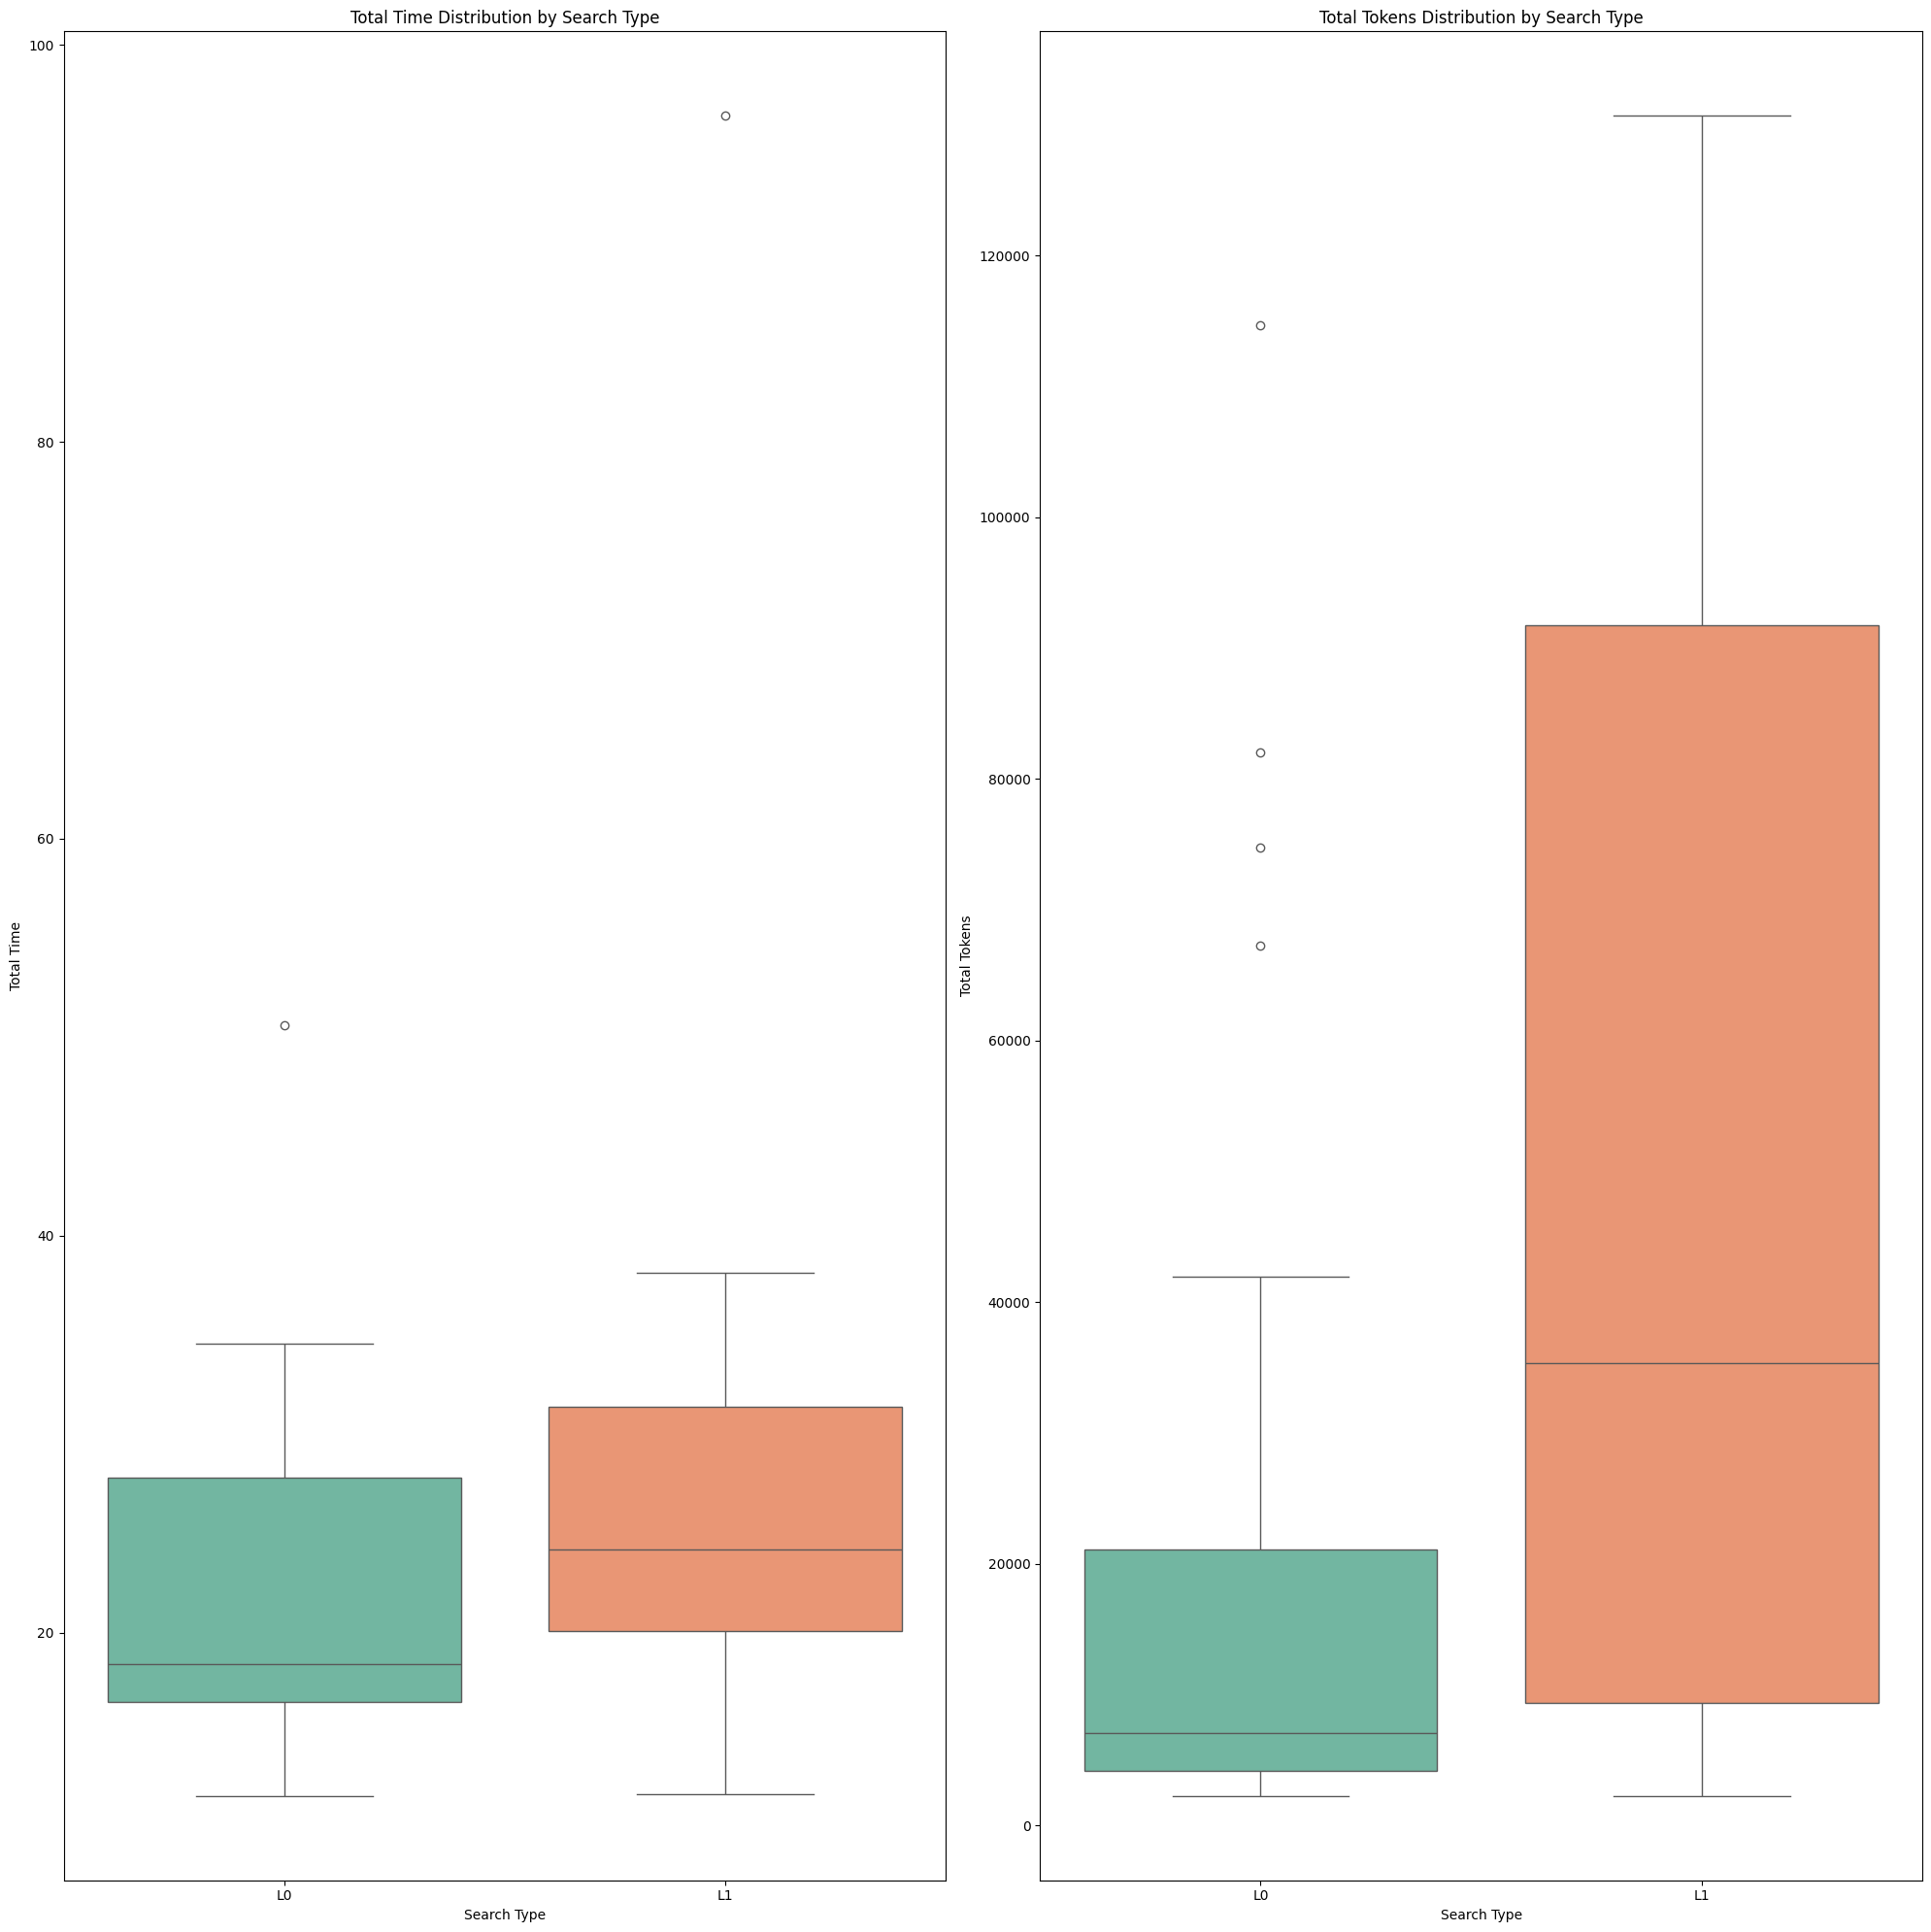

Boxplots for model:  gpt-4o-2024-08-06


/tmp/ipykernel_26812/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


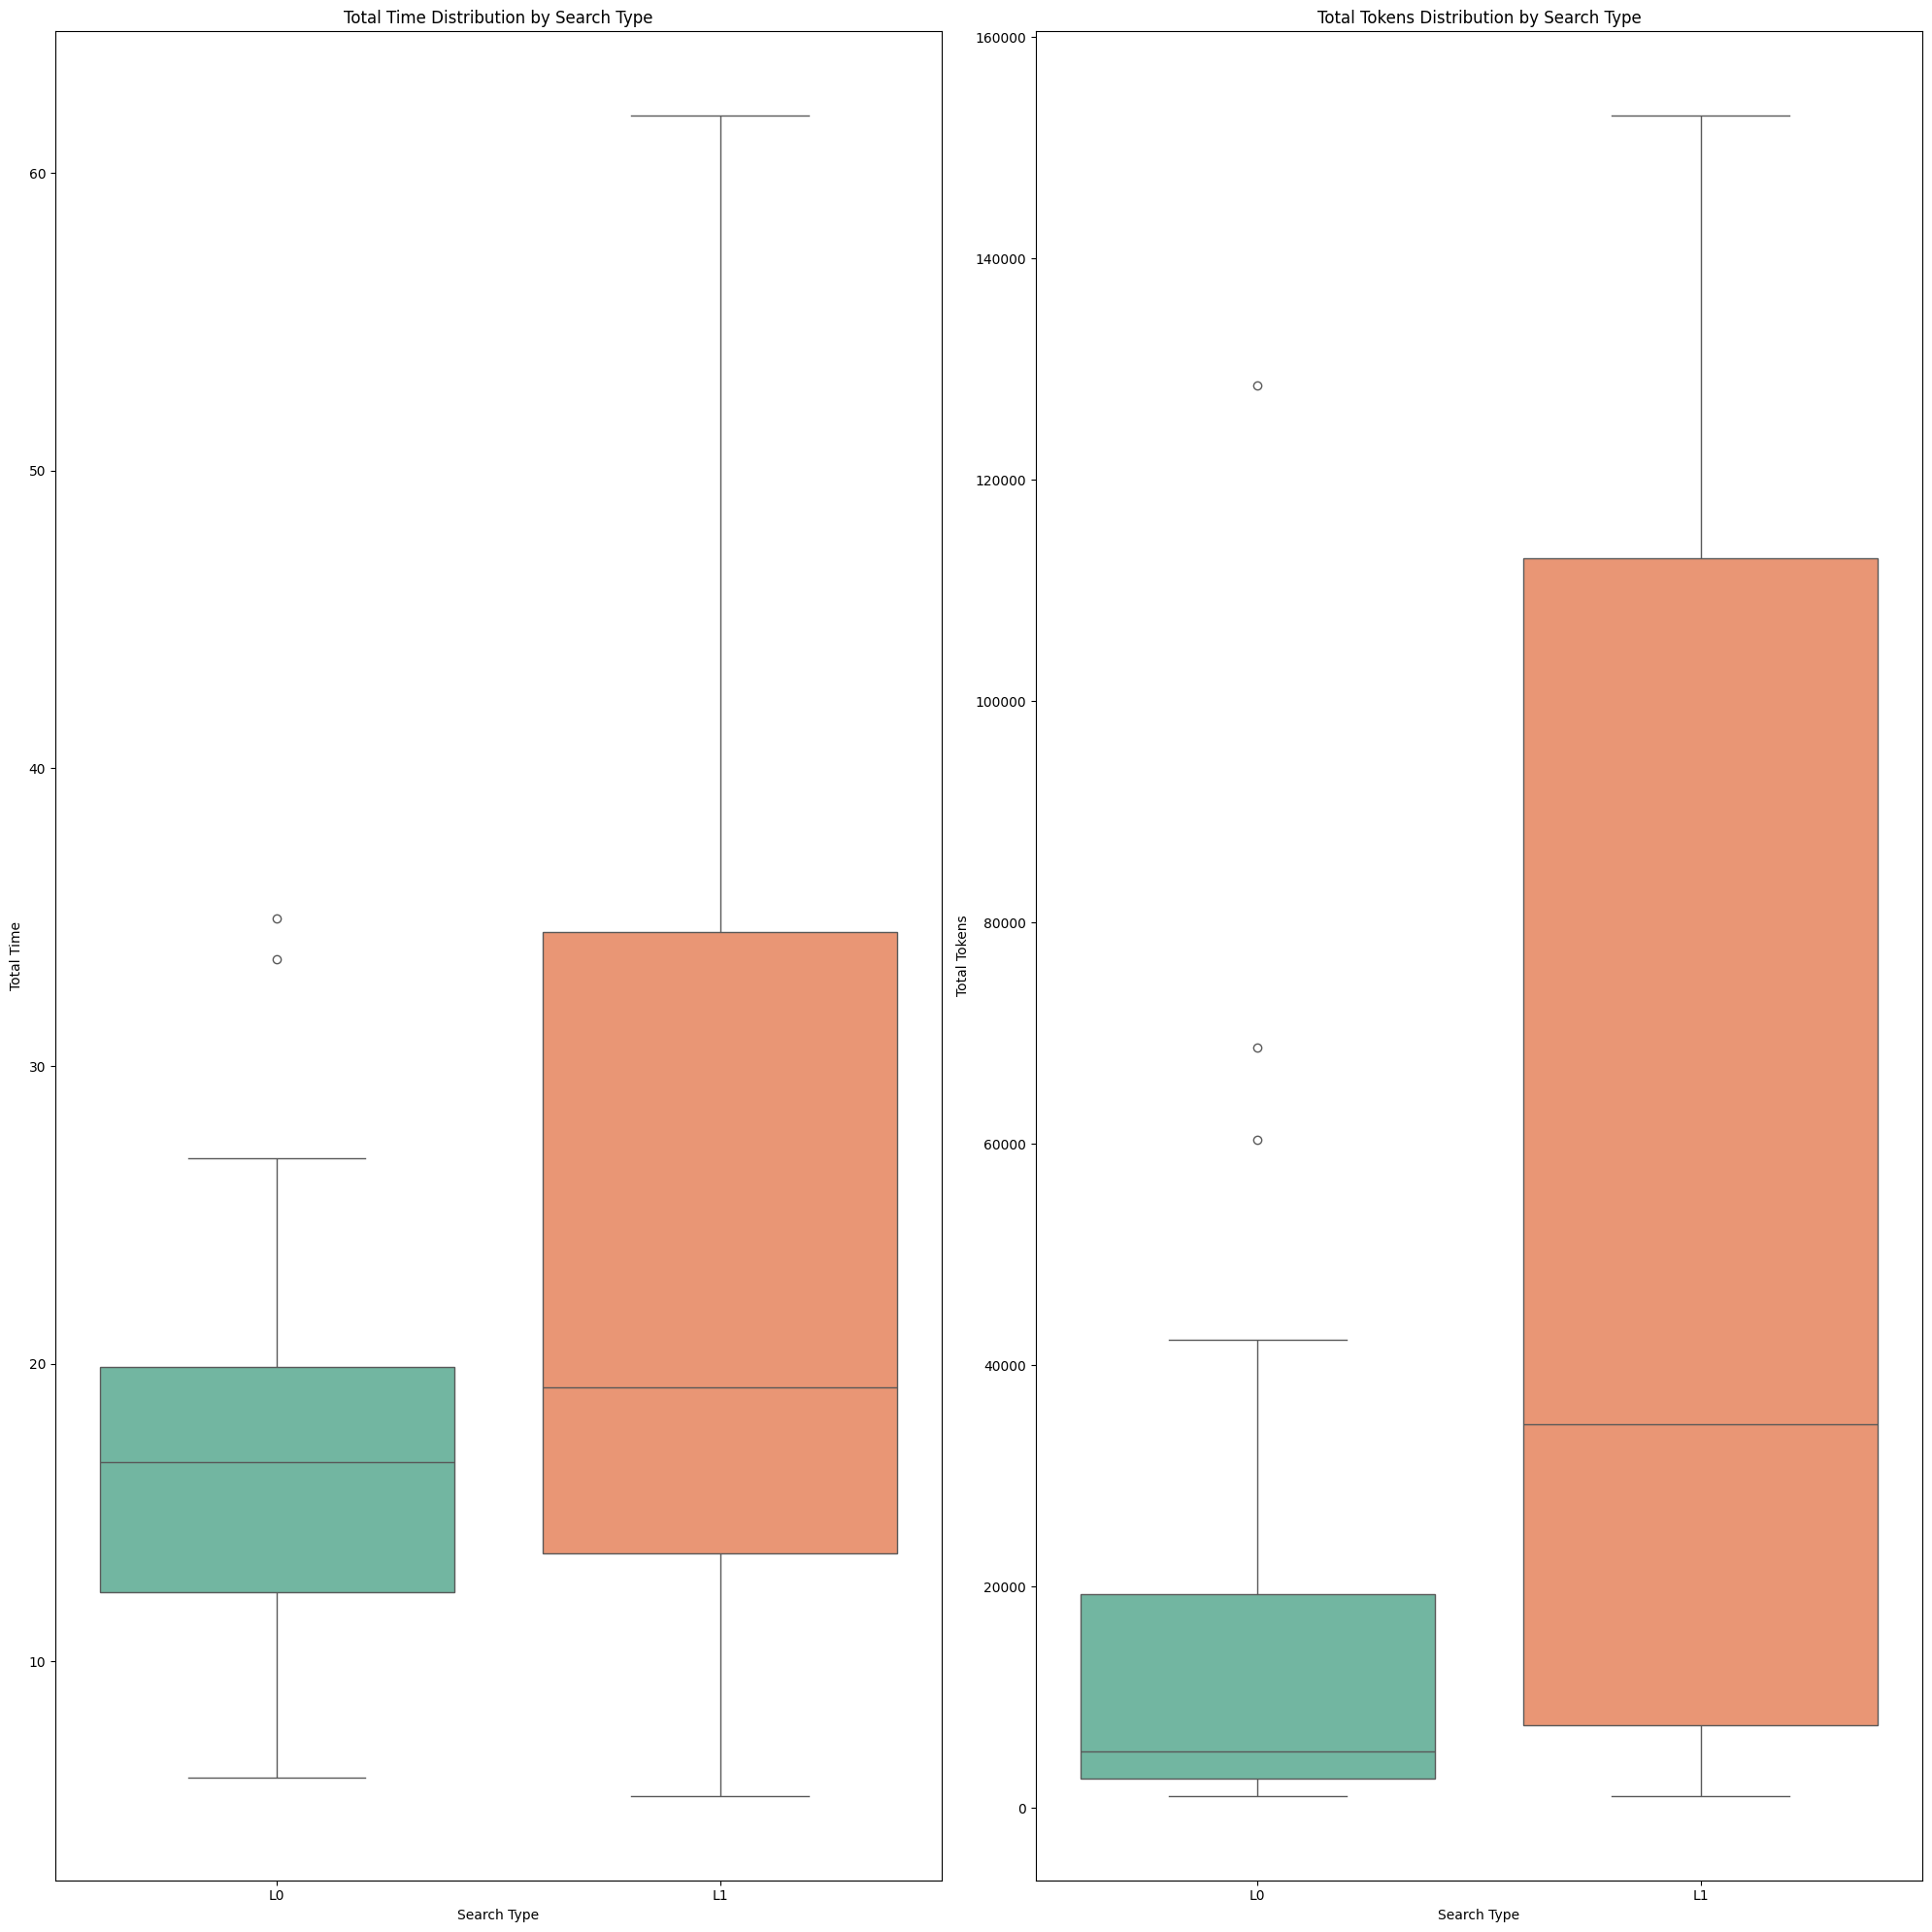

Boxplots for model:  llama-3-70b-instruct-awq


/tmp/ipykernel_26812/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


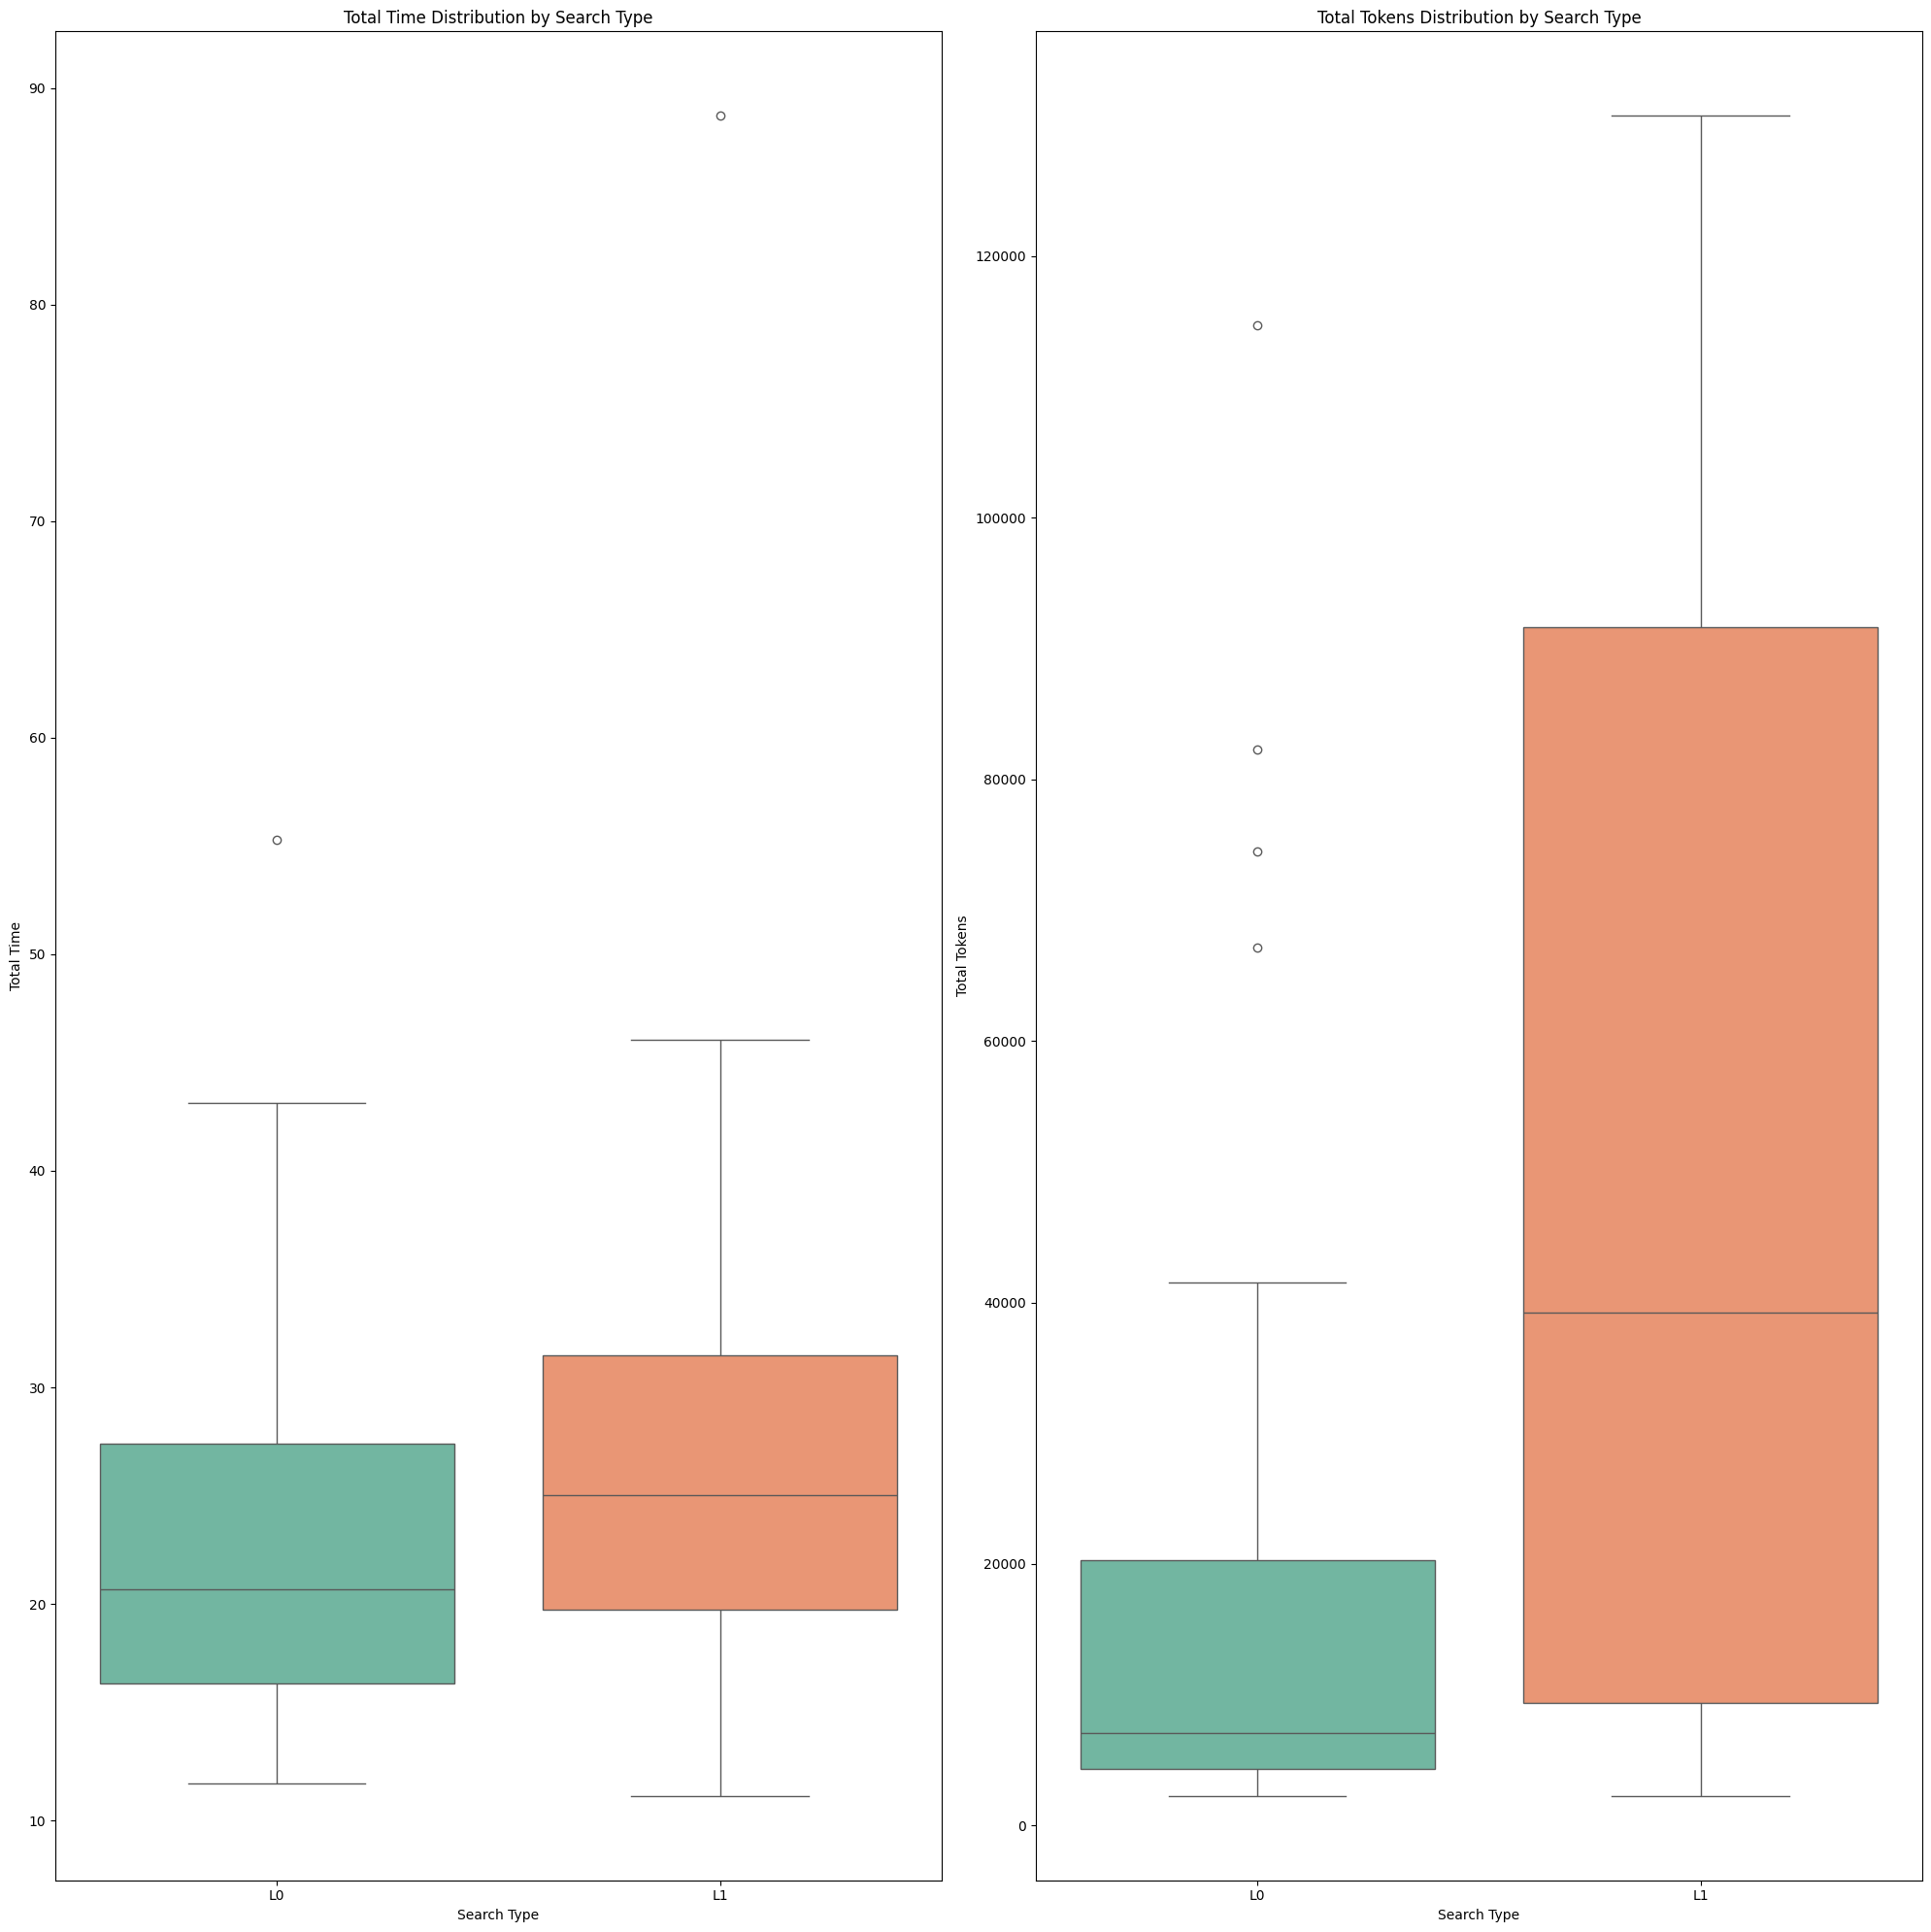

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

for model in set(df["model"].unique()):
    print("Boxplots for model: ", model)
    df_model = df[df["model"] == model]
    plt.figure(figsize=(20, 20))
    
    # Box plot for total_time
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    plt.title("Total Time Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Time")
    plt.tight_layout()
    # plt.xticks([])
    
    # Box plot for total_tokens
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    plt.title("Total Tokens Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Tokens")
    # plt.legend(['Lexical Search', 'Similarity Search'], loc='upper center', bbox_to_anchor=(0.5, -0.05),
    #           fancybox=True, shadow=True, ncol=5)
    
    plt.tight_layout()
    
    plt.show()

## Same scale

Boxplots for model:  gemini-1.5-pro


/tmp/ipykernel_26812/3294823564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3294823564.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


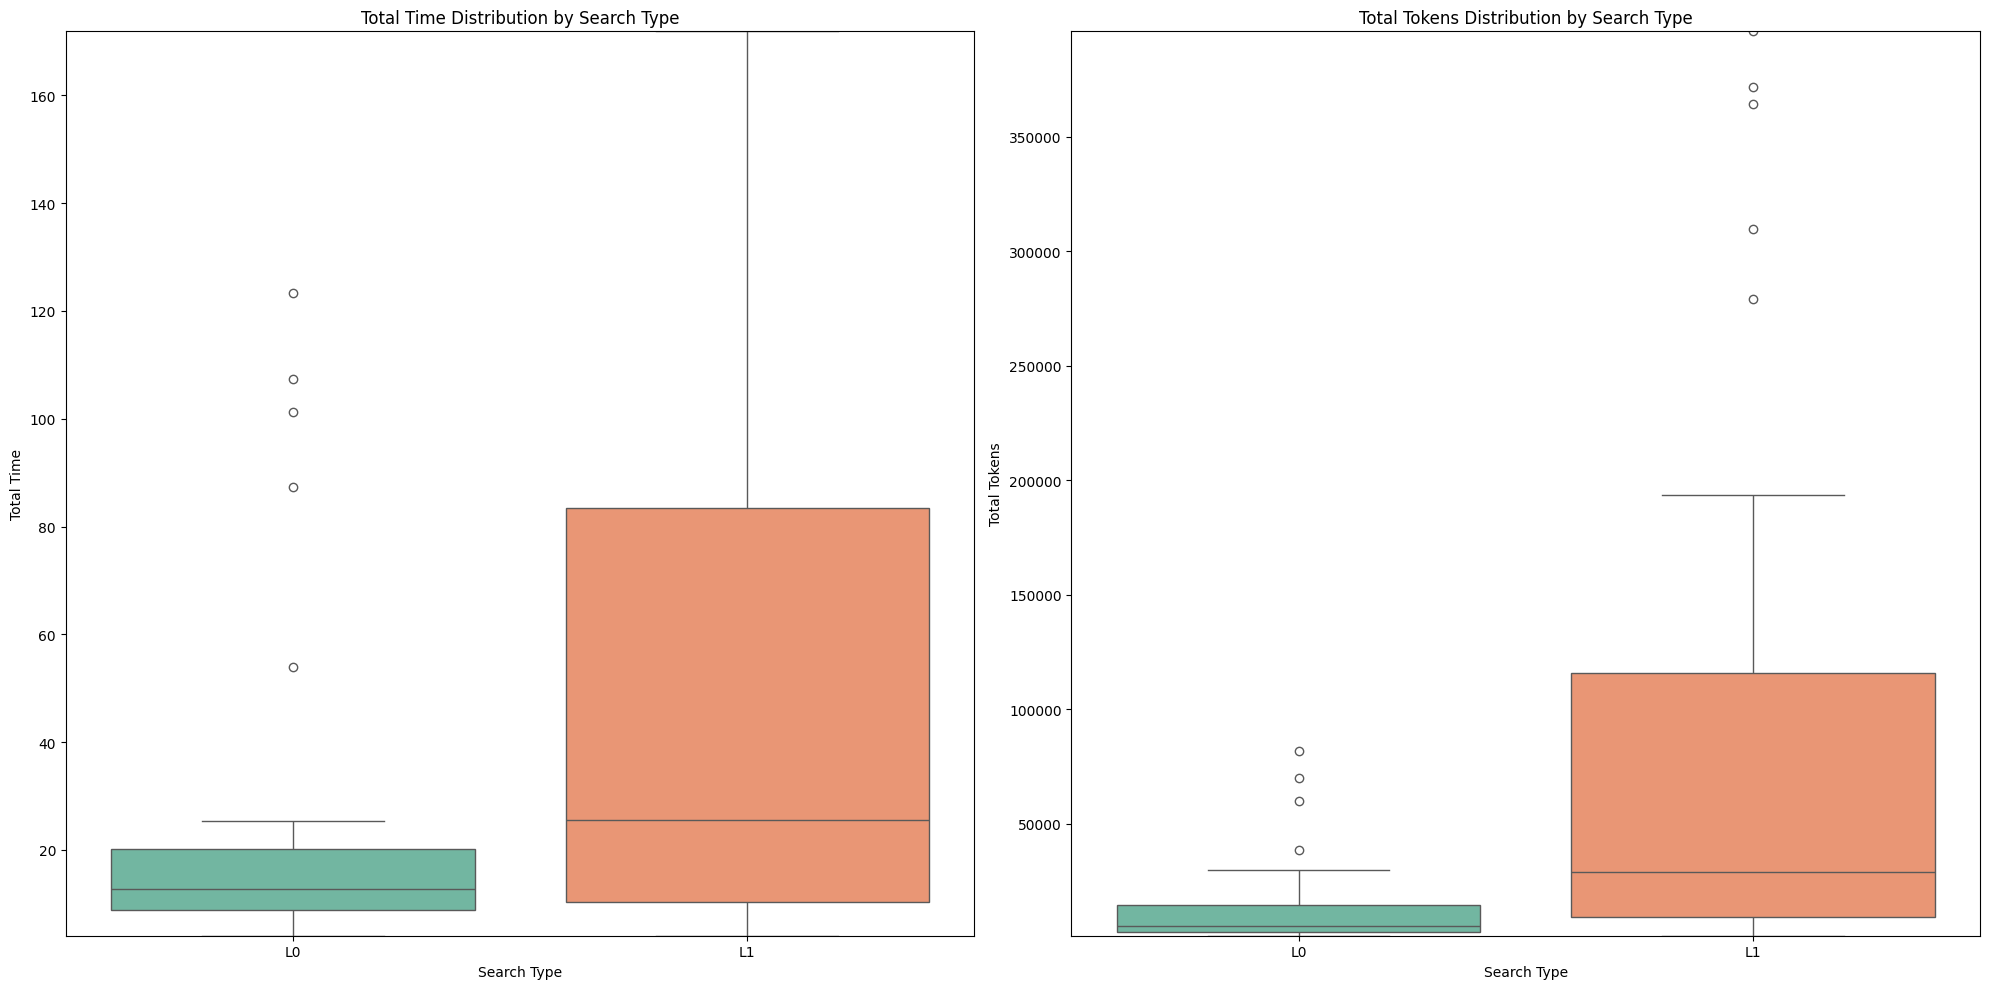

Boxplots for model:  anthropic.claude-v3-opus


/tmp/ipykernel_26812/3294823564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3294823564.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


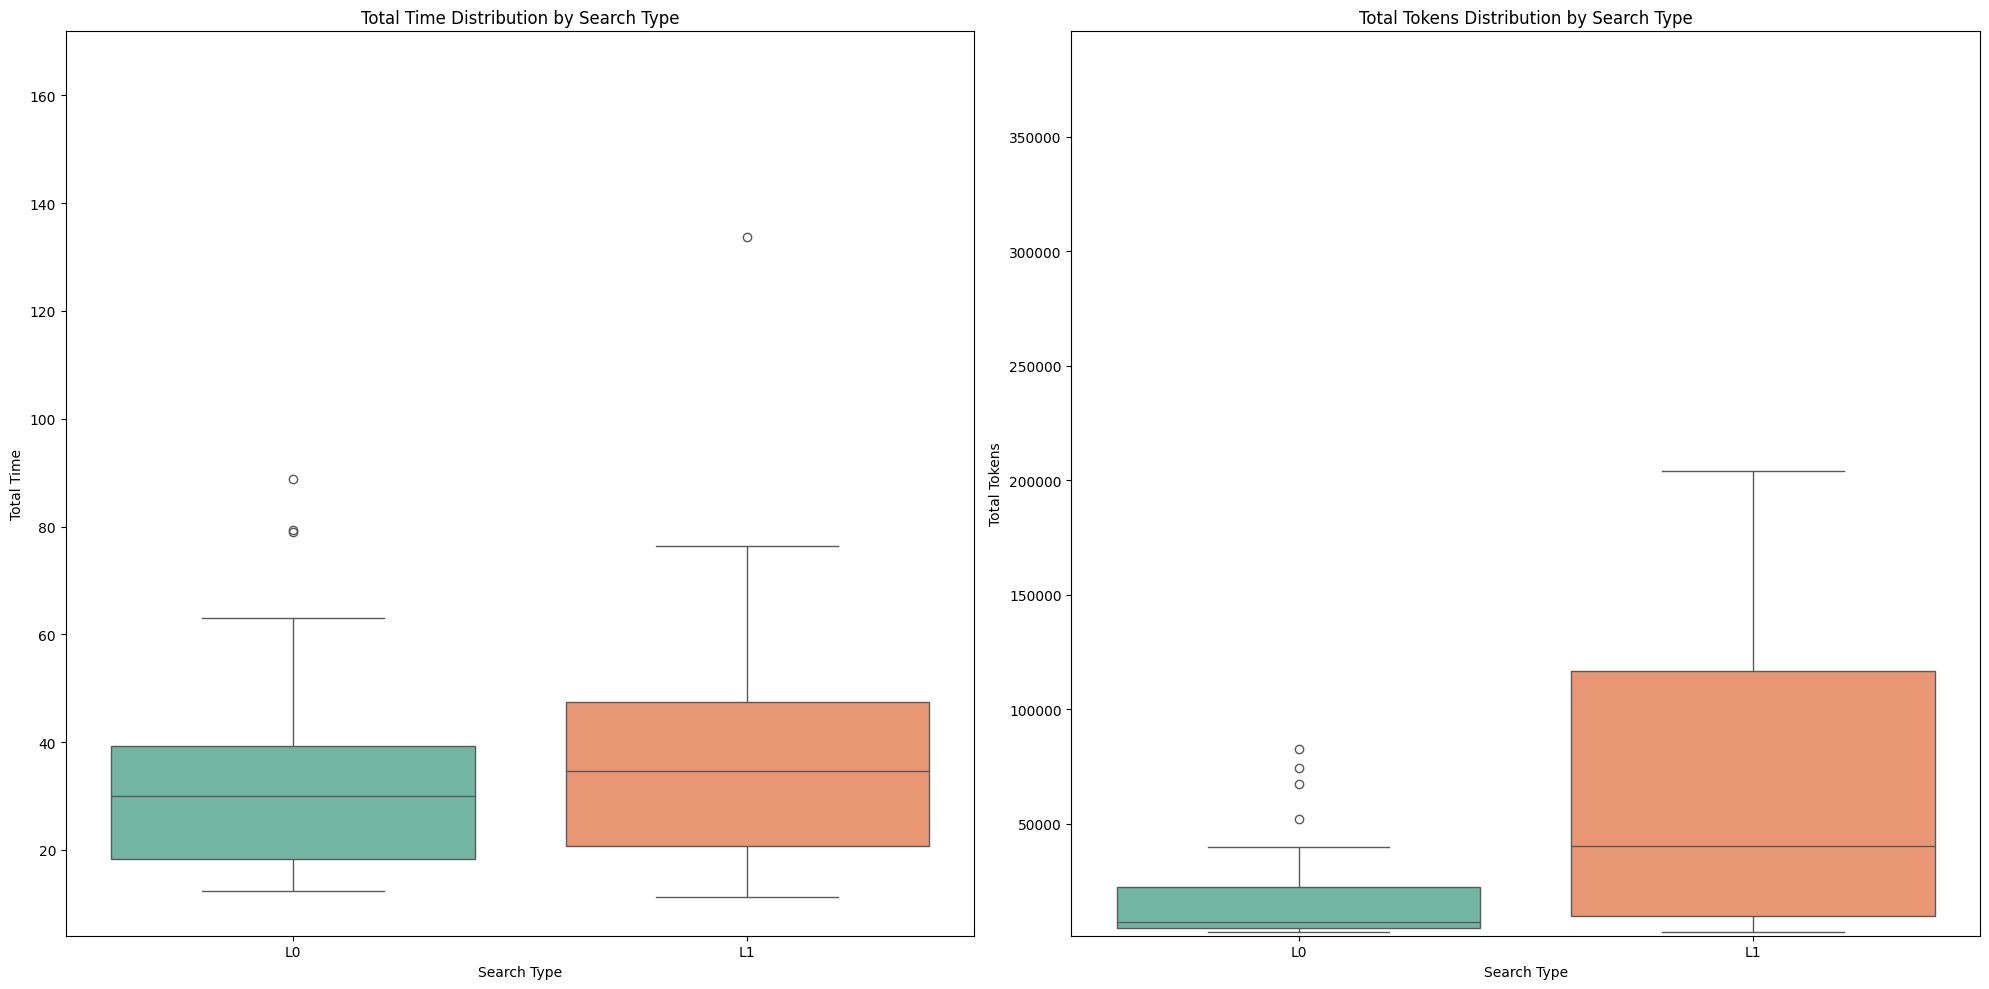

Boxplots for model:  DeepSeek-R1-Distill-Llama-70B-FP8


/tmp/ipykernel_26812/3294823564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3294823564.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


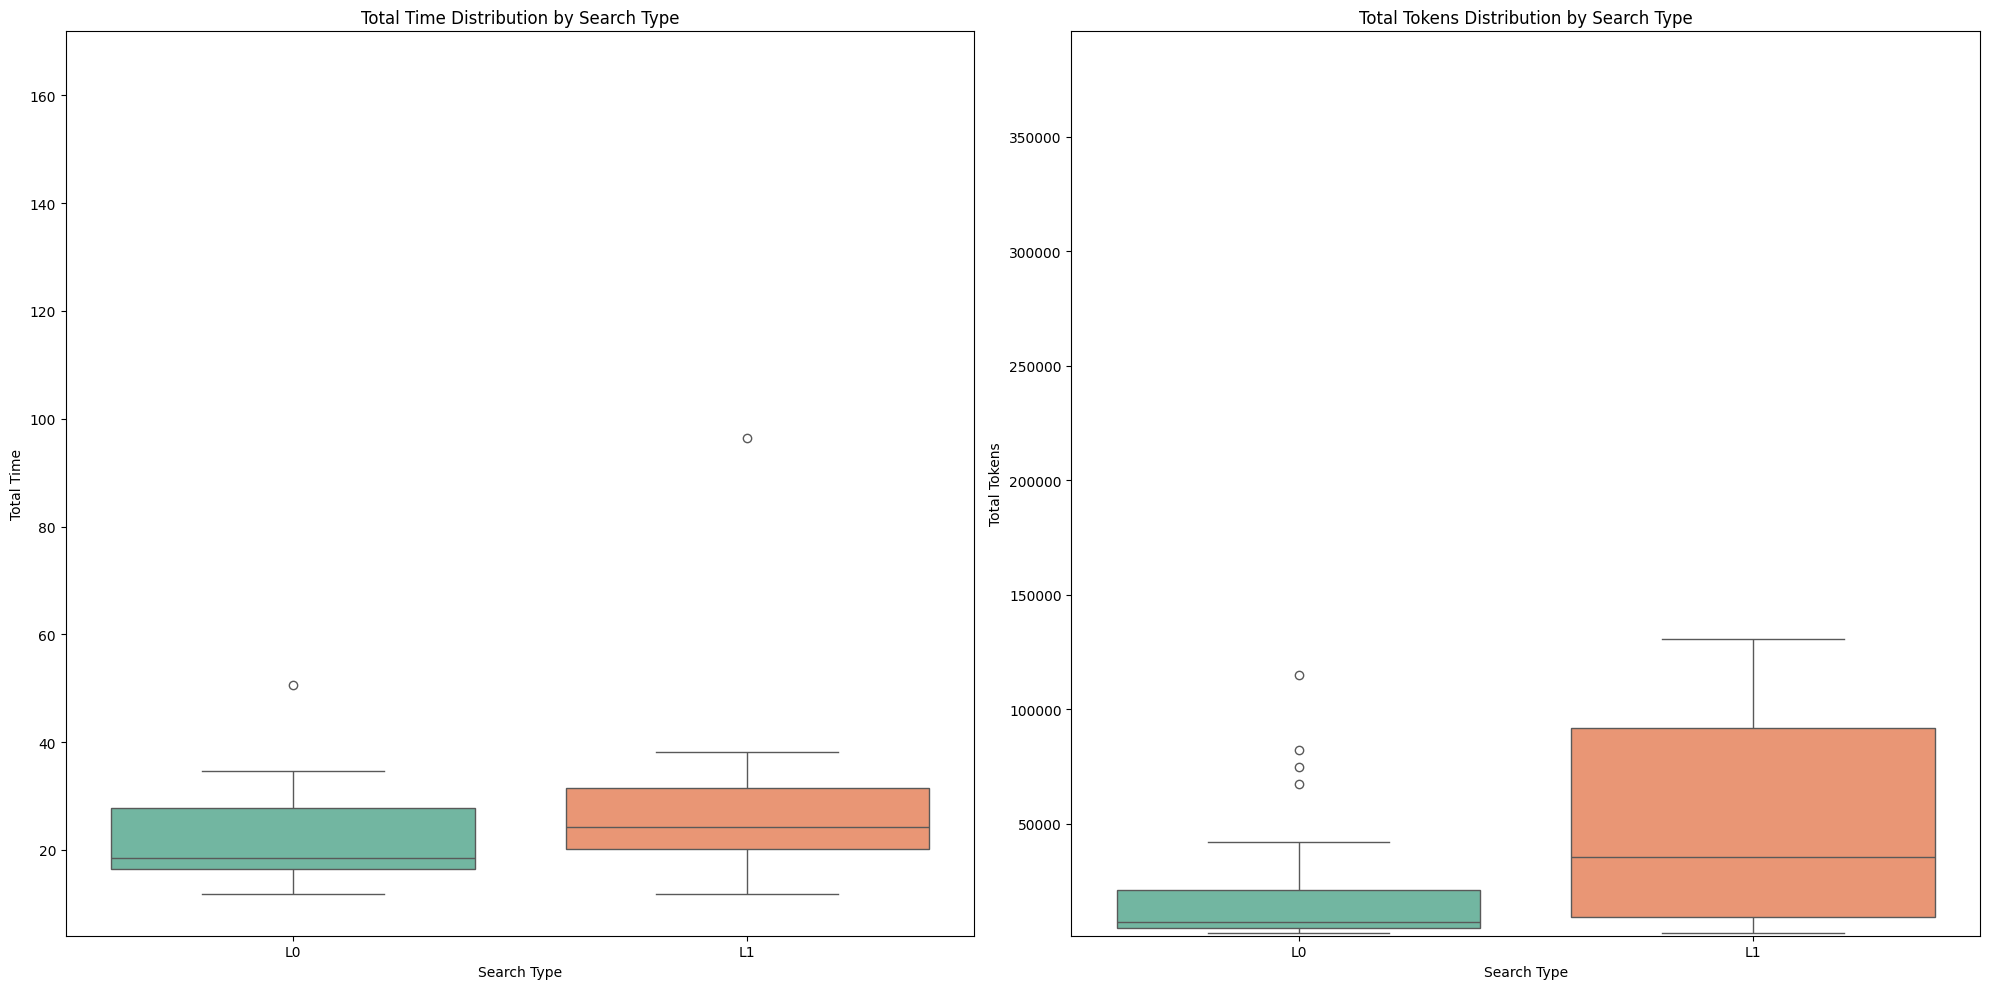

Boxplots for model:  gpt-4o-2024-08-06


/tmp/ipykernel_26812/3294823564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3294823564.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


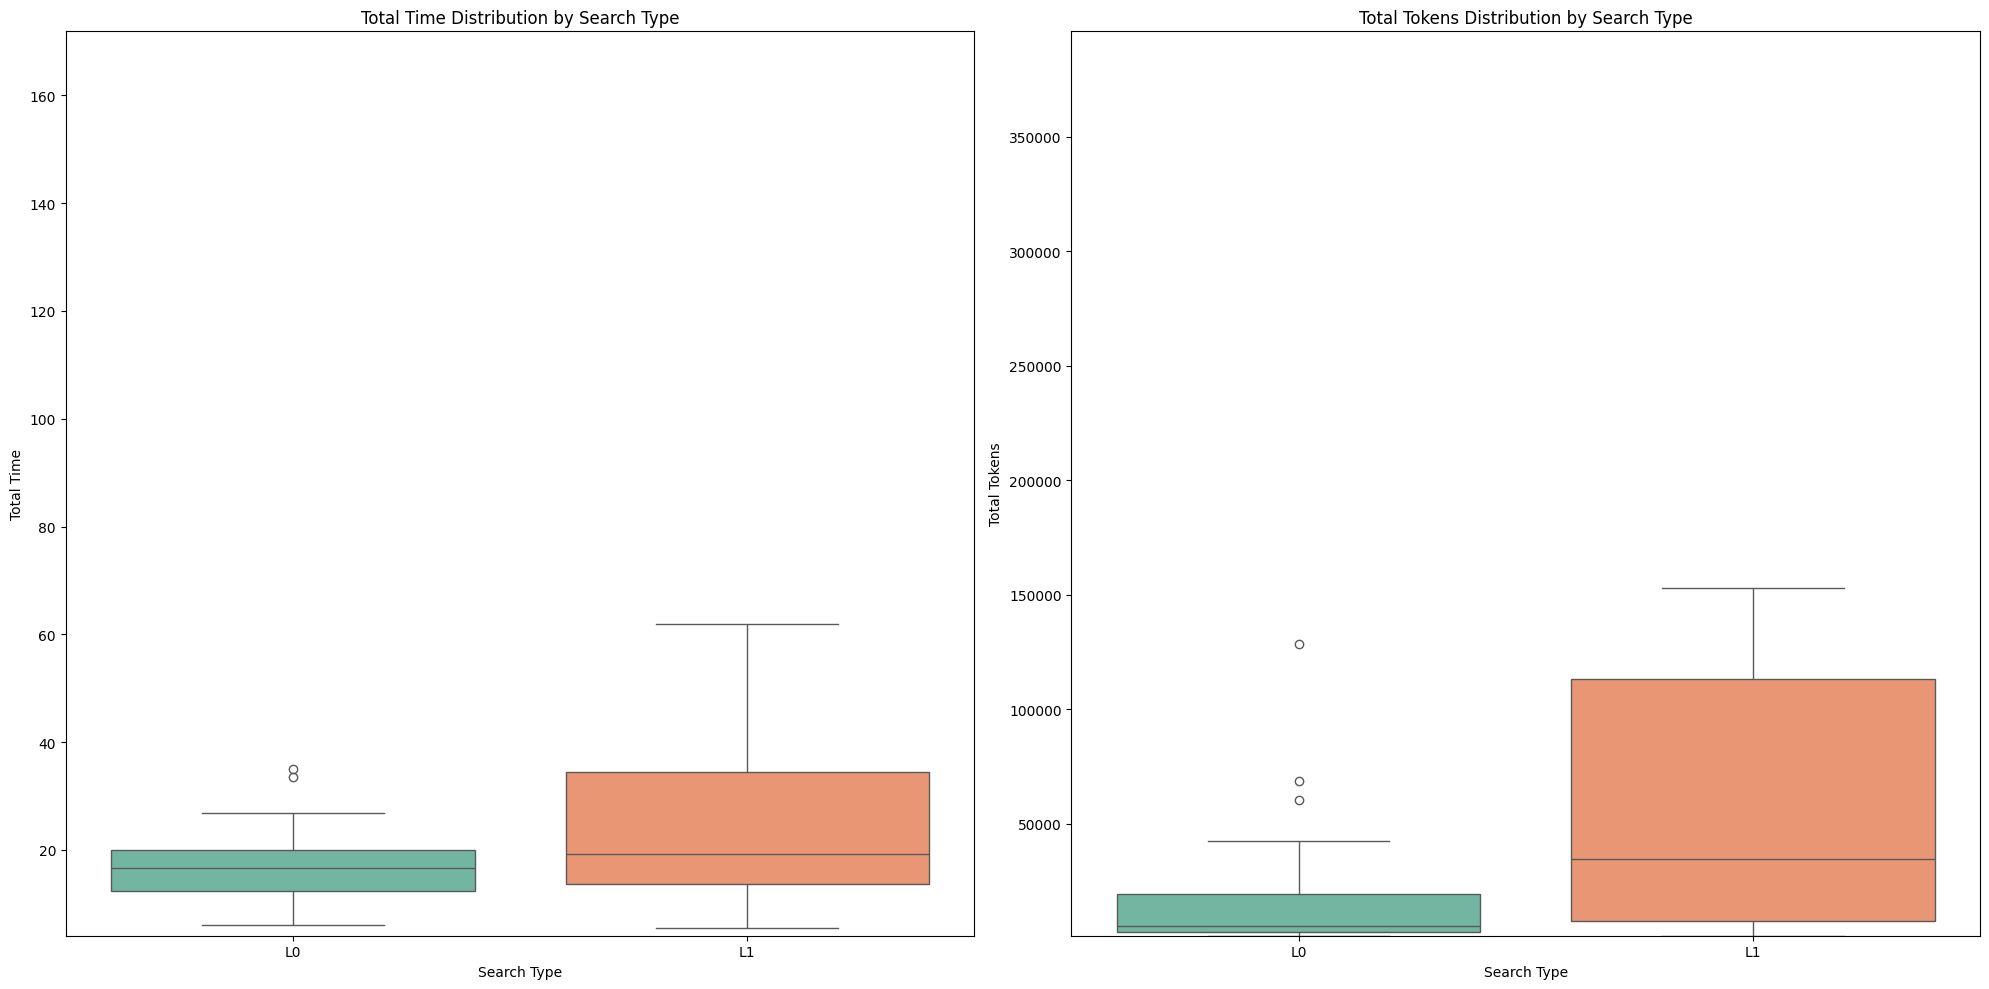

Boxplots for model:  llama-3-70b-instruct-awq


/tmp/ipykernel_26812/3294823564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3294823564.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


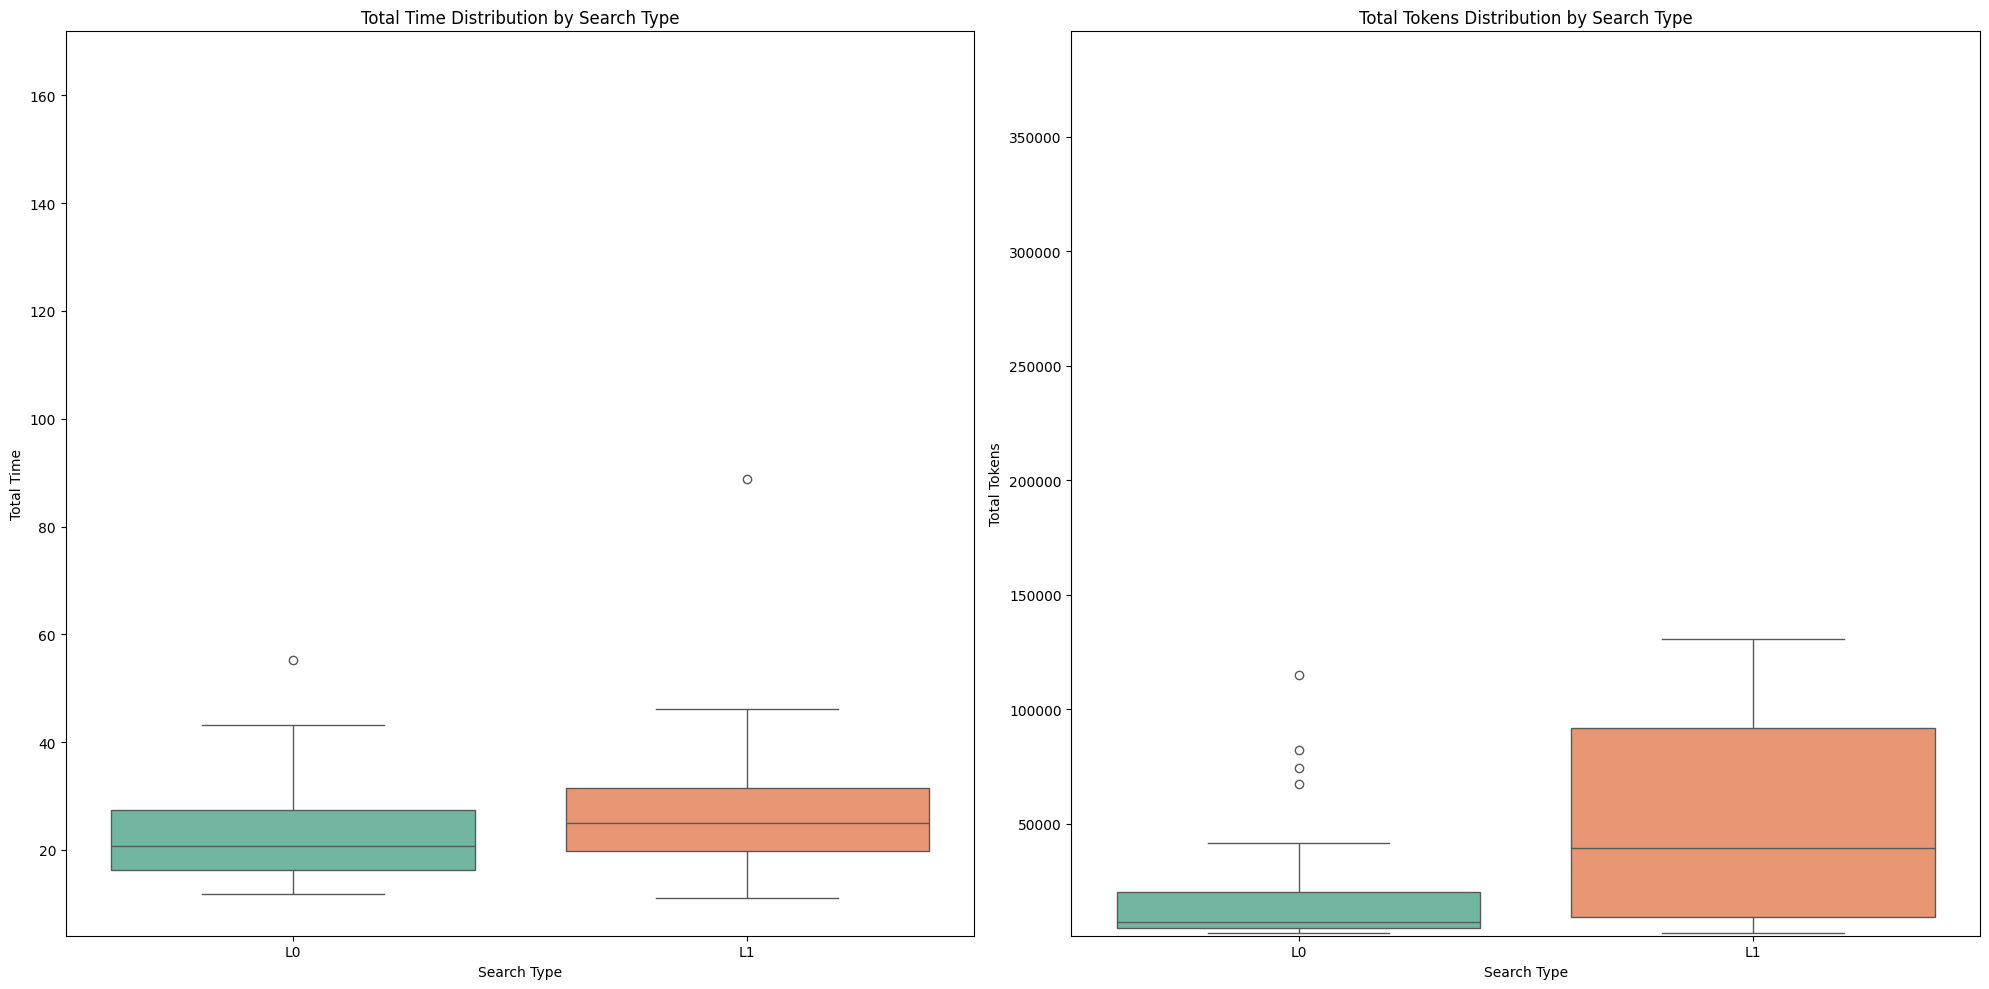

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and it has columns: 'model', 'search_type', 'total_time', 'total_tokens'

# Determine the global y-axis limits for both 'total_time' and 'total_tokens'
global_total_time_min = df['total_time'].min()
global_total_time_max = df['total_time'].max()

global_total_tokens_min = df['total_tokens'].min()
global_total_tokens_max = df['total_tokens'].max()

for model in set(df["model"].unique()):
    print("Boxplots for model: ", model)
    df_model = df[df["model"] == model]
    plt.figure(figsize=(20, 10))
    
    # Box plot for total_time
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    plt.title("Total Time Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Time")
    plt.ylim(global_total_time_min, global_total_time_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    # Box plot for total_tokens
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    plt.title("Total Tokens Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Tokens")
    plt.ylim(global_total_tokens_min, global_total_tokens_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    plt.show()

/tmp/ipykernel_26812/3738376513.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3738376513.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3738376513.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/3

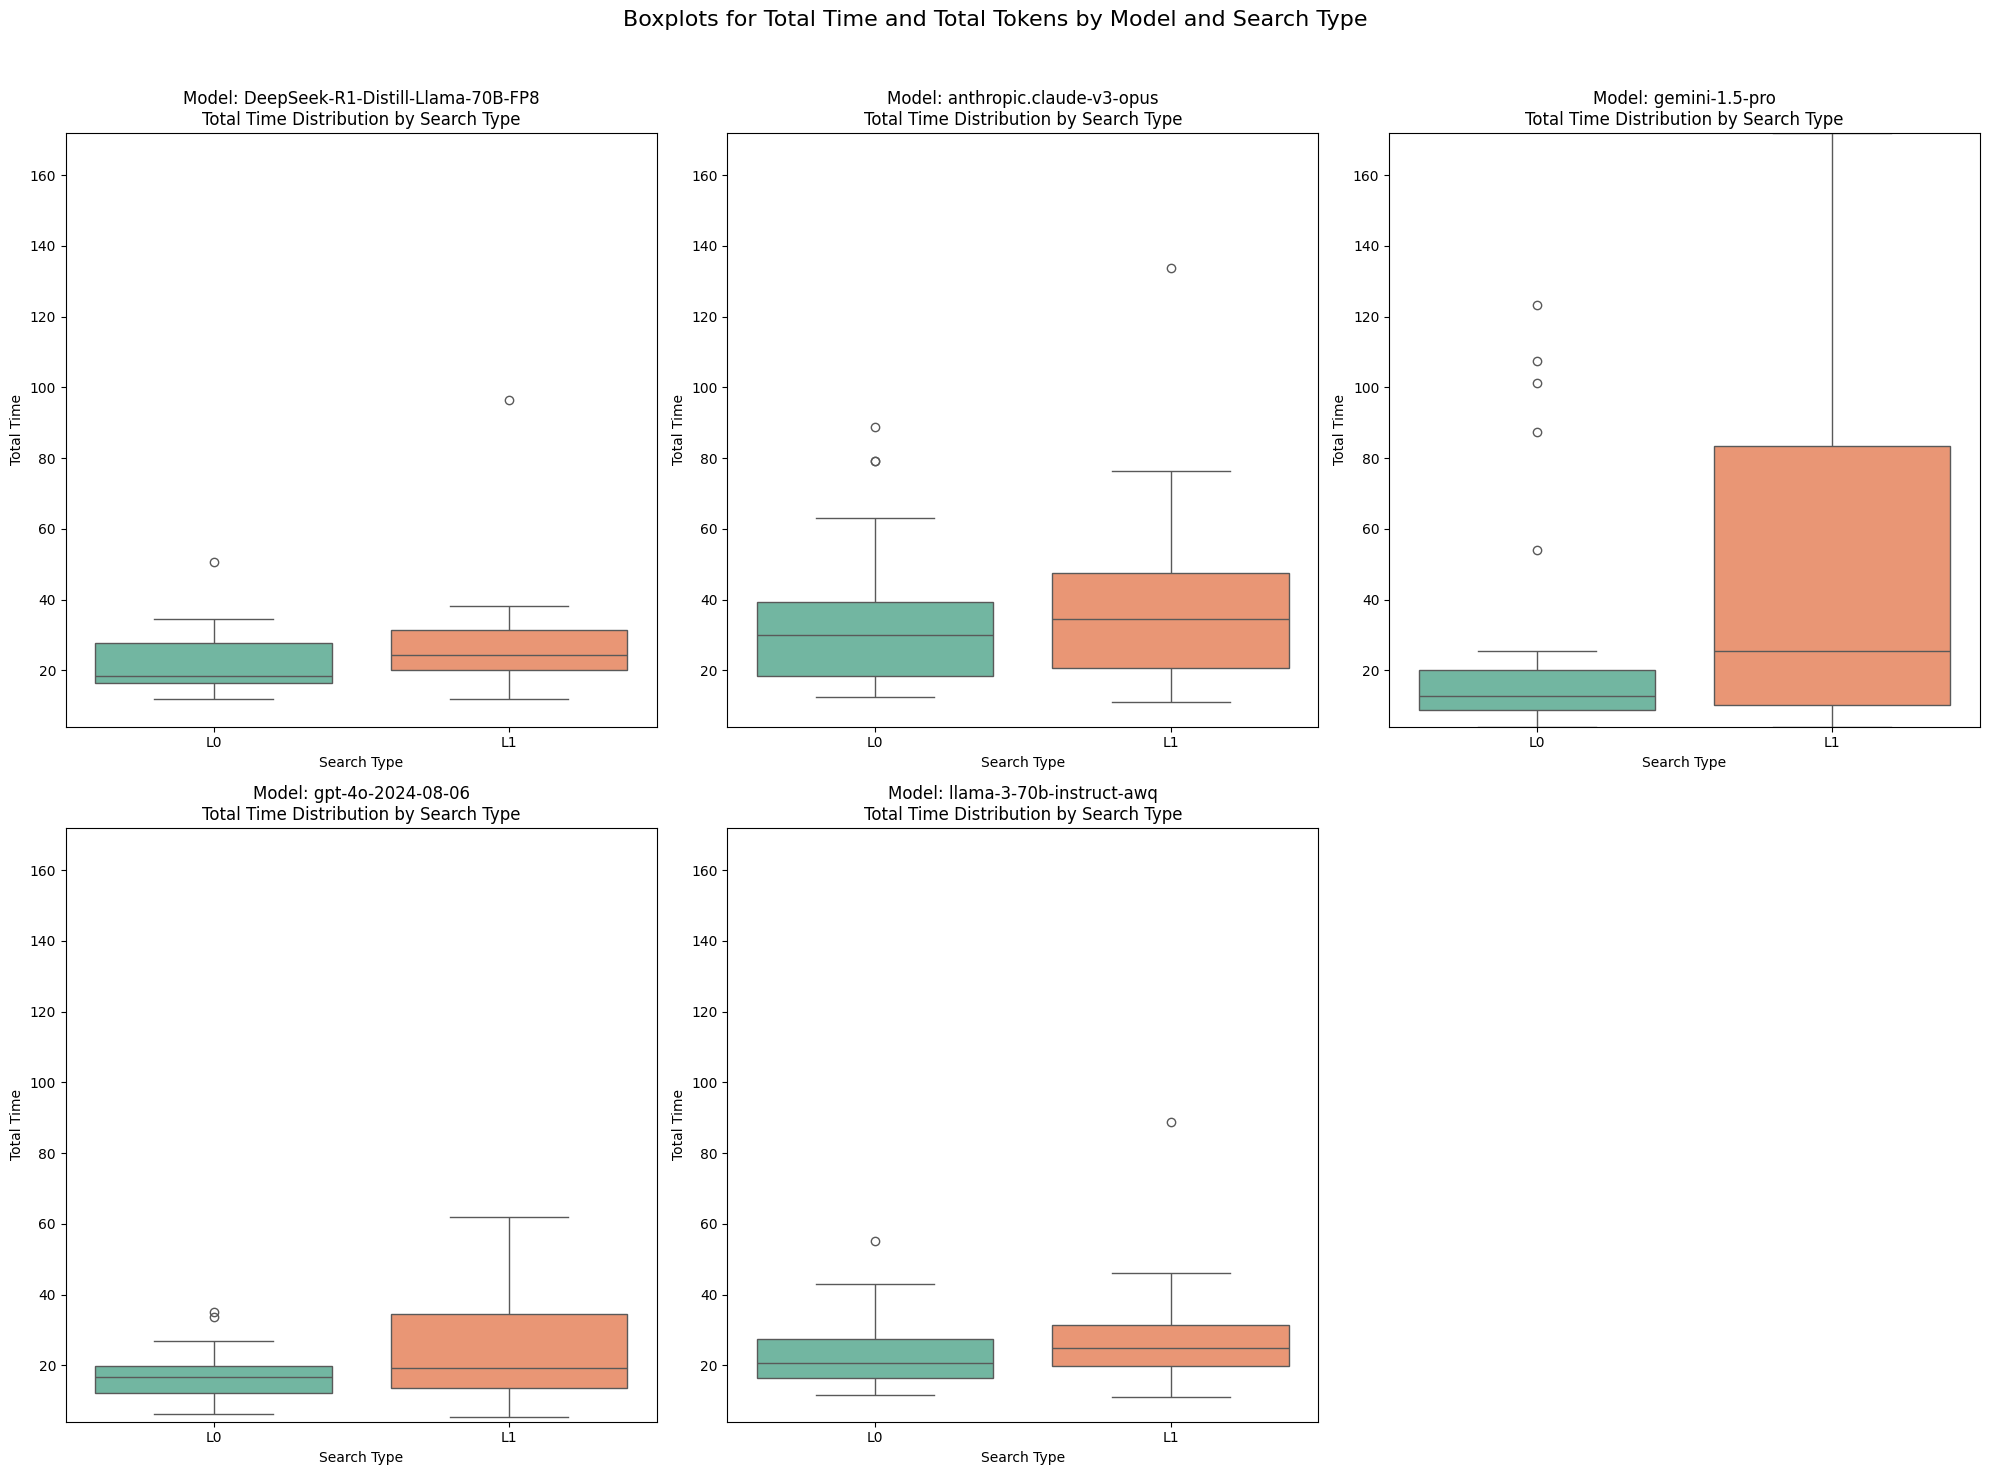

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and it has columns: 'model', 'search_type', 'total_time', 'total_tokens'

# Determine the global y-axis limits for both 'total_time' and 'total_tokens'
global_total_time_min = df['total_time'].min()
global_total_time_max = df['total_time'].max()

global_total_tokens_min = df['total_tokens'].min()
global_total_tokens_max = df['total_tokens'].max()

# List of models
models = [
    'DeepSeek-R1-Distill-Llama-70B-FP8',
    'anthropic.claude-v3-opus',
    'gemini-1.5-pro',
    'gpt-4o-2024-08-06',
    'llama-3-70b-instruct-awq'
]

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle('Boxplots for Total Time and Total Tokens by Model and Search Type', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each model and create the subplots
for i, model in enumerate(models):
    df_model = df[df["model"] == model]
    
    # Box plot for total_time
    sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    axes[i].set_title(f"Model: {model}\nTotal Time Distribution by Search Type")
    axes[i].set_xlabel("Search Type")
    axes[i].set_ylabel("Total Time")
    axes[i].set_ylim(global_total_time_min, global_total_time_max)  # Set the same y-axis scale
    
    # # Box plot for total_tokens
    # sns.boxplot(ax=axes[i+3], data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    # axes[i+3].set_title(f"Model: {model}\nTotal Tokens Distribution by Search Type")
    # axes[i+3].set_xlabel("Search Type")
    # axes[i+3].set_ylabel("Total Tokens")
    # axes[i+3].set_ylim(global_total_tokens_min, global_total_tokens_max)  # Set the same y-axis scale

# Hide the last subplot (since there are 5 models and 6 subplots)
axes[-1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for the suptitle
plt.show()

/tmp/ipykernel_26812/1779946637.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
/tmp/ipykernel_26812/1779946637.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
/tmp/ipykernel_26812/1779946637.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
/tmp/ipykernel_2

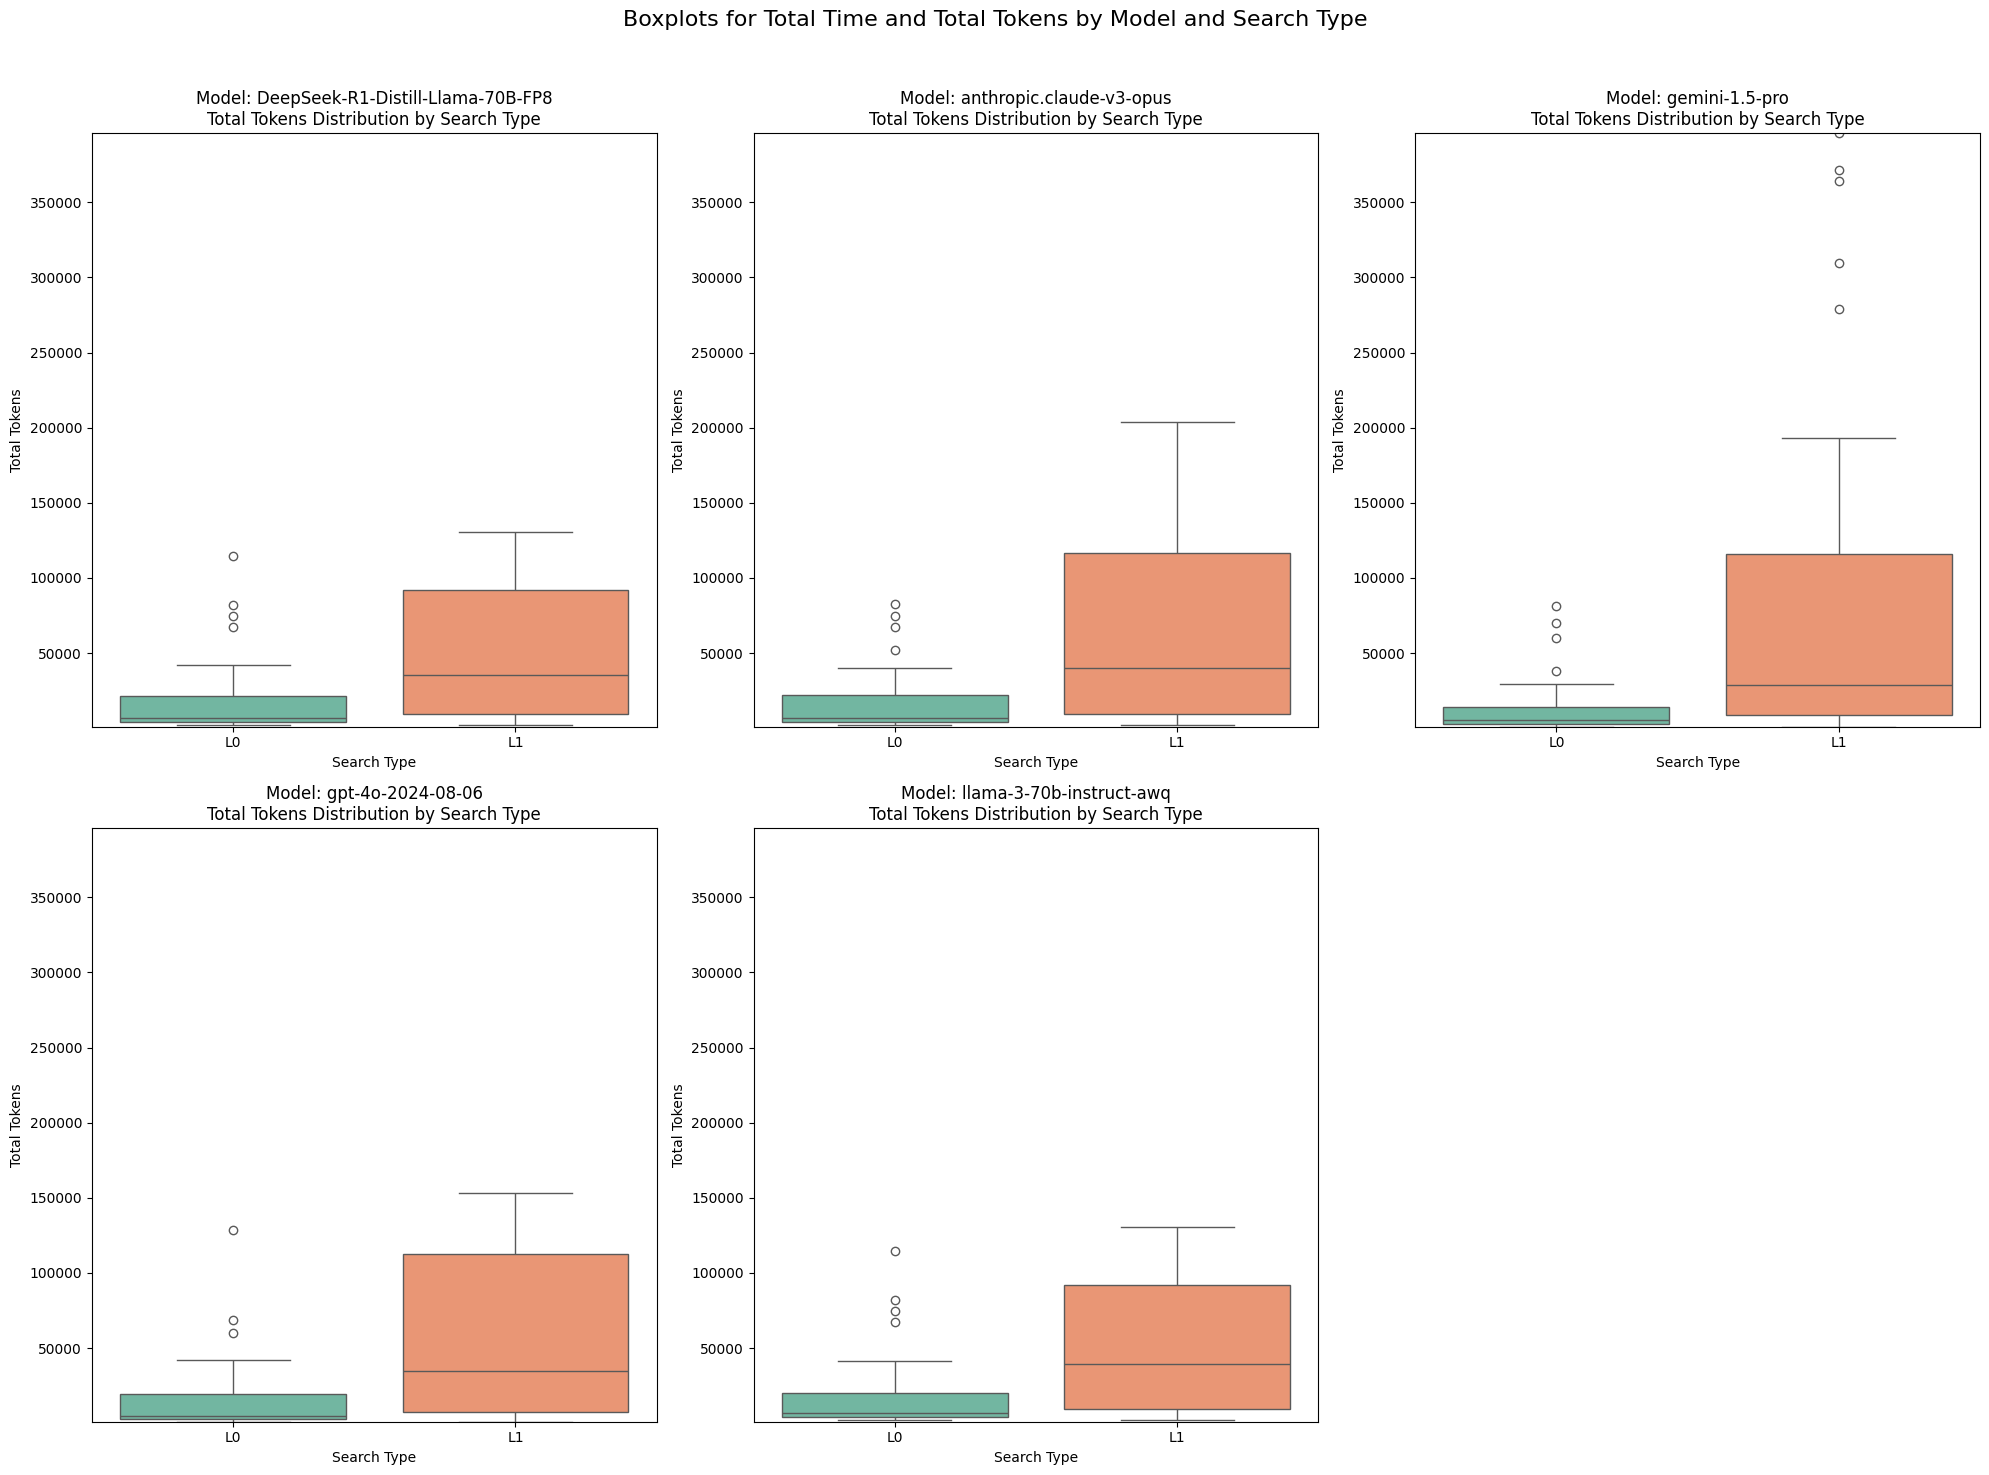

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and it has columns: 'model', 'search_type', 'total_time', 'total_tokens'

# Determine the global y-axis limits for both 'total_time' and 'total_tokens'
global_total_time_min = df['total_time'].min()
global_total_time_max = df['total_time'].max()

global_total_tokens_min = df['total_tokens'].min()
global_total_tokens_max = df['total_tokens'].max()

# List of models
models = [
    'DeepSeek-R1-Distill-Llama-70B-FP8',
    'anthropic.claude-v3-opus',
    'gemini-1.5-pro',
    'gpt-4o-2024-08-06',
    'llama-3-70b-instruct-awq'
]

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle('Boxplots for Total Time and Total Tokens by Model and Search Type', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each model and create the subplots
for i, model in enumerate(models):
    df_model = df[df["model"] == model]
    
    # # Box plot for total_time
    # sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    # axes[i].set_title(f"Model: {model}\nTotal Time Distribution by Search Type")
    # axes[i].set_xlabel("Search Type")
    # axes[i].set_ylabel("Total Time")
    # axes[i].set_ylim(global_total_time_min, global_total_time_max)  # Set the same y-axis scale
    
    # Box plot for total_tokens
    sns.boxplot(ax=axes[i], data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    axes[i].set_title(f"Model: {model}\nTotal Tokens Distribution by Search Type")
    axes[i].set_xlabel("Search Type")
    axes[i].set_ylabel("Total Tokens")
    axes[i].set_ylim(global_total_tokens_min, global_total_tokens_max)  # Set the same y-axis scale

# Hide the last subplot (since there are 5 models and 6 subplots)
axes[-1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for the suptitle
plt.show()

/tmp/ipykernel_26812/122756833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df, x="search_type", y="total_time", palette="coolwarm")
/tmp/ipykernel_26812/122756833.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(data=df, x="search_type", y="total_tokens", palette="coolwarm")


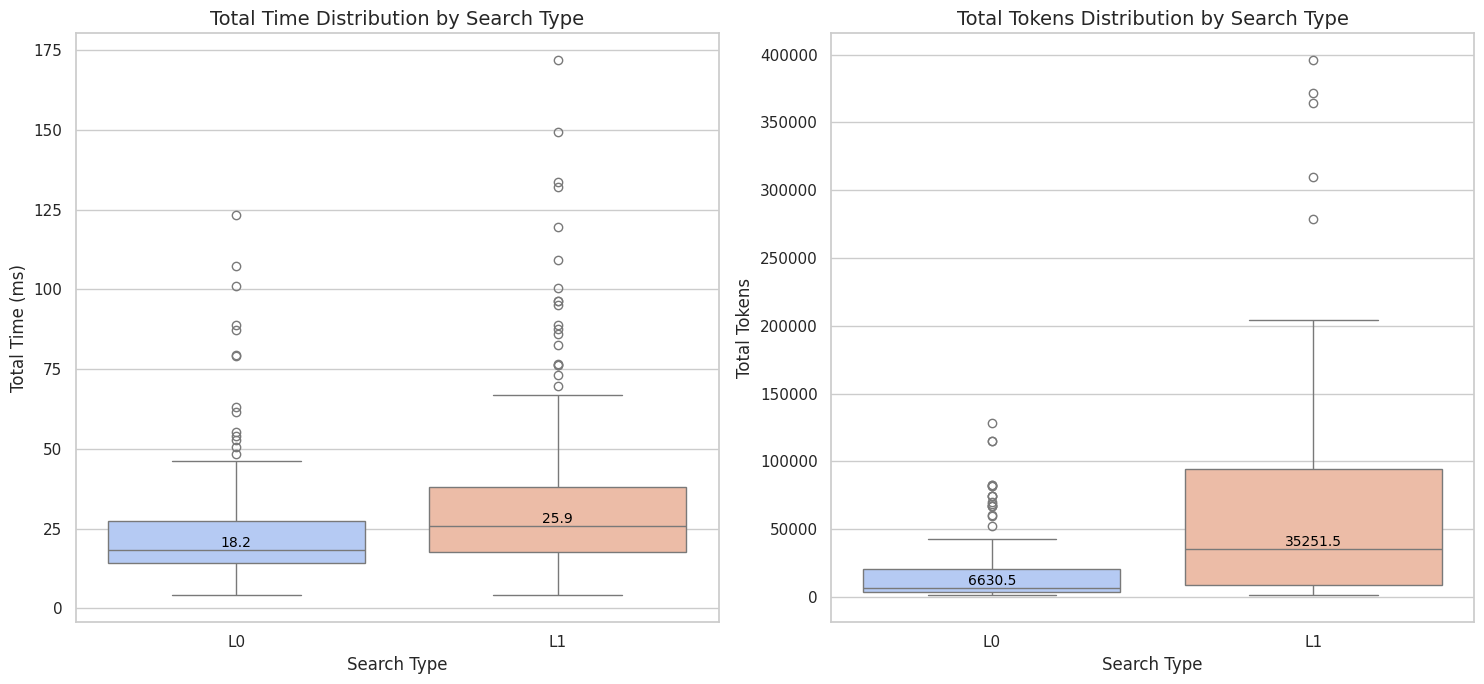

In [43]:
# Set general style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(15, 7))

# Box plot for total_time
plt.subplot(1, 2, 1)
ax1 = sns.boxplot(data=df, x="search_type", y="total_time", palette="coolwarm")
plt.title("Total Time Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Time (ms)", fontsize=12)

# Add median value annotations
medians_time = df.groupby("search_type")["total_time"].median().reset_index()
for idx, row in medians_time.iterrows():
    plt.text(
        x=idx,
        y=row["total_time"],
        s=f"{row['total_time']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Box plot for total_tokens
plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x="search_type", y="total_tokens", palette="coolwarm")
plt.title("Total Tokens Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Tokens", fontsize=12)

# Add median value annotations
medians_tokens = df.groupby("search_type")["total_tokens"].median().reset_index()
for idx, row in medians_tokens.iterrows():
    plt.text(
        x=idx,
        y=row["total_tokens"],
        s=f"{row['total_tokens']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [44]:
dict_map = {
    "lexical_search_0_hop": "L0",
    "lexical_search_1_hop": "L1",
    "lexical_search_2_hop": "S2",
    "similarity_search_0_hop": "S0",
    "similarity_search_1_hop": "S1",
}
df = df.replace({"search_type": dict_map})

In [45]:
df.head()

,true_consumer_id,model,search_type,question,total_time,total_tokens
806,Allen322_Ferry570_ad134528,DeepSeek-R1-Distill-Llama-70B-FP8,L0,Q4,29.602163,41956
309,Edythe31_Morar593_9c3df38a,gemini-1.5-pro,L0,Q7,21.233796,6302
310,Edythe31_Morar593_9c3df38a,gemini-1.5-pro,L0,Q4,5.478961,18019
311,Edythe31_Morar593_9c3df38a,gemini-1.5-pro,L0,Q1,14.992993,3206
645,Beatris270_Bogan287_5b3645de,anthropic.claude-v3-opus,L0,Q8,46.246804,8319


In [46]:
set(df["model"].unique())

{'DeepSeek-R1-Distill-Llama-70B-FP8',
 'anthropic.claude-v3-opus',
 'gemini-1.5-pro',
 'gpt-4o-2024-08-06',
 'llama-3-70b-instruct-awq'}

/tmp/ipykernel_26812/3283576253.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", showfliers=True)


IndexError: index 2 is out of bounds for axis 0 with size 2

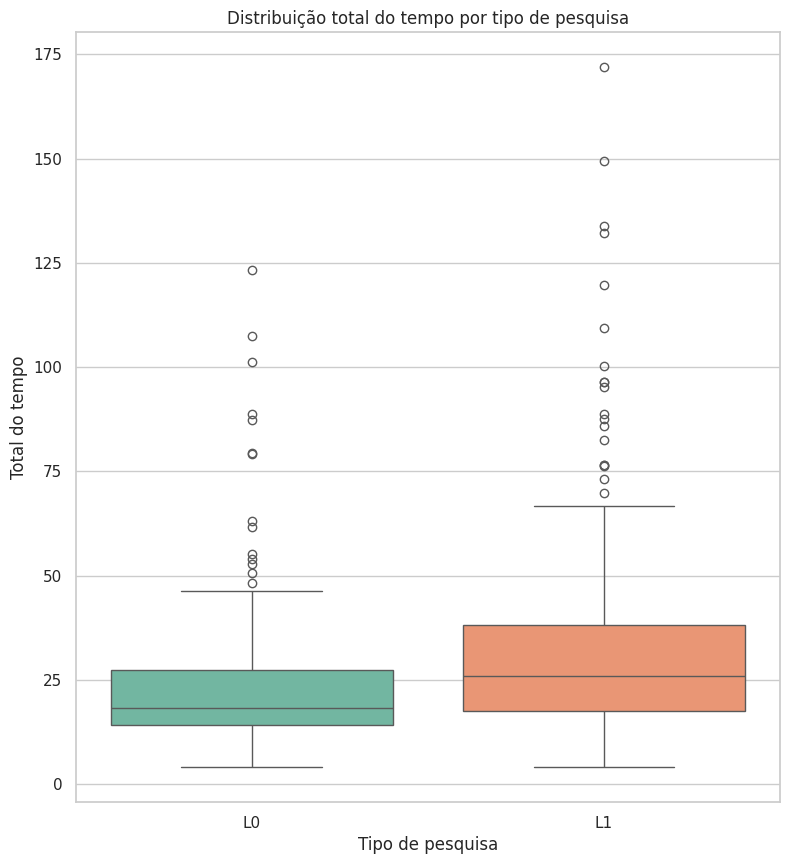

In [47]:
# Adjust the figure size for better layout
plt.figure(figsize=(20, 10))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", showfliers=True)
plt.title("Distribuição total do tempo por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total do tempo")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_time"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", showfliers=True)
plt.title("Distribuição total de tokens por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total de tokens")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_tokens"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# plt.tight_layout()
plt.show()

## By question

Boxplots for question:  Q8


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


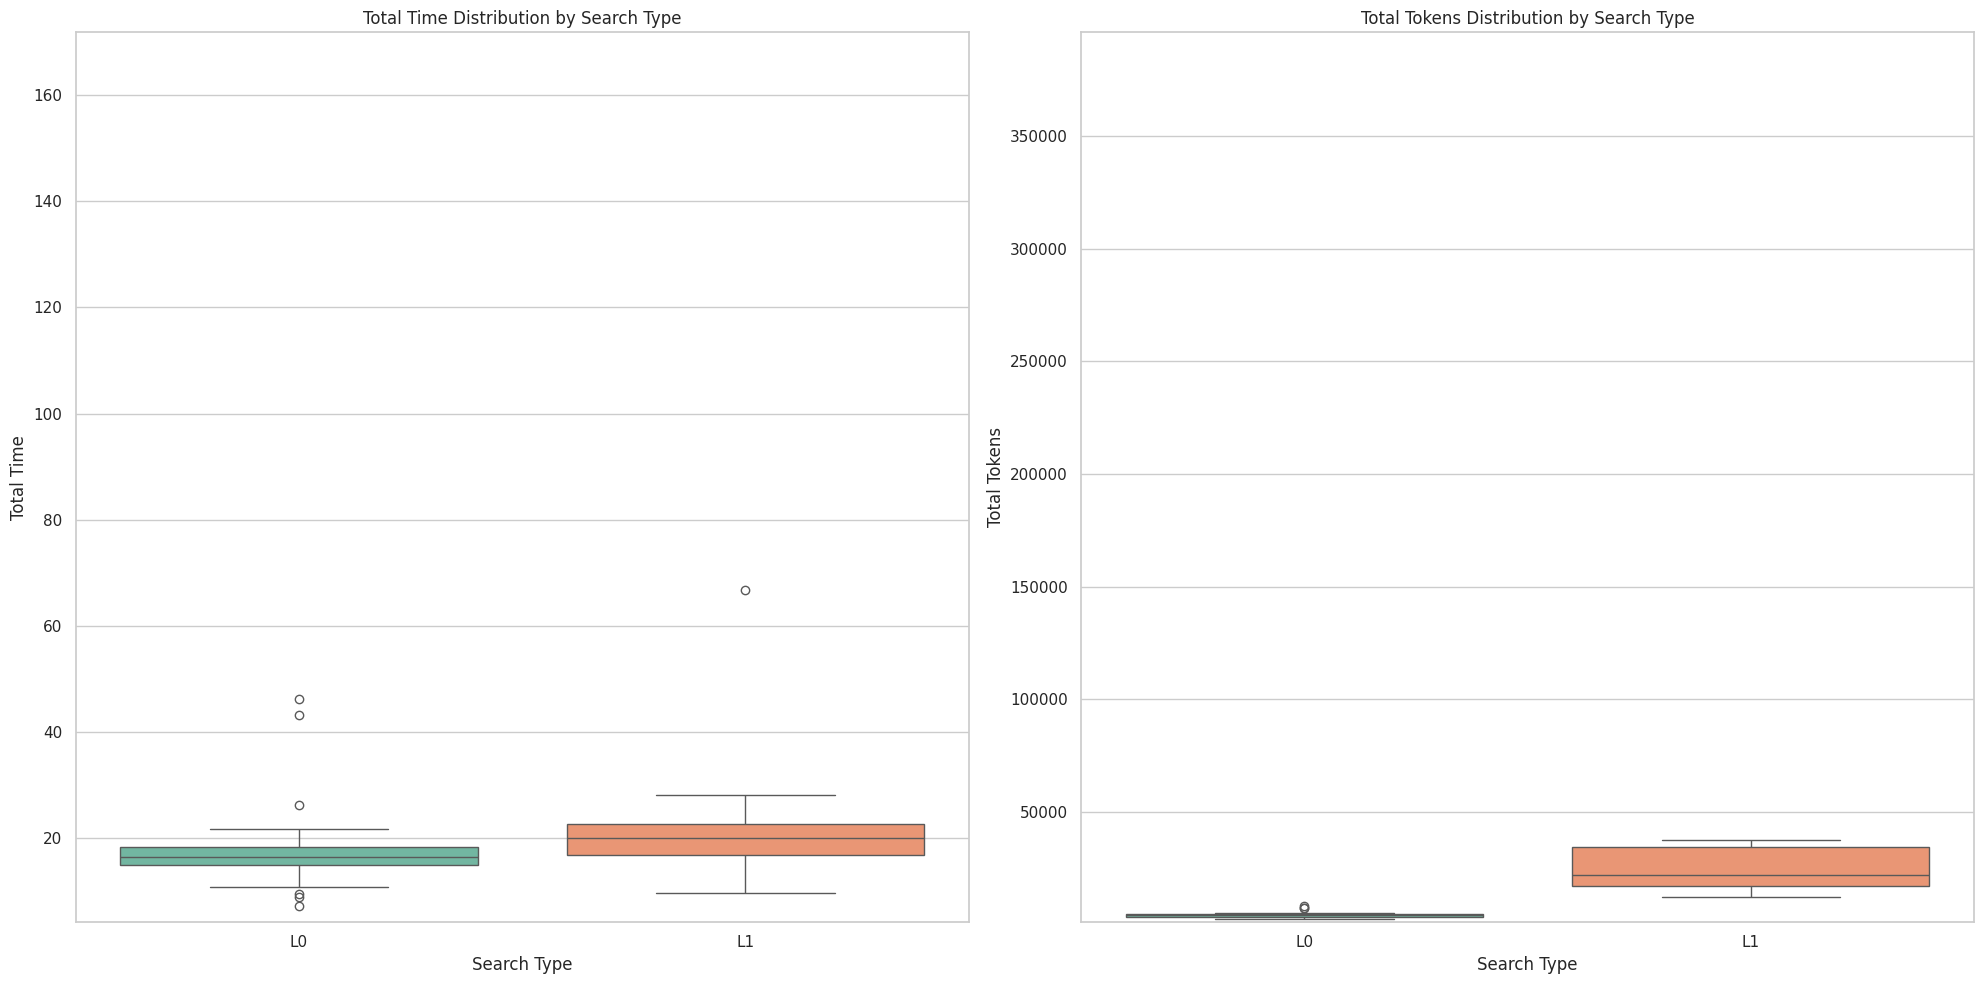

Boxplots for question:  Q2


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


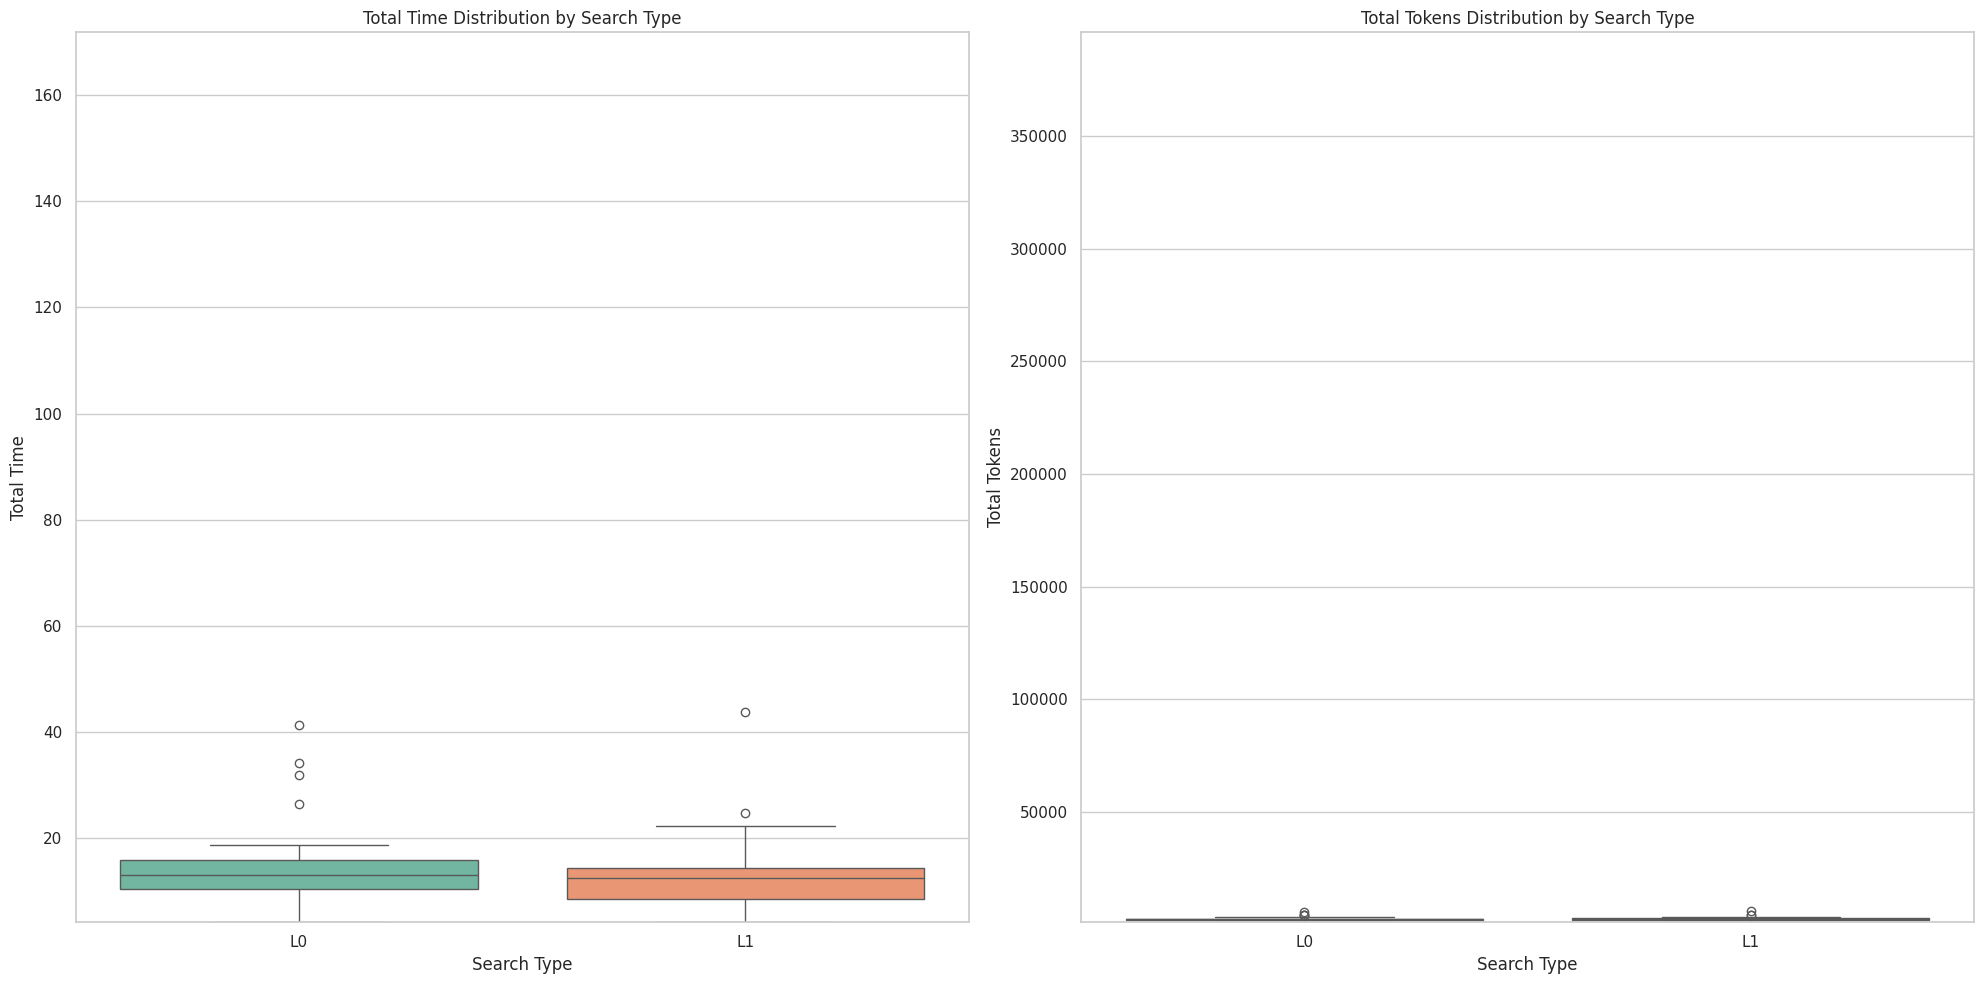

Boxplots for question:  Q4


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


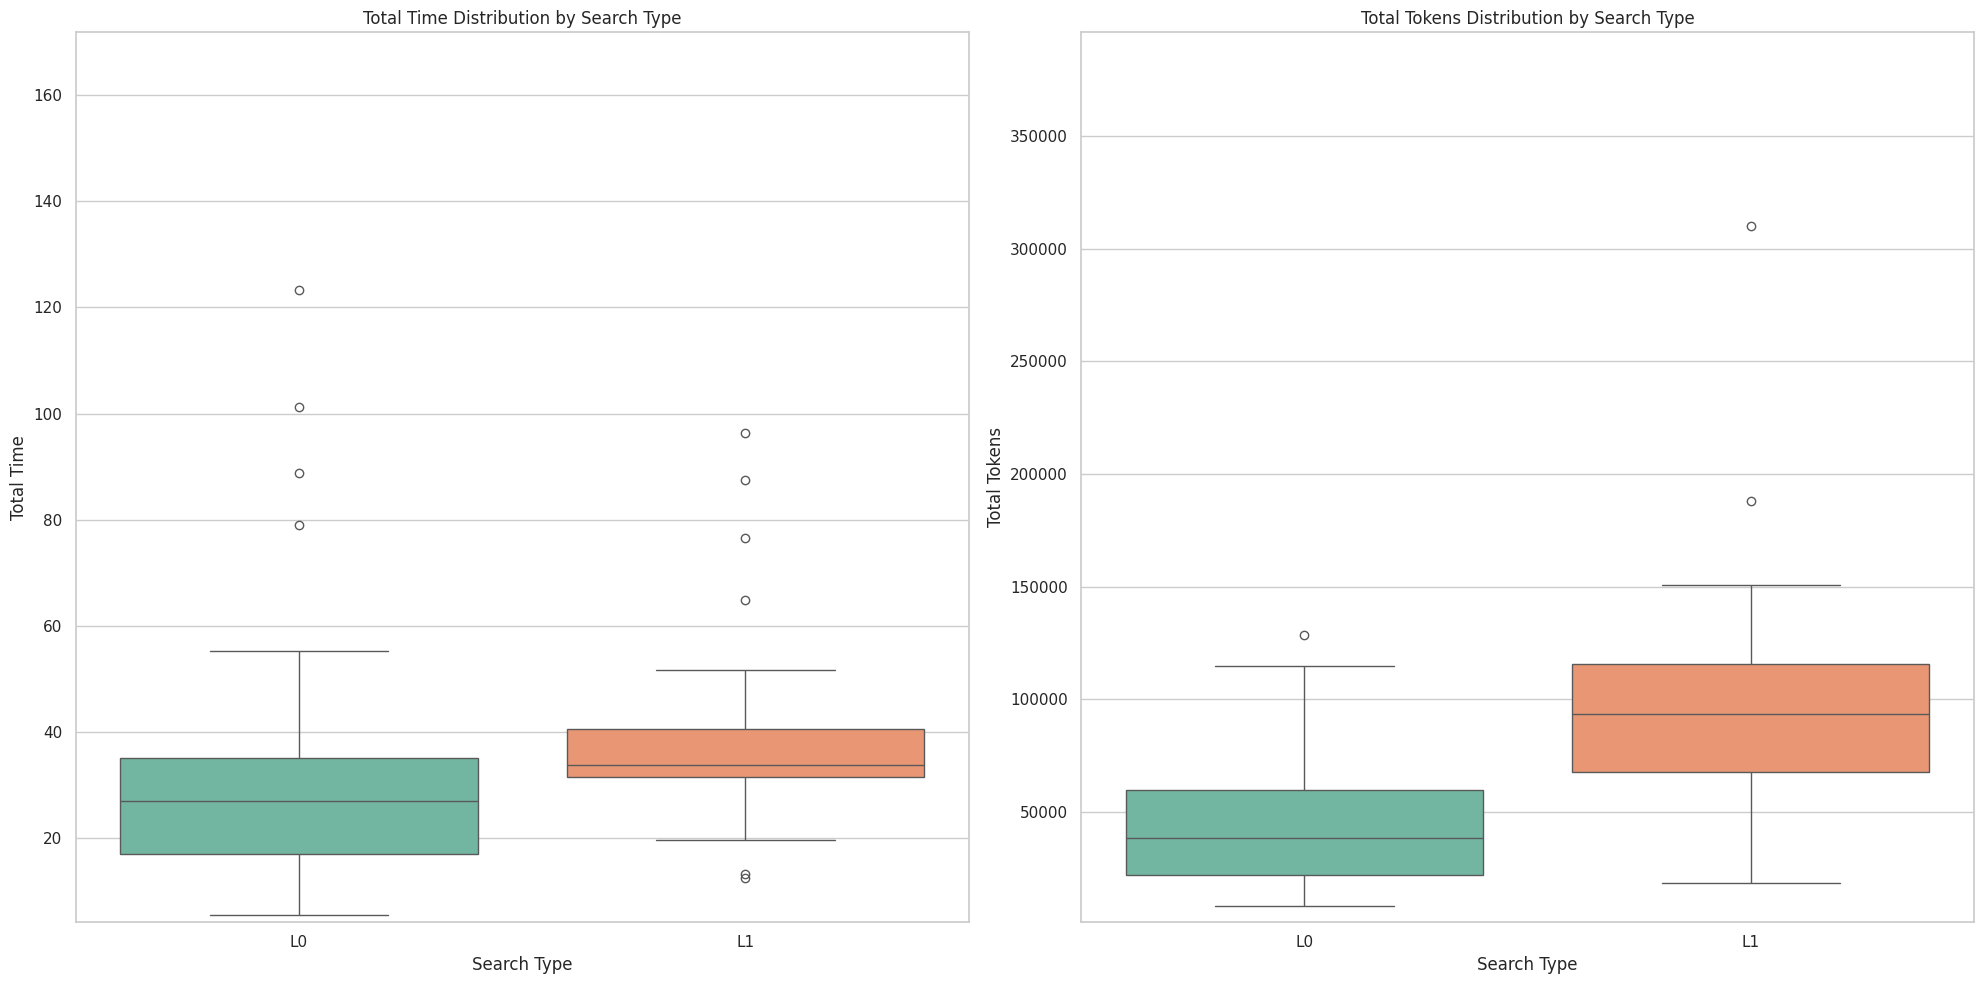

Boxplots for question:  Q5


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


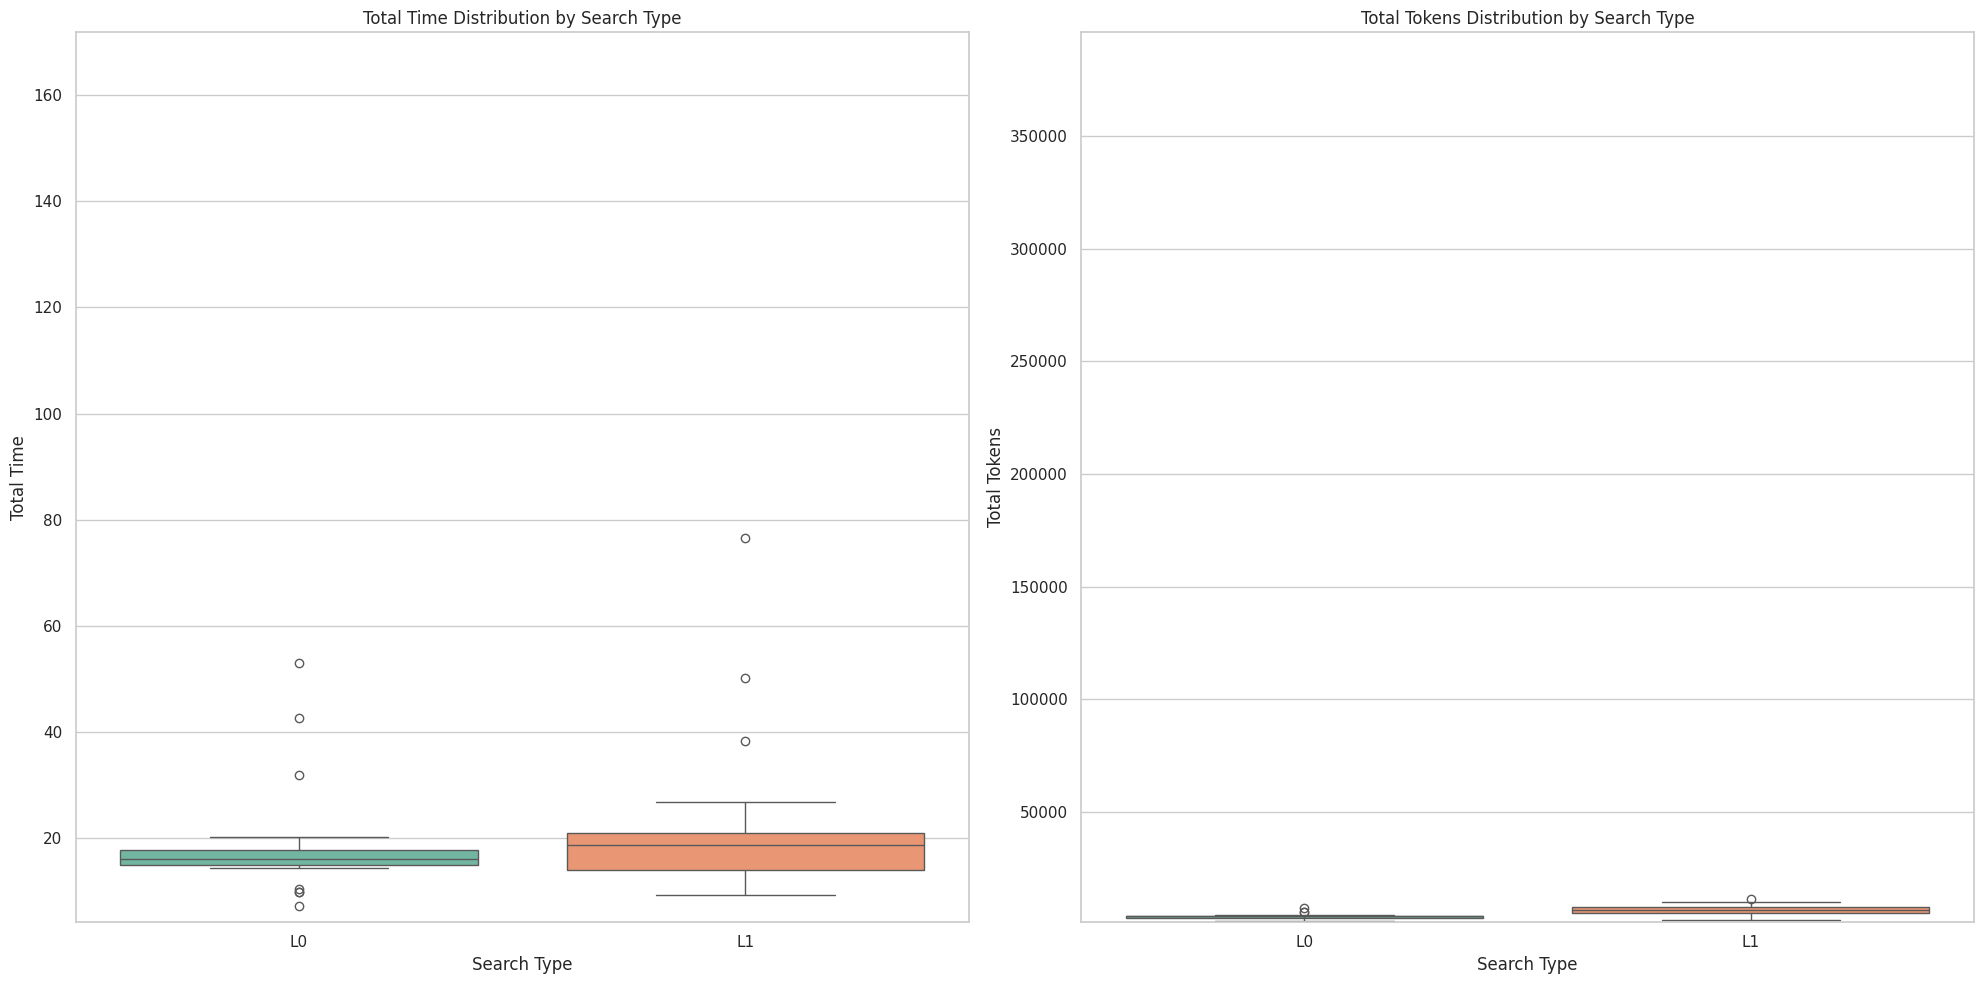

Boxplots for question:  Q7


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


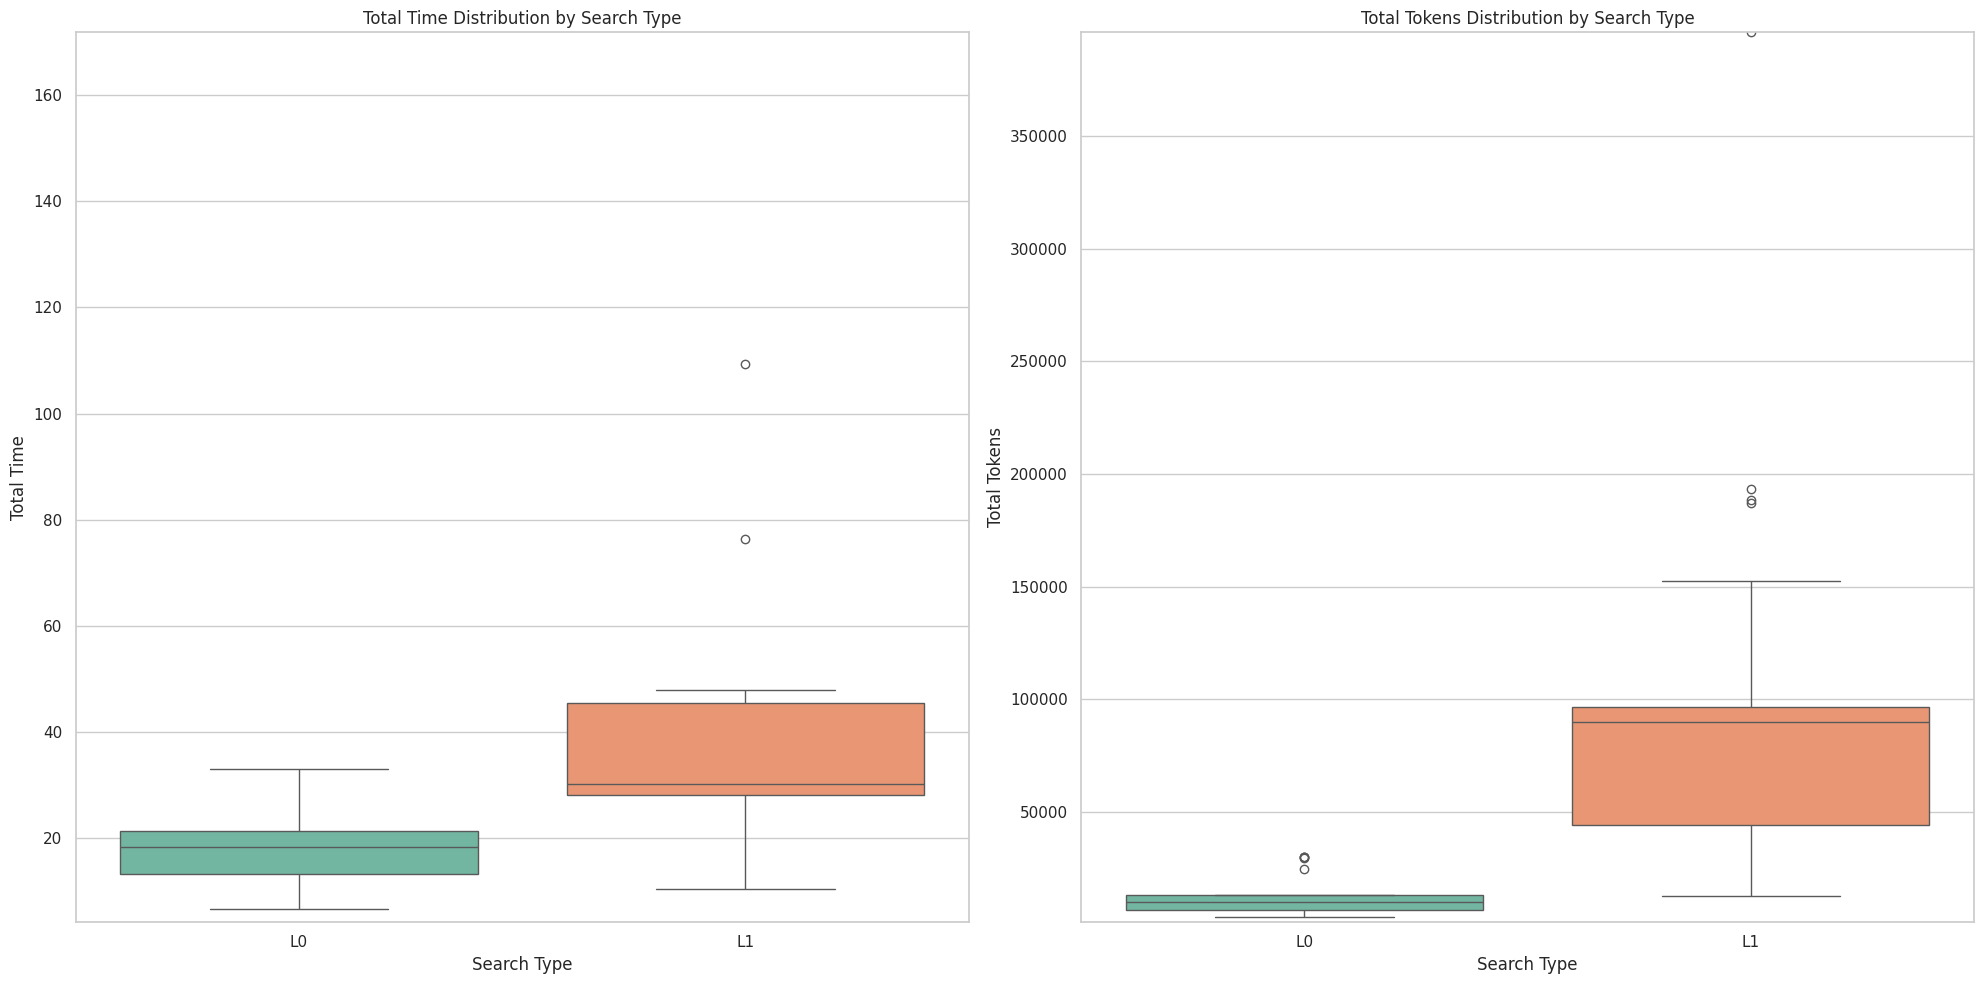

Boxplots for question:  Q6


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


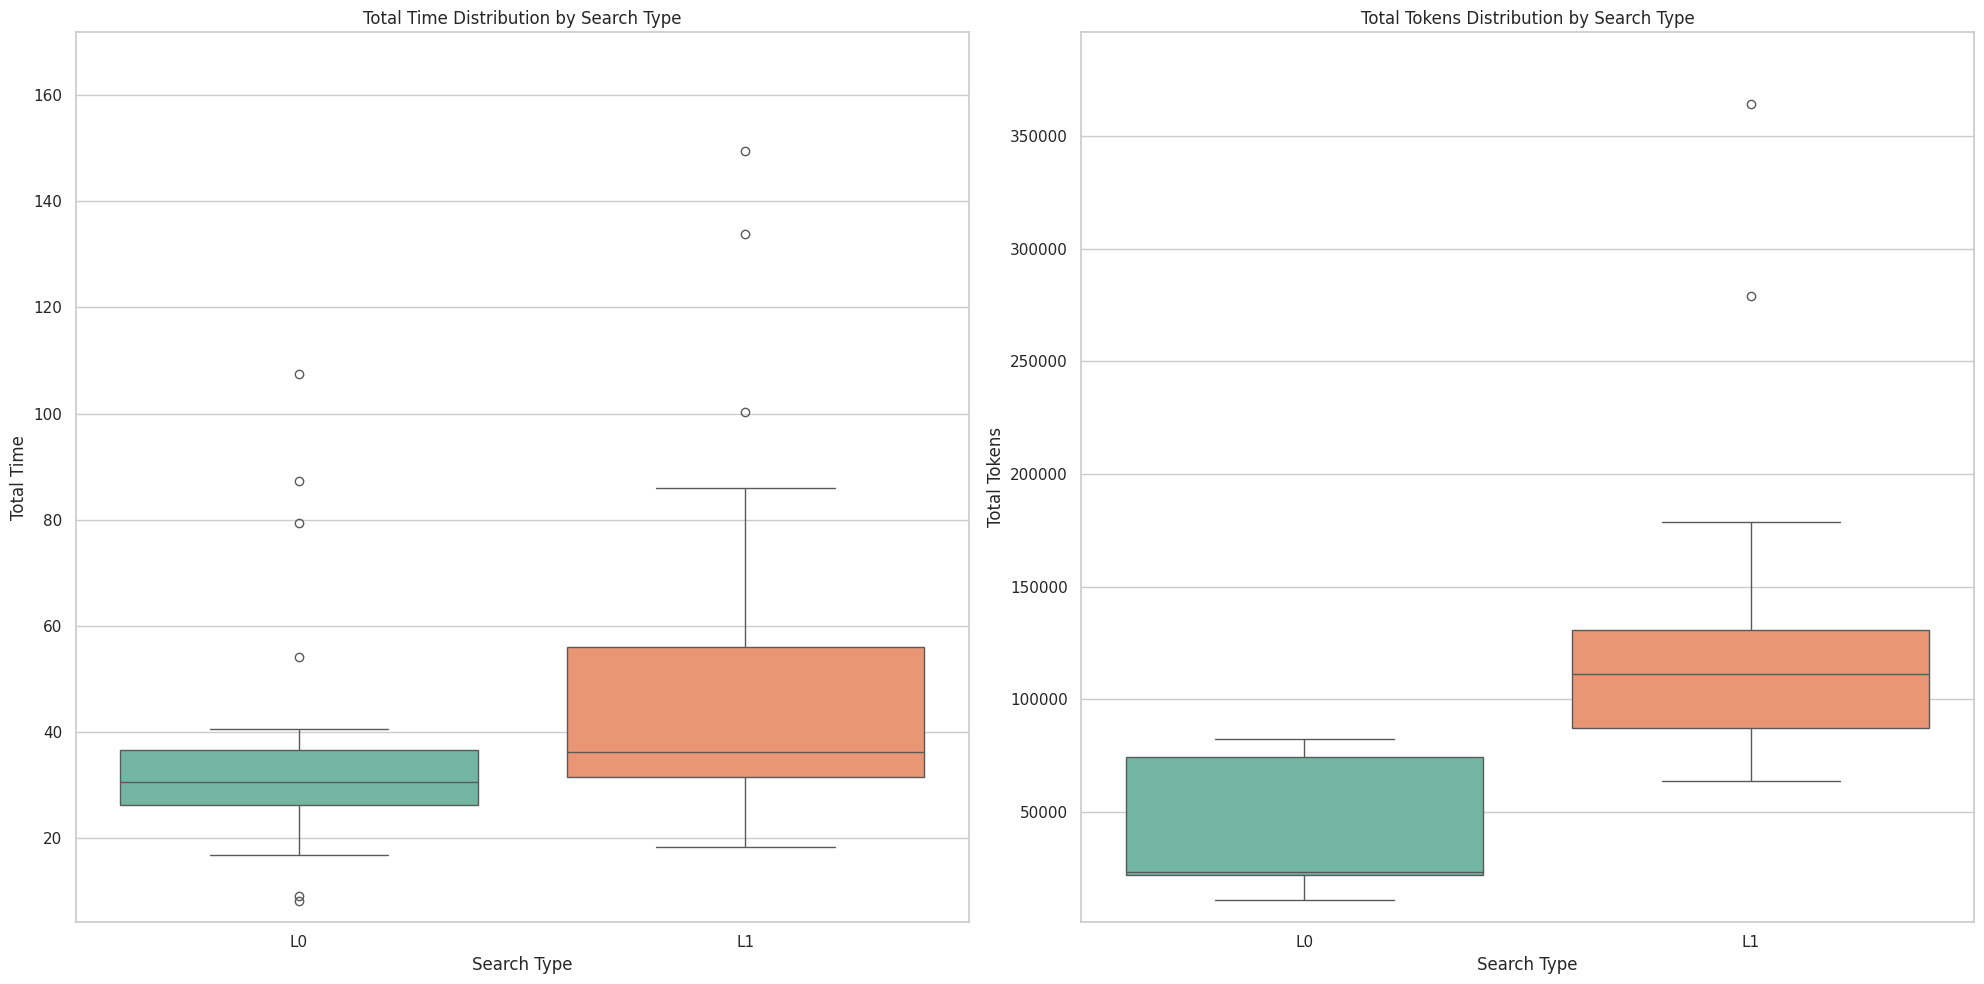

Boxplots for question:  Q1


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


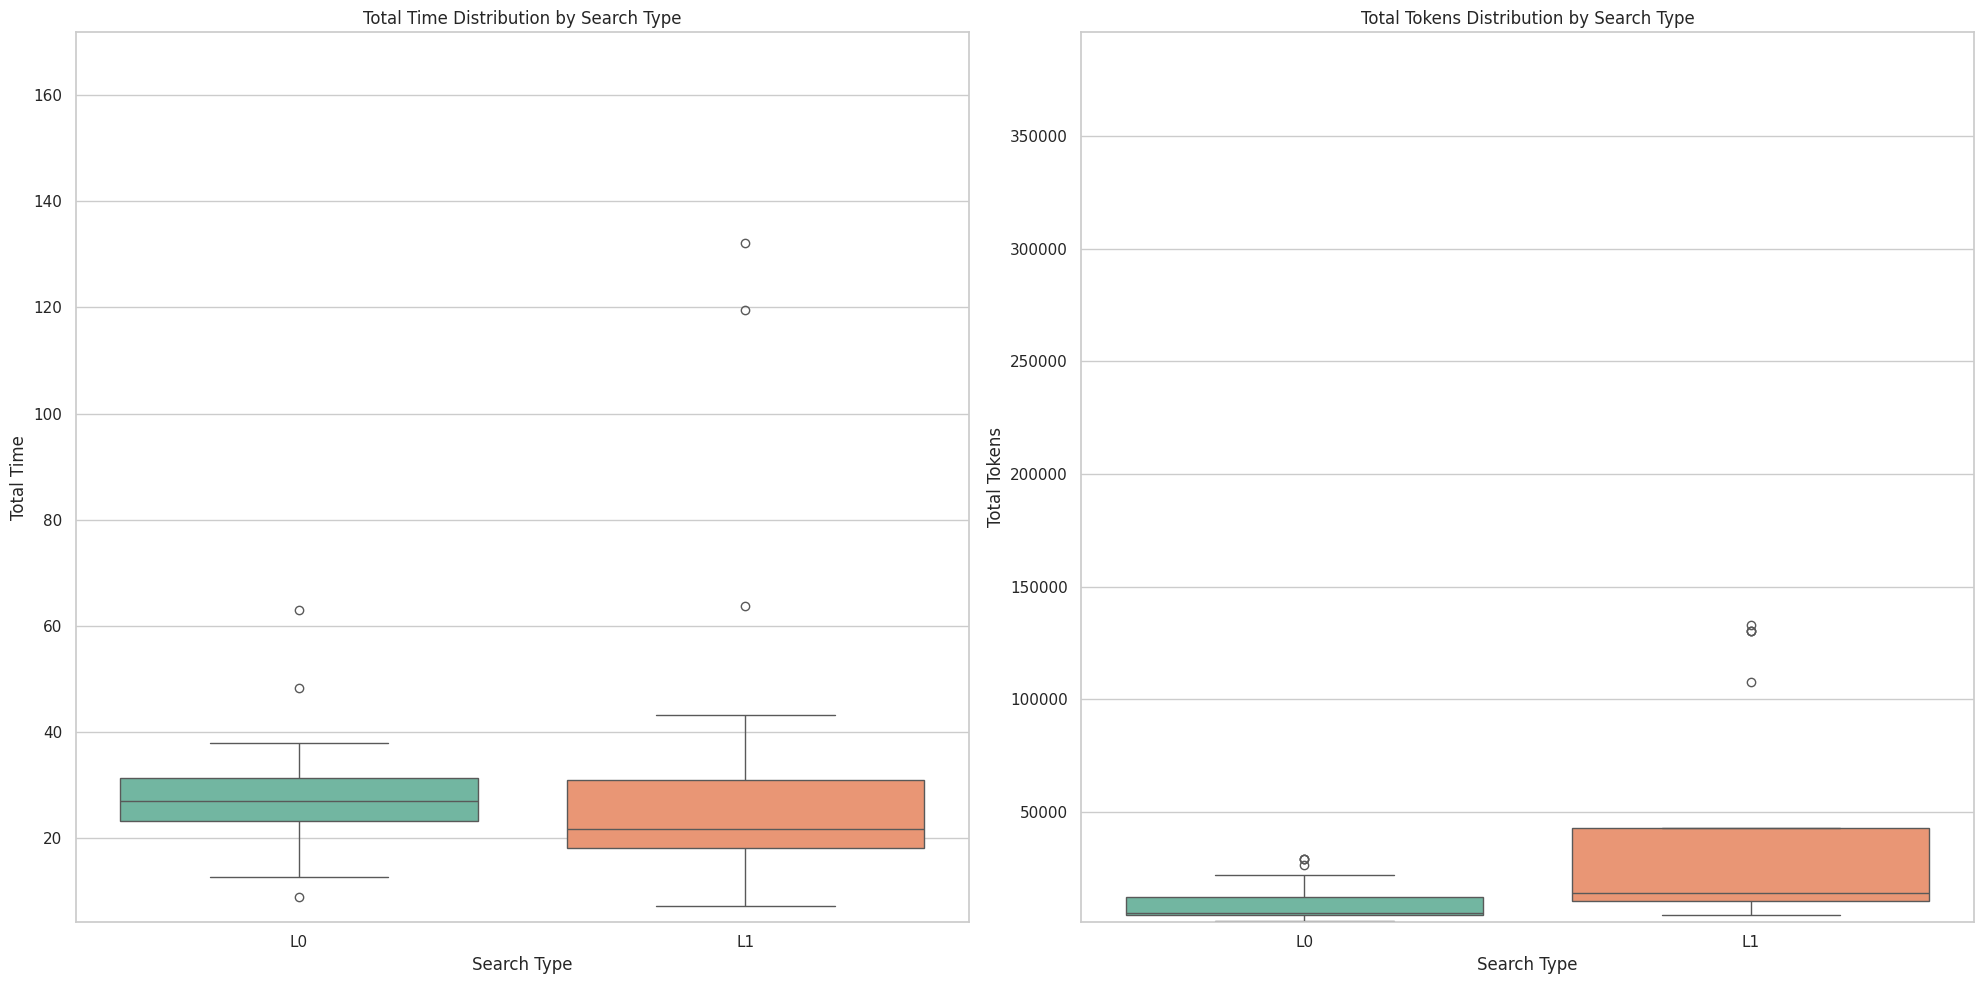

Boxplots for question:  Q3


/tmp/ipykernel_26812/1578685134.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/1578685134.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


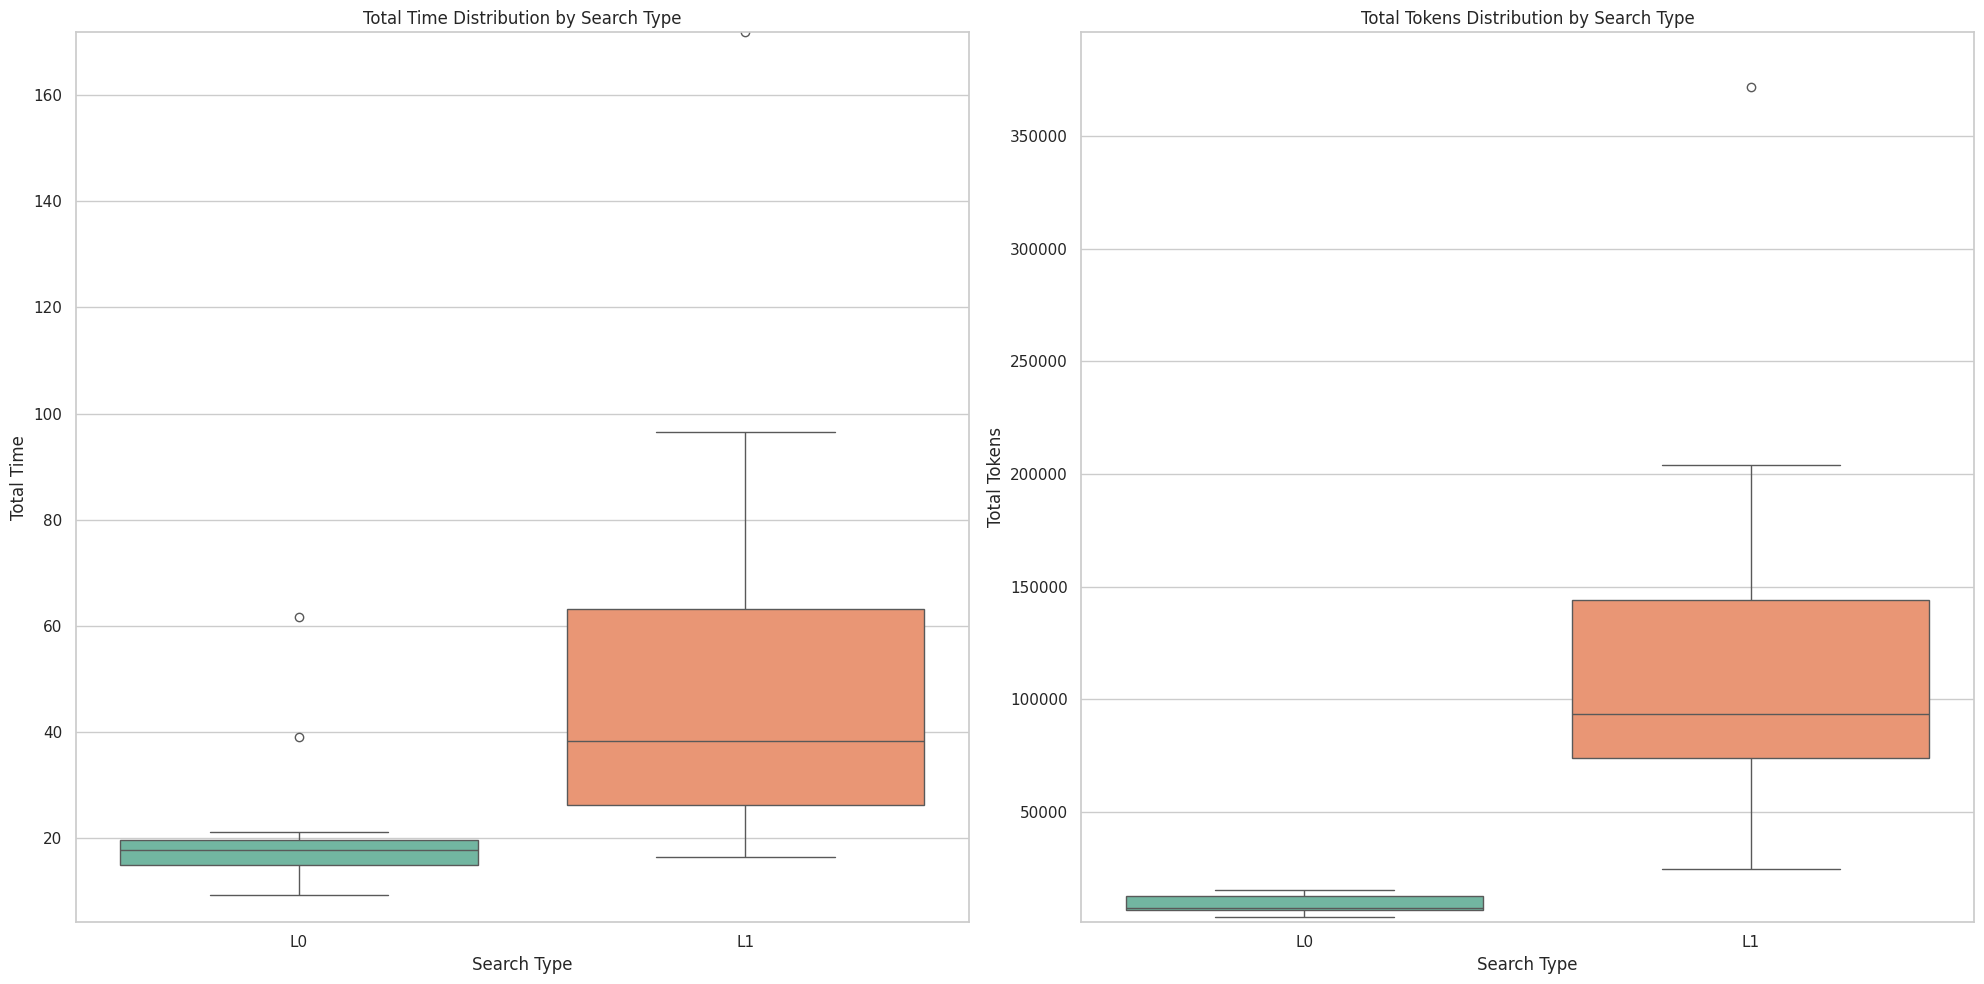

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and it has columns: 'model', 'search_type', 'total_time', 'total_tokens'

# Determine the global y-axis limits for both 'total_time' and 'total_tokens'
global_total_time_min = df['total_time'].min()
global_total_time_max = df['total_time'].max()

global_total_tokens_min = df['total_tokens'].min()
global_total_tokens_max = df['total_tokens'].max()

for question in set(df["question"].unique()):
    print("Boxplots for question: ", question)
    df_model = df[df["question"] == question]
    plt.figure(figsize=(20, 10))
    
    # Box plot for total_time
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    plt.title("Total Time Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Time")
    plt.ylim(global_total_time_min, global_total_time_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    # Box plot for total_tokens
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    plt.title("Total Tokens Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Tokens")
    plt.ylim(global_total_tokens_min, global_total_tokens_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    plt.show()

## By user

Boxplots for question:  Jacklyn830_Veum823_e0e1f21a


/tmp/ipykernel_26812/2556792544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2556792544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


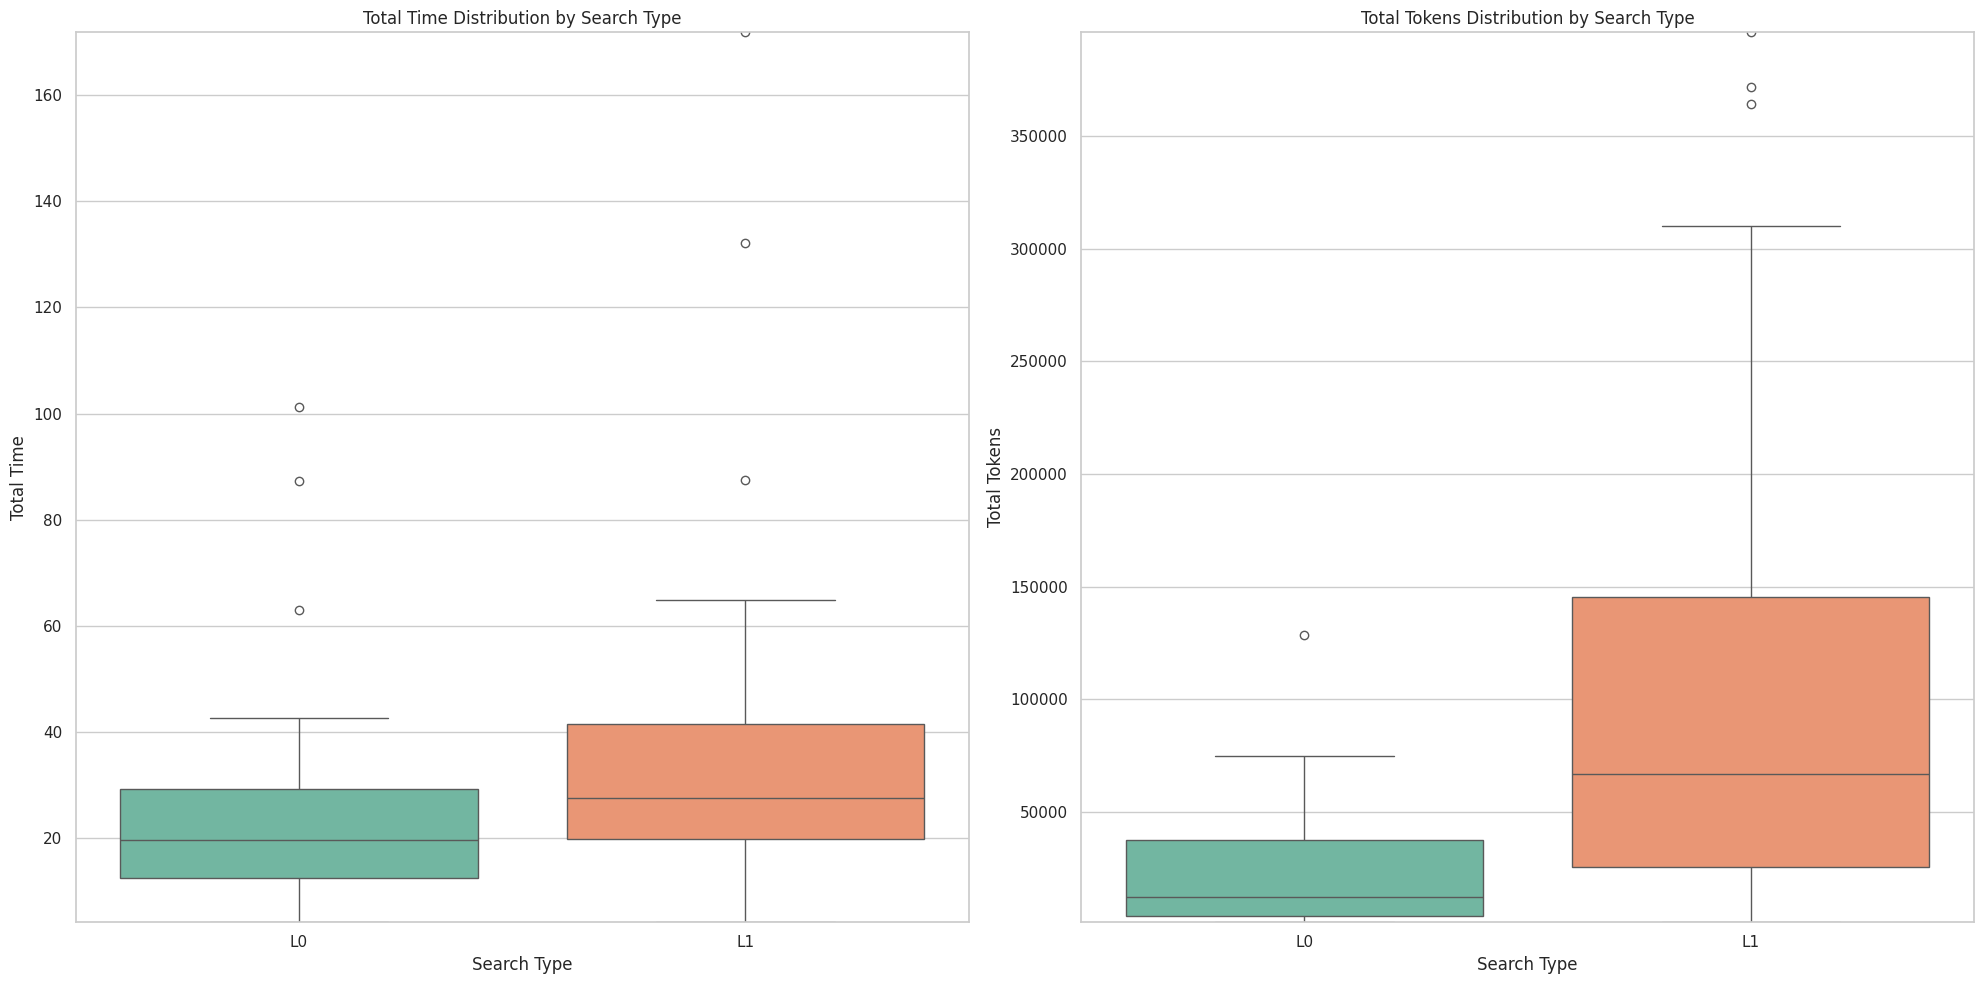

Boxplots for question:  Allen322_Ferry570_ad134528


/tmp/ipykernel_26812/2556792544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2556792544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


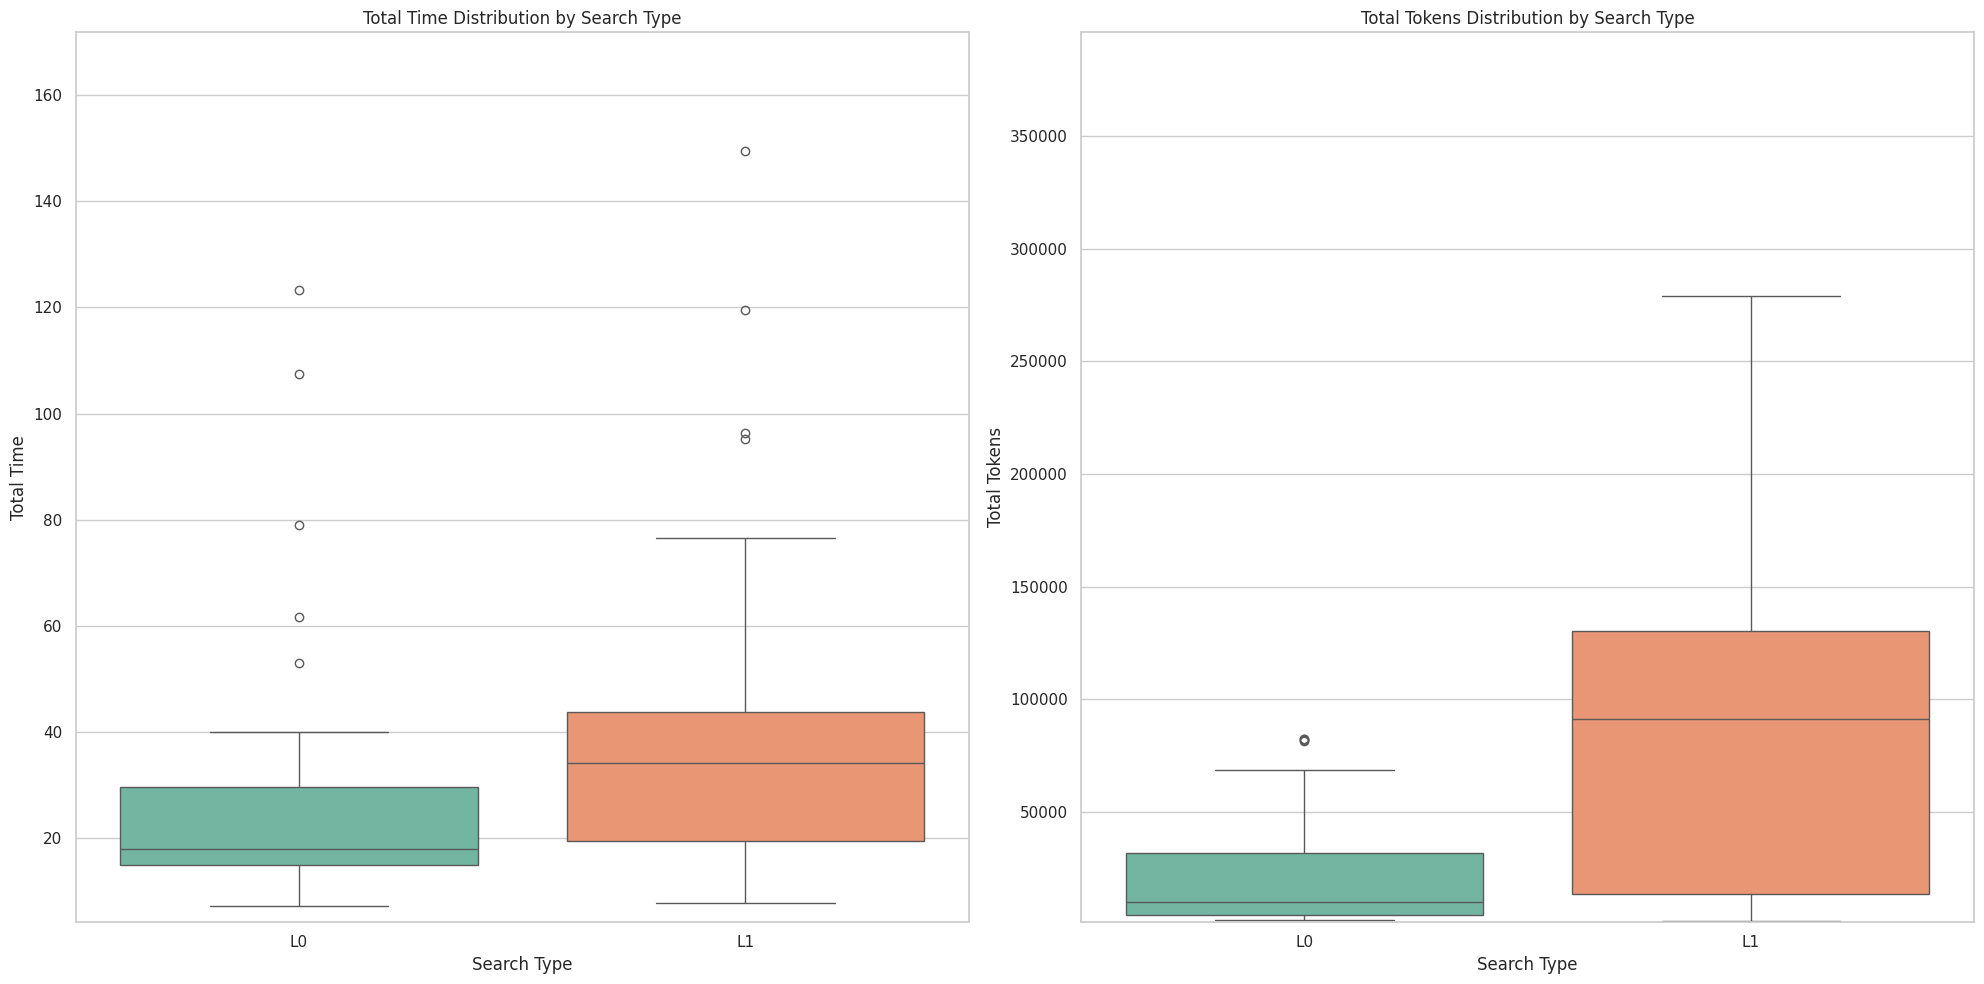

Boxplots for question:  Milton509_Ortiz186_d66b5418


/tmp/ipykernel_26812/2556792544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2556792544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


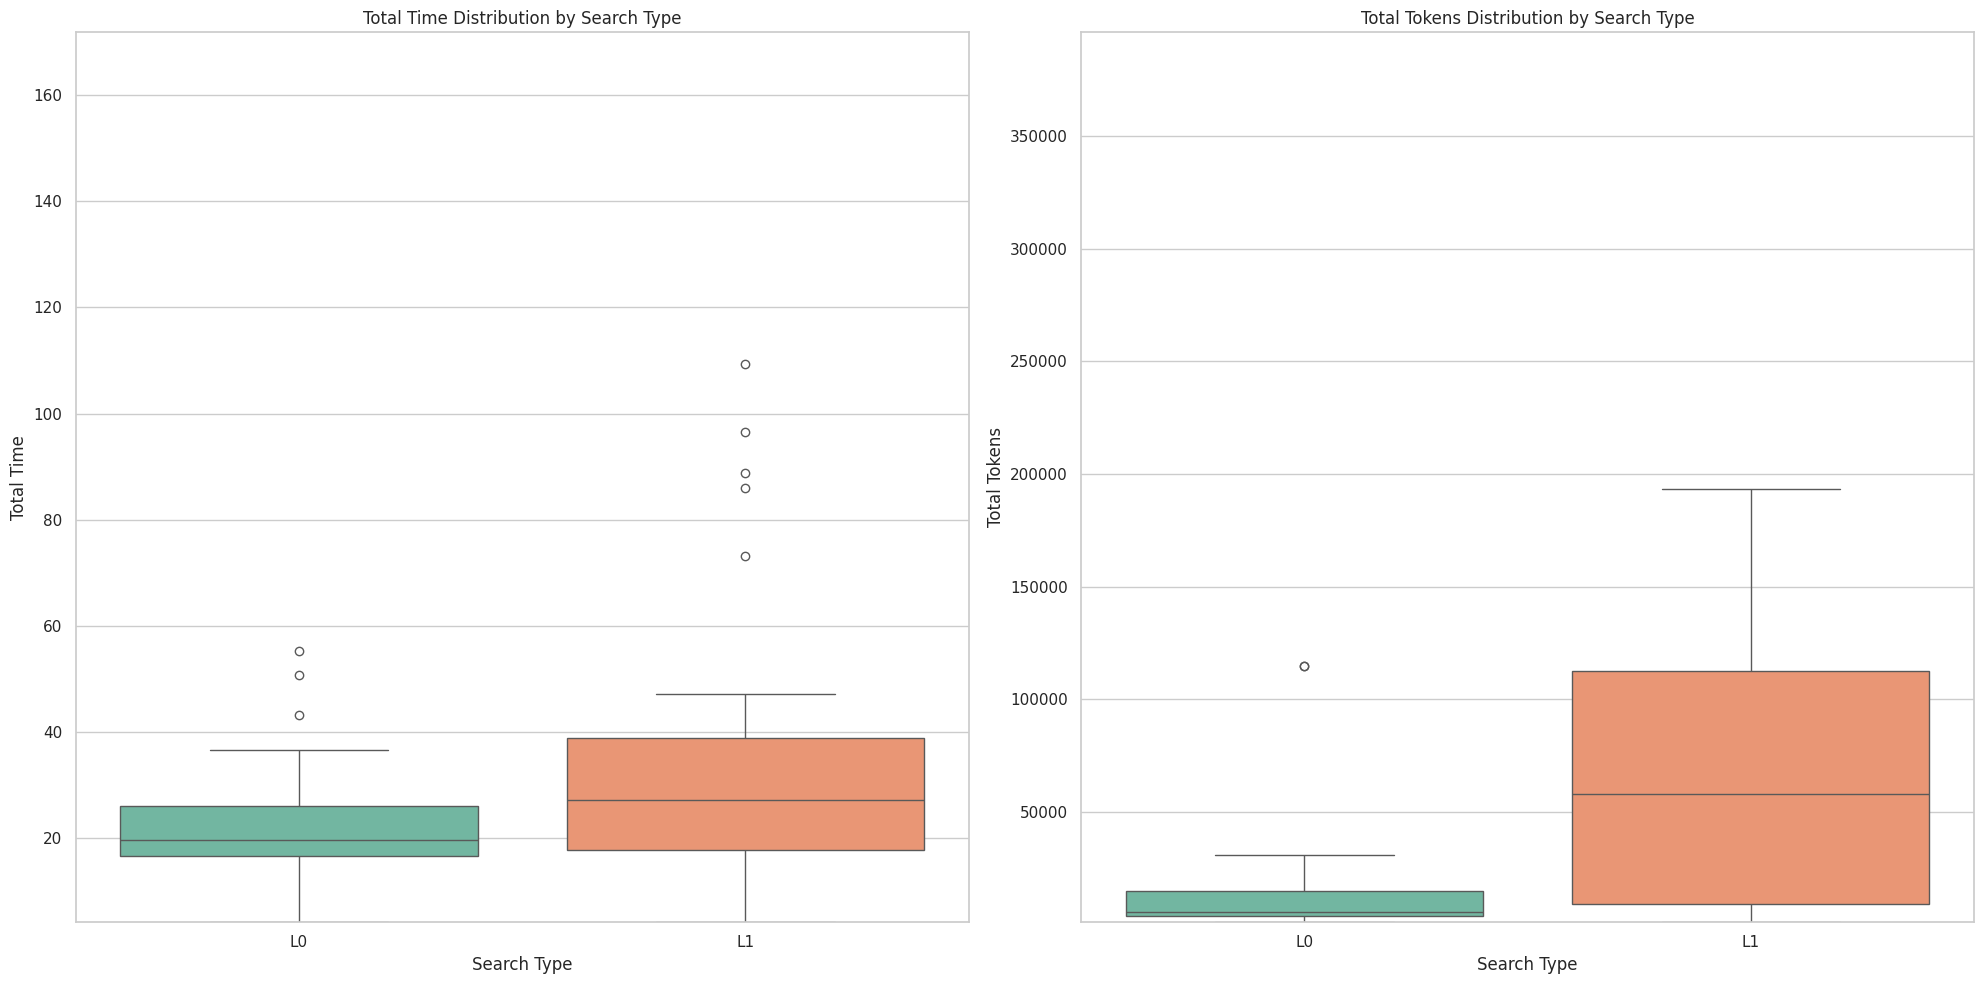

Boxplots for question:  Beatris270_Bogan287_5b3645de


/tmp/ipykernel_26812/2556792544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2556792544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


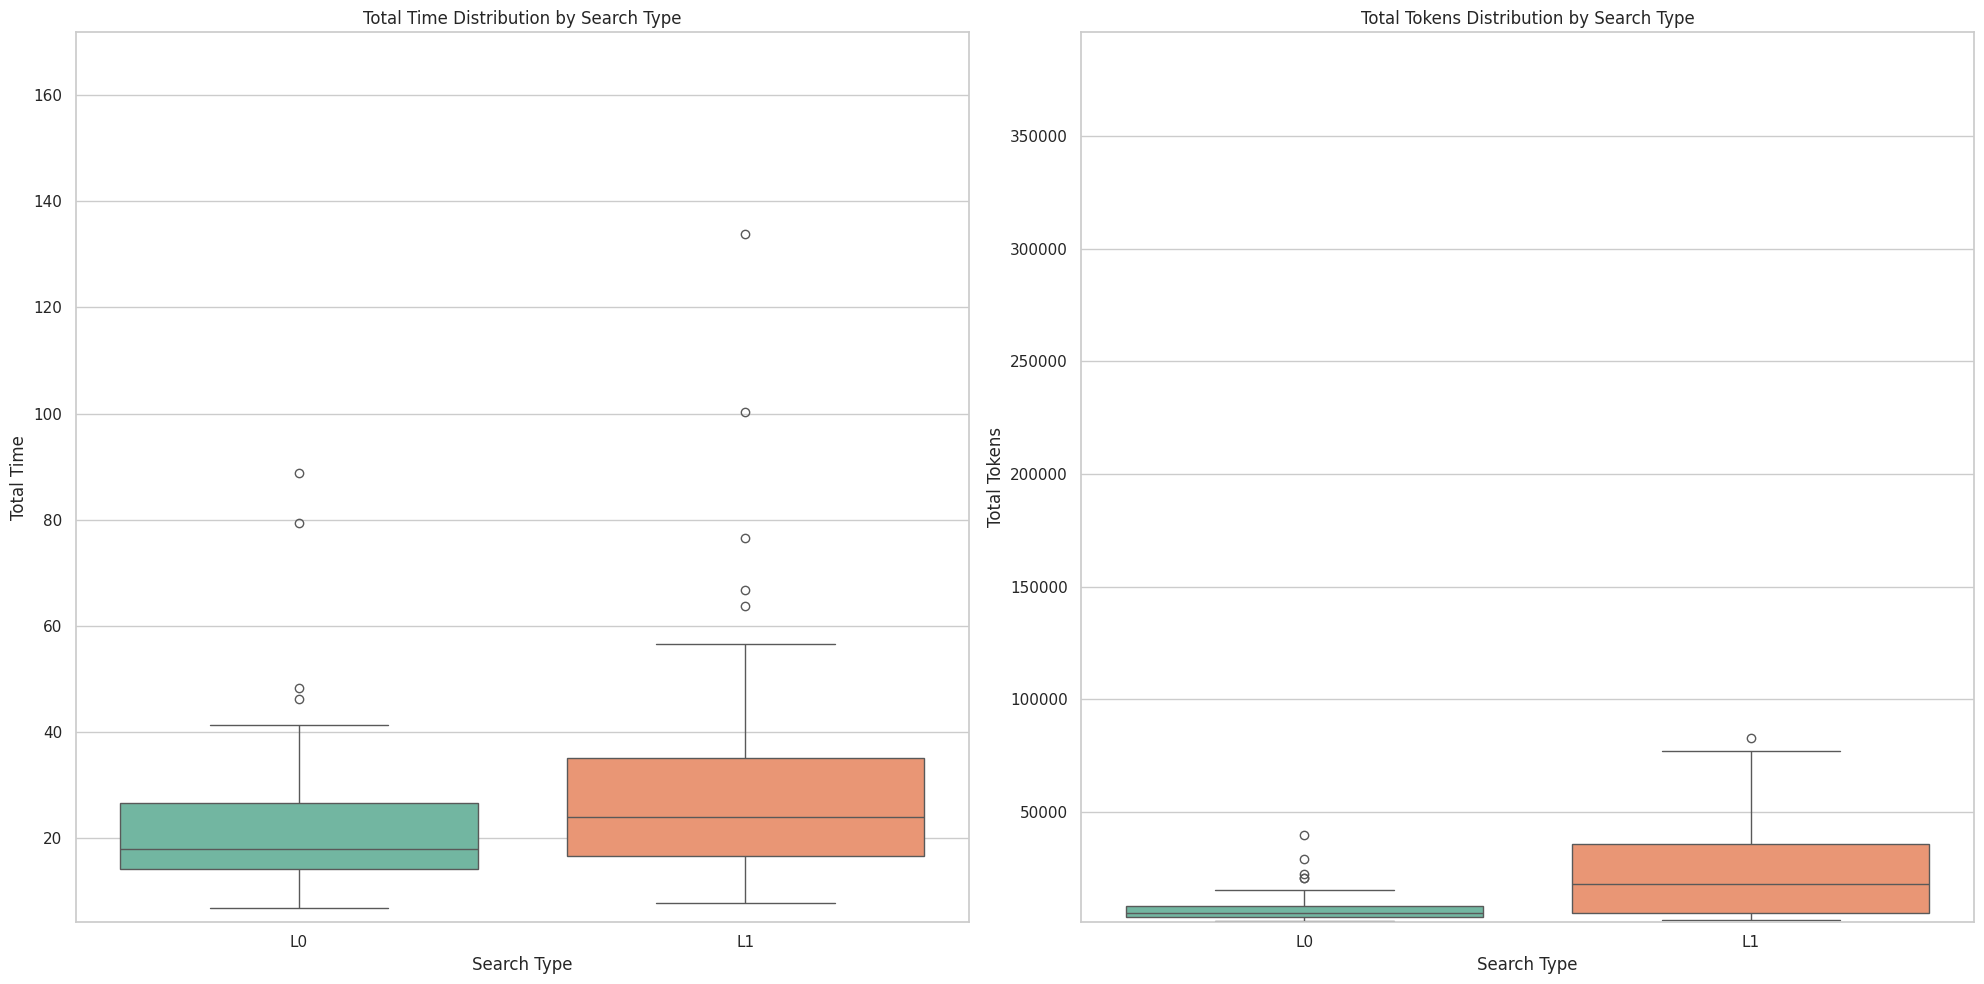

Boxplots for question:  Edythe31_Morar593_9c3df38a


/tmp/ipykernel_26812/2556792544.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_26812/2556792544.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


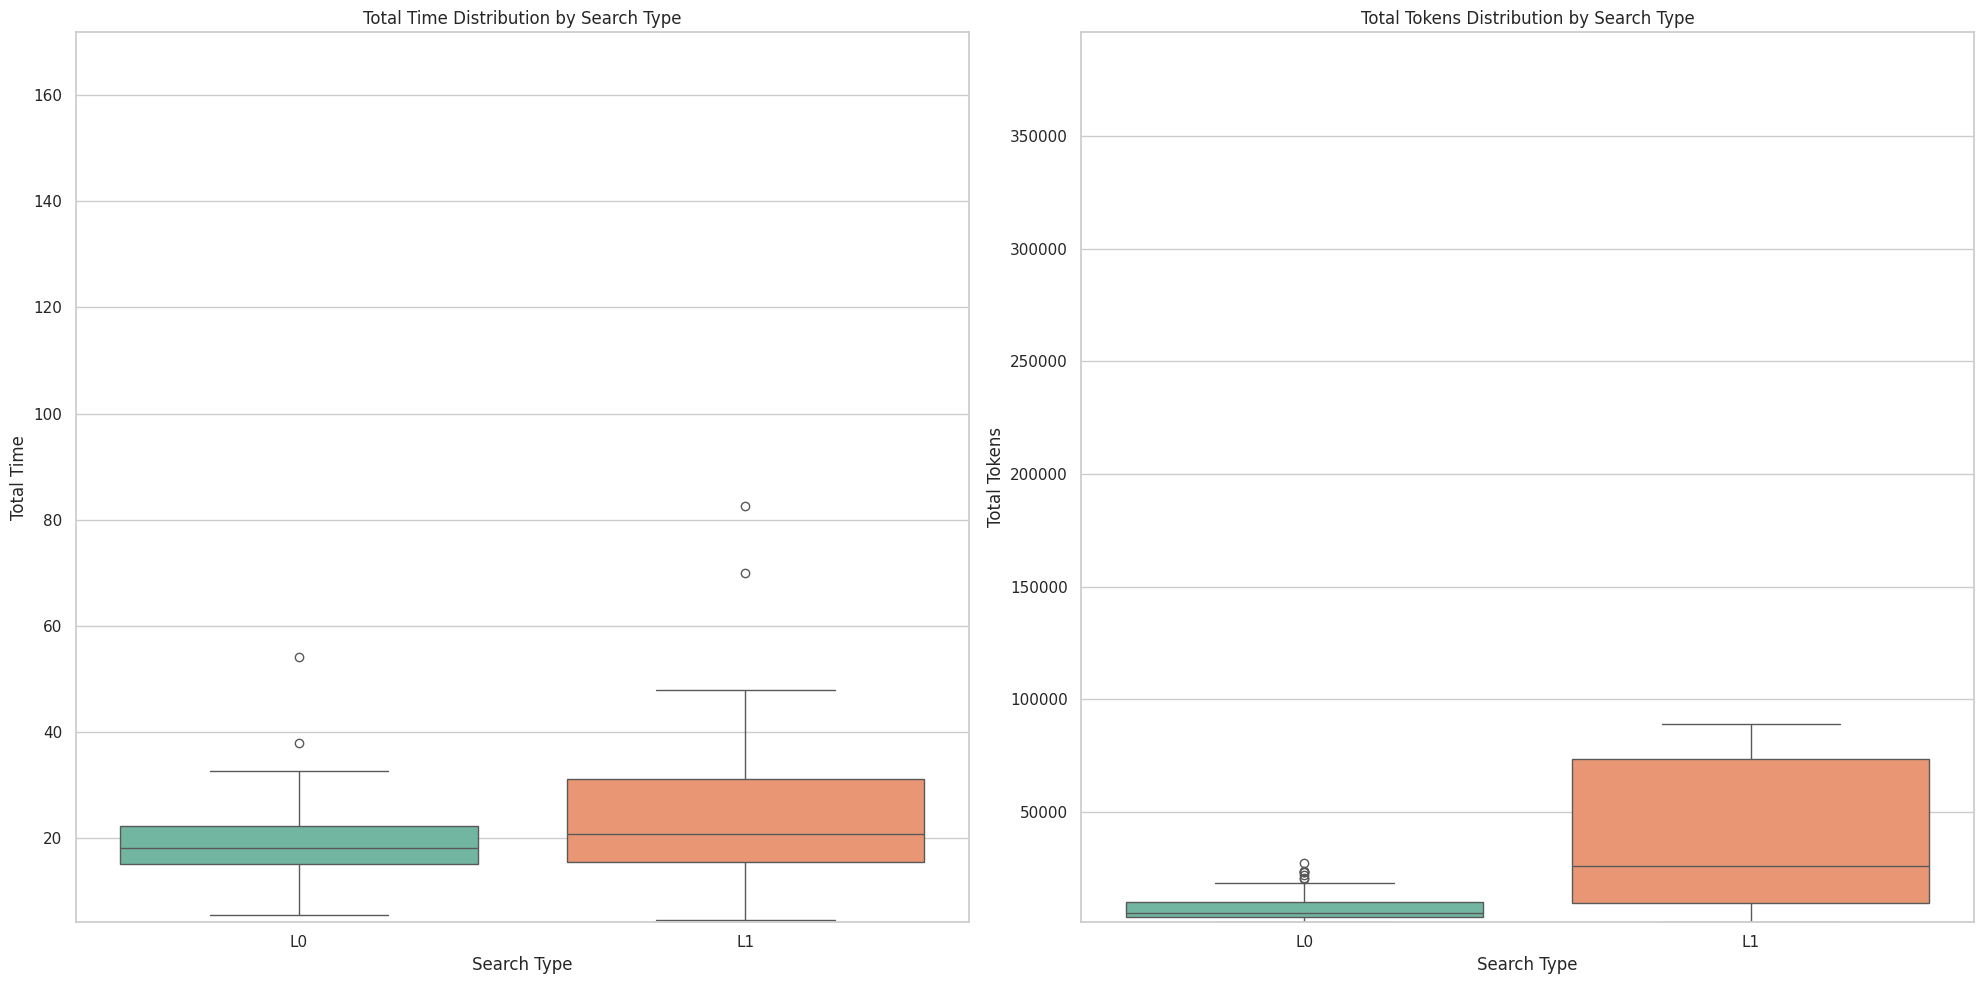

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and it has columns: 'model', 'search_type', 'total_time', 'total_tokens'

# Determine the global y-axis limits for both 'total_time' and 'total_tokens'
global_total_time_min = df['total_time'].min()
global_total_time_max = df['total_time'].max()

global_total_tokens_min = df['total_tokens'].min()
global_total_tokens_max = df['total_tokens'].max()

for consumer_id in set(df["true_consumer_id"].unique()):
    print("Boxplots for question: ", consumer_id)
    df_model = df[df["true_consumer_id"] == consumer_id]
    plt.figure(figsize=(20, 10))
    
    # Box plot for total_time
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    plt.title("Total Time Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Time")
    plt.ylim(global_total_time_min, global_total_time_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    # Box plot for total_tokens
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    plt.title("Total Tokens Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Tokens")
    plt.ylim(global_total_tokens_min, global_total_tokens_max)  # Set the same y-axis scale
    plt.tight_layout()
    
    plt.show()